In [20]:
import ferrmion
import pickle
import openfermionpyscf
import openfermion
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
from copy import deepcopy

In [21]:
from ferrmion import core
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.core import anneal_enumerations, encode, topphatt
from ferrmion.optimize import topphatt
from ferrmion.encode import TernaryTree
from ferrmion.hamiltonians import fill_template, molecular_hamiltonian_template

from openfermion.chem.pubchem import geometry_from_pubchem
from openfermion.chem.molecular_data import MolecularData
from openfermion.chem.molecular_data import spinorb_from_spatial
import openfermionpyscf
import openfermion

In [22]:
geometry=geometry_from_pubchem("H2O")
mol = MolecularData(geometry=geometry, basis="sto-3g", multiplicity=1)
mol = openfermionpyscf.run_pyscf(molecule=mol, run_scf=True)
ones, twos = spinorb_from_spatial(mol.one_body_integrals, mol.two_body_integrals)
twos = 0.5*twos

In [23]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (np.mean(unscaled_terms), np.mean(scaled_terms), len(pauli_hamiltonian))

def fill_template_find_norms(template, ones, twos, permutation):
    permutation = np.array(permutation, dtype=np.uint)
    ham = fill_template(template, 0, ones, twos, permutation)
    
    return pauli_weights(ham)

In [24]:
from ferrmion.utils import symplectic_to_pauli

ipow, sym = TernaryTree(14).JW()._build_symplectic_matrix()
before = deepcopy(twos)
naive_ham = encode(ipow, sym, ["+-","++--"], [ones, twos])
print(pauli_weights(encode(ipow, sym, ["+-","++--"], [ones, twos])))
assert np.all(before == twos)
print(ipow)
print(sym)
for line in sym:
    print(symplectic_to_pauli(line))

(np.float64(7.258239055582883), np.float64(0.0941181224451932), 2033)
[0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
[[ True False False False False False False False False False False False
  False False False False False False False False False False False False
  False False False False]
 [ True False False False False False False False False False False False
  False False  True False False False False False False False False False
  False False False False]
 [False  True False False False False False False False False False False
  False False  True False False False False False False False False False
  False False False False]
 [False  True False False False False False False False False False False
  False False  True  True False False False False False False False False
  False False False False]
 [False False  True False False False False False False False False False
  False False  True  True False False False False False False False False
  False False False Fals

In [25]:
ipow,sym = core.topphatt_standard("JW", 14, 14, ["+-","++--"], [ones, twos])
print(pauli_weights(encode(ipow, sym, ["+-","++--"], [ones, twos])))
# print(sym)
for line in sym:
    print(symplectic_to_pauli(line))

(np.float64(5.96458435809149), np.float64(0.07601741783009561), 2033)
('ZZZZZZZZZZXIII', 0)
('ZZZZZZZZZZYIII', 3)
('ZZZZZZZZZZZXII', 0)
('ZZZZZZZZZZZYII', 3)
('XIIIIIIIIIIIII', 0)
('YIIIIIIIIIIIII', 3)
('ZZZZZZZZZXIIII', 0)
('ZZZZZZZZZYIIII', 3)
('ZZZZXIIIIIIIII', 0)
('ZZZZYIIIIIIIII', 3)
('ZZZZZZZXIIIIII', 0)
('ZZZZZZZYIIIIII', 3)
('ZZZXIIIIIIIIII', 0)
('ZZZYIIIIIIIIII', 3)
('ZZZZZZZZXIIIII', 0)
('ZZZZZZZZYIIIII', 3)
('ZZZZZZZZZZZZXI', 0)
('ZZZZZZZZZZZZYI', 3)
('ZZZZZZZZZZZZZX', 0)
('ZZZZZZZZZZZZZY', 3)
('ZXIIIIIIIIIIII', 0)
('ZYIIIIIIIIIIII', 3)
('ZZZZZXIIIIIIII', 0)
('ZZZZZYIIIIIIII', 3)
('ZZXIIIIIIIIIII', 0)
('ZZYIIIIIIIIIII', 3)
('ZZZZZZXIIIIIII', 0)
('ZZZZZZYIIIIIII', 3)


In [26]:
from ferrmion.optimize import topphatt as pytopphatt
sparse_ham = fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--")))
pytree = pytopphatt(sparse_ham, TernaryTree(14).JW())
ipow, sym = pytree._build_symplectic_matrix()
print(pauli_weights(encode(ipow, sym, ["+-","++--"], [ones, twos])))
for line in sym:
    print(symplectic_to_pauli(line))

(np.float64(5.972454500737826), np.float64(0.07487430282535212), 2033)
('ZZZZZZZZZZXIII', 0)
('ZZZZZZZZZZYIII', 3)
('ZZZZZZZZZZZXII', 0)
('ZZZZZZZZZZZYII', 3)
('XIIIIIIIIIIIII', 0)
('YIIIIIIIIIIIII', 3)
('ZZZZZZZZZXIIII', 0)
('ZZZZZZZZZYIIII', 3)
('ZZXIIIIIIIIIII', 0)
('ZZYIIIIIIIIIII', 3)
('ZZZZZZXIIIIIII', 0)
('ZZZZZZYIIIIIII', 3)
('ZZZXIIIIIIIIII', 0)
('ZZZYIIIIIIIIII', 3)
('ZZZZZXIIIIIIII', 0)
('ZZZZZYIIIIIIII', 3)
('ZZZZZZZZZZZZXI', 0)
('ZZZZZZZZZZZZYI', 3)
('ZZZZZZZZZZZZZX', 0)
('ZZZZZZZZZZZZZY', 3)
('ZZZZXIIIIIIIII', 0)
('ZZZZYIIIIIIIII', 3)
('ZZZZZZZZXIIIII', 0)
('ZZZZZZZZYIIIII', 3)
('ZXIIIIIIIIIIII', 0)
('ZYIIIIIIIIIIII', 3)
('ZZZZZZZXIIIIII', 0)
('ZZZZZZZYIIIIII', 3)


In [27]:
from typing import Iterable

def _reduce_hamiltonian(
    majorana_ham: dict[Iterable[int], float],
    parent_index: int,
    selection: list[int, int, int],
) -> dict[tuple[int, ...], float]:
    """Simplify the Hamiltonian.

    As we increase the qubit number, we iteratively remove majoranas
    which act trivially on the remaining qubits.
    We replace them with the index of their parent string
    as going forward they are identical to the parent string.

    Args:
        majorana_ham (dict[tuple[int,...],float]): Current Hamiltonian.
        parent_index (int): Qubit index of the parent node.
        selection (tuple[int, int, int]): Indices of the majoranas to be replaced.

    Returns:
        dict[tuple[int,...],float]: Reduced Hamiltonian.
    """
    new_ham = {}
    for term, coeff in majorana_ham.items():
        # new_term = tuple(i if i not in selection else parent_index for i in term)
        new_term = tuple(i for i in term if i not in selection) + tuple(
            parent_index for i in term if i in selection
        )
        if len(set(new_term)) >= 1:
            new_ham[new_term] = new_ham.get(new_term, 0) + coeff
    return new_ham


In [28]:
# 2025-12-12 14:58:48,255: ferrmion.optimize.topphatt: 471: DEBUG: reduction before [2,3,41]
py_reduced_majorana_ham={(0, 1): np.complex128(-12.412562749241054j), (0, 5): np.complex128(0.12510154235632387j), (1, 4): np.complex128(-0.12510154235632387j), (0, 9): np.complex128(7.24345240286813e-08j), (1, 8): np.complex128(-7.24345240286813e-08j), (0, 13): np.complex128(-0.042604741935549695j), (1, 12): np.complex128(0.042604741935549695j), (0, 20): np.complex128(1.586187778346293e-16+0j), (0, 21): np.complex128(0.07170028934810807j), (1, 20): np.complex128(-0.07170028934810807j), (1, 21): np.complex128(1.586187778346293e-16+0j), (0, 25): np.complex128(-3.072188755953087e-07j), (1, 24): np.complex128(3.072188755953087e-07j), (2, 3): np.complex128(-12.412562749241054j), (2, 7): np.complex128(0.12510154235632387j), (3, 6): np.complex128(-0.12510154235632387j), (2, 11): np.complex128(7.243452402868132e-08j), (3, 10): np.complex128(-7.243452402868132e-08j), (2, 15): np.complex128(-0.042604741935549674j), (3, 14): np.complex128(0.042604741935549674j), (2, 22): np.complex128(1.603535013106061e-16+0j), (2, 23): np.complex128(0.07170028934810813j), (3, 22): np.complex128(-0.07170028934810813j), (3, 23): np.complex128(1.5384828827569308e-16+0j), (2, 27): np.complex128(-3.072188755953091e-07j), (3, 26): np.complex128(3.072188755953091e-07j), (4, 5): np.complex128(-1.653724328846056j), (4, 9): np.complex128(-8.53305196736954e-08j), (5, 8): np.complex128(8.53305196736954e-08j), (4, 12): np.complex128(-2.706168622523819e-16+0j), (4, 13): np.complex128(0.1212108061504782j), (5, 12): np.complex128(-0.1212108061504782j), (5, 13): np.complex128(-2.671474153004283e-16+0j), (4, 20): np.complex128(2.5066754227864863e-16+0j), (4, 21): np.complex128(-0.2815807711550525j), (5, 20): np.complex128(0.2815807711550525j), (5, 21): np.complex128(2.680147770384167e-16+0j), (4, 24): np.complex128(-1.7928839345088396e-16+0j), (4, 25): np.complex128(1.258512105453424e-06j), (5, 24): np.complex128(-1.258512105453424e-06j), (5, 25): np.complex128(-1.7928839345088396e-16+0j), (6, 7): np.complex128(-1.6537243288460561j), (6, 11): np.complex128(-8.533051967369542e-08j), (7, 10): np.complex128(8.53305196736954e-08j), (6, 14): np.complex128(-2.701831813833877e-16+0j), (6, 15): np.complex128(0.12121080615047825j), (7, 14): np.complex128(-0.12121080615047825j), (7, 15): np.complex128(-2.701831813833877e-16+0j), (6, 22): np.complex128(2.6812319725566525e-16+0j), (6, 23): np.complex128(-0.2815807711550526j), (7, 22): np.complex128(0.2815807711550526j), (7, 23): np.complex128(2.6985792073164205e-16+0j), (6, 26): np.complex128(-1.7928836698110435e-16+0j), (6, 27): np.complex128(1.2585121054534244e-06j), (7, 26): np.complex128(-1.2585121054534244e-06j), (7, 27): np.complex128(-1.7928841992066356e-16+0j), (8, 9): np.complex128(-1.2032770698223598j), (8, 13): np.complex128(2.69399364780321e-07j), (9, 12): np.complex128(-2.69399364780321e-07j), (8, 21): np.complex128(-1.4448745105107907e-06j), (9, 20): np.complex128(1.4448745105107907e-06j), (8, 24): np.complex128(-1.249000902703301e-16+0j), (8, 25): np.complex128(-0.36959219645334934j), (9, 24): np.complex128(0.36959219645334934j), (9, 25): np.complex128(-1.1015494072452725e-16+0j), (10, 11): np.complex128(-1.2032770698223618j), (10, 15): np.complex128(2.693993647803212e-07j), (11, 14): np.complex128(-2.693993647803212e-07j), (10, 23): np.complex128(-1.4448745105107899e-06j), (11, 22): np.complex128(1.4448745105107899e-06j), (10, 26): np.complex128(-1.249000902703301e-16+0j), (10, 27): np.complex128(-0.36959219645334934j), (11, 26): np.complex128(0.36959219645334934j), (11, 27): np.complex128(-1.1102230246251565e-16+0j), (12, 13): np.complex128(-1.3095987815670695j), (12, 21): np.complex128(-0.22821960331691205j), (13, 20): np.complex128(0.22821960331691205j), (12, 25): np.complex128(5.634143389826723e-07j), (13, 24): np.complex128(-5.634143389826723e-07j), (14, 15): np.complex128(-1.3095987815670684j), (14, 23): np.complex128(-0.22821960331691202j), (15, 22): np.complex128(0.22821960331691202j), (14, 27): np.complex128(5.634143389826723e-07j), (15, 26): np.complex128(-5.634143389826723e-07j), (41, 41): np.complex128(-2.7385705587474j), (20, 21): np.complex128(-0.7826196716002184j), (20, 25): np.complex128(-2.3702939313375603e-07j), (21, 24): np.complex128(2.3702939313375603e-07j), (22, 23): np.complex128(-0.7826196716002174j), (22, 27): np.complex128(-2.370293931337561e-07j), (23, 26): np.complex128(2.370293931337561e-07j), (24, 25): np.complex128(-0.8087614661390324j), (26, 27): np.complex128(-0.8087614661390323j), (0, 1, 4, 5): np.complex128(-0.23672126719374745+0j), (0, 1, 4, 9): np.complex128(-1.8312215462359242e-08+0j), (0, 1, 5, 8): np.complex128(1.8312215462359242e-08+0j), (0, 1, 4, 13): np.complex128(0.02707115378387988+0j), (0, 1, 5, 12): np.complex128(-0.02707115378387988+0j), (0, 1, 4, 21): np.complex128(-0.06750035453726225+0j), (0, 1, 5, 20): np.complex128(0.06750035453726225+0j), (0, 1, 4, 25): np.complex128(3.054132199591643e-07+0j), (0, 1, 5, 24): np.complex128(-3.054132199591643e-07+0j), (0, 1, 8, 9): np.complex128(-0.19651043562860998+0j), (0, 1, 8, 13): np.complex128(6.810374460784758e-08+0j), (0, 1, 9, 12): np.complex128(-6.810374460784758e-08+0j), (0, 1, 8, 21): np.complex128(-3.336460876894293e-07+0j), (0, 1, 9, 20): np.complex128(3.336460876894293e-07+0j), (0, 1, 8, 25): np.complex128(-0.08689038253453374+0j), (0, 1, 9, 24): np.complex128(0.08689038253453374+0j), (0, 1, 12, 13): np.complex128(-0.24174347916141453+0j), (0, 1, 12, 21): np.complex128(-0.05602378747674352+0j), (0, 1, 13, 20): np.complex128(0.05602378747674352+0j), (0, 1, 12, 25): np.complex128(1.4398077355283082e-07+0j), (0, 1, 13, 24): np.complex128(-1.4398077355283082e-07+0j), (0, 1, 41, 41): np.complex128(-0.5511597201959755+0j), (0, 1, 20, 21): np.complex128(-0.1927862357089559+0j), (0, 1, 20, 25): np.complex128(-4.829499433754864e-08+0j), (0, 1, 21, 24): np.complex128(4.829499433754864e-08+0j), (0, 1, 24, 25): np.complex128(-0.211153111371365+0j), (0, 1, 2, 3): np.complex128(-1.1861764896511457+0j), (0, 2, 3, 5): np.complex128(0.10435224811558719+0j), (1, 2, 3, 4): np.complex128(-0.10435224811558719+0j), (0, 2, 3, 9): np.complex128(6.848440571650526e-08+0j), (1, 2, 3, 8): np.complex128(-6.848440571650526e-08+0j), (0, 2, 3, 13): np.complex128(-0.045761686312354014+0j), (1, 2, 3, 12): np.complex128(0.045761686312354014+0j), (0, 2, 3, 21): np.complex128(0.05863955340699901+0j), (1, 2, 3, 20): np.complex128(-0.05863955340699901+0j), (0, 2, 3, 25): np.complex128(-2.4974529554956165e-07+0j), (1, 2, 3, 24): np.complex128(2.4974529554956165e-07+0j), (0, 1, 2, 7): np.complex128(0.10435224811558719+0j), (0, 1, 3, 6): np.complex128(-0.10435224811558719+0j), (0, 2, 5, 7): np.complex128(0.014588413013127716+0j), (0, 3, 5, 6): np.complex128(-0.014588413013127716+0j), (1, 2, 4, 7): np.complex128(-0.014588413013127716+0j), (1, 3, 4, 6): np.complex128(0.014588413013127716+0j), (0, 2, 7, 9): np.complex128(-7.846248392991063e-09+0j), (0, 3, 6, 9): np.complex128(7.846248392991063e-09+0j), (1, 2, 7, 8): np.complex128(7.846248392991063e-09+0j), (1, 3, 6, 8): np.complex128(-7.846248392991063e-09+0j), (0, 2, 7, 13): np.complex128(0.0056398152645194535+0j), (0, 3, 6, 13): np.complex128(-0.0056398152645194535+0j), (1, 2, 7, 12): np.complex128(-0.0056398152645194535+0j), (1, 3, 6, 12): np.complex128(0.0056398152645194535+0j), (0, 2, 7, 21): np.complex128(-0.008830200378754833+0j), (0, 3, 6, 21): np.complex128(0.008830200378754833+0j), (1, 2, 7, 20): np.complex128(0.008830200378754833+0j), (1, 3, 6, 20): np.complex128(-0.008830200378754833+0j), (0, 2, 7, 25): np.complex128(3.9060932224181344e-08+0j), (0, 3, 6, 25): np.complex128(-3.9060932224181344e-08+0j), (1, 2, 7, 24): np.complex128(-3.9060932224181344e-08+0j), (1, 3, 6, 24): np.complex128(3.9060932224181344e-08+0j), (0, 1, 2, 11): np.complex128(6.848440571650526e-08+0j), (0, 1, 3, 10): np.complex128(-6.848440571650526e-08+0j), (0, 2, 5, 11): np.complex128(7.846248392991063e-09+0j), (0, 3, 5, 10): np.complex128(-7.846248392991063e-09+0j), (1, 2, 4, 11): np.complex128(-7.846248392991063e-09+0j), (1, 3, 4, 10): np.complex128(7.846248392991063e-09+0j), (0, 2, 9, 11): np.complex128(0.0027413536231855333+0j), (0, 3, 9, 10): np.complex128(-0.0027413536231855333+0j), (1, 2, 8, 11): np.complex128(-0.0027413536231855333+0j), (1, 3, 8, 10): np.complex128(0.0027413536231855333+0j), (0, 2, 11, 13): np.complex128(5.368271948496131e-09+0j), (0, 3, 10, 13): np.complex128(-5.368271948496131e-09+0j), (1, 2, 11, 12): np.complex128(-5.368271948496131e-09+0j), (1, 3, 10, 12): np.complex128(5.368271948496131e-09+0j), (0, 2, 11, 21): np.complex128(-1.7153035605304745e-08+0j), (0, 3, 10, 21): np.complex128(1.7153035605304745e-08+0j), (1, 2, 11, 20): np.complex128(1.7153035605304745e-08+0j), (1, 3, 10, 20): np.complex128(-1.7153035605304745e-08+0j), (0, 2, 11, 25): np.complex128(-0.003804304298248097+0j), (0, 3, 10, 25): np.complex128(0.003804304298248097+0j), (1, 2, 11, 24): np.complex128(0.003804304298248097+0j), (1, 3, 10, 24): np.complex128(-0.003804304298248097+0j), (0, 1, 2, 15): np.complex128(-0.045761686312354014+0j), (0, 1, 3, 14): np.complex128(0.045761686312354014+0j), (0, 2, 5, 15): np.complex128(-0.0056398152645194535+0j), (0, 3, 5, 14): np.complex128(0.0056398152645194535+0j), (1, 2, 4, 15): np.complex128(0.0056398152645194535+0j), (1, 3, 4, 14): np.complex128(-0.0056398152645194535+0j), (0, 2, 9, 15): np.complex128(-5.368271948496131e-09+0j), (0, 3, 9, 14): np.complex128(5.368271948496131e-09+0j), (1, 2, 8, 15): np.complex128(5.368271948496131e-09+0j), (1, 3, 8, 14): np.complex128(-5.368271948496131e-09+0j), (0, 2, 13, 15): np.complex128(0.006883909531020928+0j), (0, 3, 13, 14): np.complex128(-0.006883909531020928+0j), (1, 2, 12, 15): np.complex128(-0.006883909531020928+0j), (1, 3, 12, 14): np.complex128(0.006883909531020928+0j), (0, 2, 15, 21): np.complex128(7.567921249935078e-05+0j), (0, 3, 14, 21): np.complex128(-7.567921249935078e-05+0j), (1, 2, 15, 20): np.complex128(-7.567921249935078e-05+0j), (1, 3, 14, 20): np.complex128(7.567921249935078e-05+0j), (0, 2, 15, 25): np.complex128(-3.71881326193215e-09+0j), (0, 3, 14, 25): np.complex128(3.71881326193215e-09+0j), (1, 2, 15, 24): np.complex128(3.71881326193215e-09+0j), (1, 3, 14, 24): np.complex128(-3.71881326193215e-09+0j), (0, 2, 41, 41): np.complex128(0.006509359475489988+0j), (0, 3, 41, 41): np.complex128(-0.006509359475489988+0j), (1, 2, 41, 41): np.complex128(-0.006509359475489988+0j), (1, 3, 41, 41): np.complex128(0.006509359475489988+0j), (0, 1, 2, 23): np.complex128(0.05863955340699901+0j), (0, 1, 3, 22): np.complex128(-0.05863955340699901+0j), (0, 2, 5, 23): np.complex128(0.008830200378754833+0j), (0, 3, 5, 22): np.complex128(-0.008830200378754833+0j), (1, 2, 4, 23): np.complex128(-0.008830200378754833+0j), (1, 3, 4, 22): np.complex128(0.008830200378754833+0j), (0, 2, 9, 23): np.complex128(1.715303560530475e-08+0j), (0, 3, 9, 22): np.complex128(-1.715303560530475e-08+0j), (1, 2, 8, 23): np.complex128(-1.715303560530475e-08+0j), (1, 3, 8, 22): np.complex128(1.715303560530475e-08+0j), (0, 2, 13, 23): np.complex128(-7.567921249935078e-05+0j), (0, 3, 13, 22): np.complex128(7.567921249935078e-05+0j), (1, 2, 12, 23): np.complex128(7.567921249935078e-05+0j), (1, 3, 12, 22): np.complex128(-7.567921249935078e-05+0j), (0, 2, 21, 23): np.complex128(0.007722945973013233+0j), (0, 3, 21, 22): np.complex128(-0.007722945973013233+0j), (1, 2, 20, 23): np.complex128(-0.007722945973013233+0j), (1, 3, 20, 22): np.complex128(0.007722945973013233+0j), (0, 2, 23, 25): np.complex128(1.2209500057747357e-08+0j), (0, 3, 22, 25): np.complex128(-1.2209500057747357e-08+0j), (1, 2, 23, 24): np.complex128(-1.2209500057747357e-08+0j), (1, 3, 22, 24): np.complex128(1.2209500057747357e-08+0j), (0, 1, 2, 27): np.complex128(-2.4974529554956165e-07+0j), (0, 1, 3, 26): np.complex128(2.4974529554956165e-07+0j), (0, 2, 5, 27): np.complex128(-3.9060932224181344e-08+0j), (0, 3, 5, 26): np.complex128(3.9060932224181344e-08+0j), (1, 2, 4, 27): np.complex128(3.9060932224181344e-08+0j), (1, 3, 4, 26): np.complex128(-3.9060932224181344e-08+0j), (0, 2, 9, 27): np.complex128(0.003804304298248096+0j), (0, 3, 9, 26): np.complex128(-0.003804304298248096+0j), (1, 2, 8, 27): np.complex128(-0.003804304298248096+0j), (1, 3, 8, 26): np.complex128(0.003804304298248096+0j), (0, 2, 13, 27): np.complex128(3.71881326193215e-09+0j), (0, 3, 13, 26): np.complex128(-3.71881326193215e-09+0j), (1, 2, 12, 27): np.complex128(-3.71881326193215e-09+0j), (1, 3, 12, 26): np.complex128(3.71881326193215e-09+0j), (0, 2, 21, 27): np.complex128(-1.2209500057747357e-08+0j), (0, 3, 21, 26): np.complex128(1.2209500057747357e-08+0j), (1, 2, 20, 27): np.complex128(1.2209500057747357e-08+0j), (1, 3, 20, 26): np.complex128(-1.2209500057747357e-08+0j), (0, 2, 25, 27): np.complex128(0.005293067121032079+0j), (0, 3, 25, 26): np.complex128(-0.005293067121032079+0j), (1, 2, 24, 27): np.complex128(-0.005293067121032079+0j), (1, 3, 24, 26): np.complex128(0.005293067121032079+0j), (0, 4, 5, 9): np.complex128(3.674174311254638e-09+0j), (1, 4, 5, 8): np.complex128(-3.674174311254638e-09+0j), (0, 4, 5, 13): np.complex128(-0.0016619185006724764+0j), (1, 4, 5, 12): np.complex128(0.0016619185006724766+0j), (0, 4, 5, 21): np.complex128(-0.0014422703777326907+0j), (1, 4, 5, 20): np.complex128(0.0014422703777326907+0j), (0, 4, 5, 25): np.complex128(1.0185732916363537e-08+0j), (1, 4, 5, 24): np.complex128(-1.0185732916363537e-08+0j), (0, 5, 8, 9): np.complex128(0.0055264031895712745+0j), (1, 4, 8, 9): np.complex128(-0.0055264031895712745+0j), (0, 4, 9, 21): np.complex128(-7.759945292374962e-09+0j), (0, 5, 8, 21): np.complex128(2.493105283292244e-08+0j), (0, 5, 9, 20): np.complex128(-1.7171107540547482e-08+0j), (1, 4, 8, 21): np.complex128(-1.7171107540547482e-08+0j), (1, 4, 9, 20): np.complex128(2.493105283292244e-08+0j), (1, 5, 8, 20): np.complex128(-7.759945292374962e-09+0j), (0, 4, 9, 25): np.complex128(-0.0022519417697686554+0j), (0, 5, 8, 25): np.complex128(0.007600926421688087+0j), (0, 5, 9, 24): np.complex128(-0.005348984651919432+0j), (1, 4, 8, 25): np.complex128(-0.005348984651919432+0j), (1, 4, 9, 24): np.complex128(0.007600926421688087+0j), (1, 5, 8, 24): np.complex128(-0.0022519417697686554+0j), (0, 5, 12, 13): np.complex128(0.008045720348071467+0j), (1, 4, 12, 13): np.complex128(-0.008045720348071467+0j), (0, 4, 13, 21): np.complex128(-0.0004440400296842833+0j), (0, 5, 12, 21): np.complex128(0.005699114922710205+0j), (0, 5, 13, 20): np.complex128(-0.005255074893025922+0j), (1, 4, 12, 21): np.complex128(-0.005255074893025922+0j), (1, 4, 13, 20): np.complex128(0.005699114922710205+0j), (1, 5, 12, 20): np.complex128(-0.0004440400296842833+0j), (0, 4, 13, 25): np.complex128(7.970028045829575e-10+0j), (0, 5, 12, 25): np.complex128(-1.640297548266427e-08+0j), (0, 5, 13, 24): np.complex128(1.5605972678081312e-08+0j), (1, 4, 12, 25): np.complex128(1.5605972678081312e-08+0j), (1, 4, 13, 24): np.complex128(-1.640297548266427e-08+0j), (1, 5, 12, 24): np.complex128(7.970028045829575e-10+0j), (0, 5, 41, 41): np.complex128(0.013987986438159664+0j), (1, 4, 41, 41): np.complex128(-0.013987986438159664+0j), (0, 5, 20, 21): np.complex128(0.003540857988442716+0j), (1, 4, 20, 21): np.complex128(-0.003540857988442716+0j), (0, 4, 21, 25): np.complex128(4.009018053822631e-10+0j), (0, 5, 20, 25): np.complex128(1.159901719433355e-08+0j), (0, 5, 21, 24): np.complex128(-1.1999918999715813e-08+0j), (1, 4, 20, 25): np.complex128(-1.1999918999715813e-08+0j), (1, 4, 21, 24): np.complex128(1.159901719433355e-08+0j), (1, 5, 20, 24): np.complex128(4.009018053822631e-10+0j), (0, 5, 24, 25): np.complex128(0.006916381747073598+0j), (1, 4, 24, 25): np.complex128(-0.006916381747073598+0j), (0, 1, 6, 7): np.complex128(-0.25130968020687516+0j), (0, 5, 6, 7): np.complex128(0.0032825324569077186+0j), (1, 4, 6, 7): np.complex128(-0.0032825324569077186+0j), (0, 6, 7, 9): np.complex128(7.924300902775944e-09+0j), (1, 6, 7, 8): np.complex128(-7.924300902775944e-09+0j), (0, 6, 7, 13): np.complex128(-0.003950528800448665+0j), (1, 6, 7, 12): np.complex128(0.003950528800448665+0j), (0, 6, 7, 21): np.complex128(0.00020318282248258035+0j), (1, 6, 7, 20): np.complex128(-0.00020318282248258035+0j), (0, 6, 7, 25): np.complex128(3.6158860189078805e-09+0j), (1, 6, 7, 24): np.complex128(-3.6158860189078805e-09+0j), (0, 1, 6, 11): np.complex128(-2.6158463855350305e-08+0j), (0, 1, 7, 10): np.complex128(2.6158463855350305e-08+0j), (0, 5, 6, 11): np.complex128(4.250126591521307e-09+0j), (0, 5, 7, 10): np.complex128(-4.250126591521307e-09+0j), (1, 4, 6, 11): np.complex128(-4.250126591521307e-09+0j), (1, 4, 7, 10): np.complex128(4.250126591521307e-09+0j), (0, 6, 9, 11): np.complex128(0.004420592289100262+0j), (0, 7, 9, 10): np.complex128(-0.004420592289100262+0j), (1, 6, 8, 11): np.complex128(-0.004420592289100262+0j), (1, 7, 8, 10): np.complex128(0.004420592289100262+0j), (0, 6, 11, 21): np.complex128(-1.7581110633189572e-08+0j), (0, 7, 10, 21): np.complex128(1.7581110633189572e-08+0j), (1, 6, 11, 20): np.complex128(1.7581110633189572e-08+0j), (1, 7, 10, 20): np.complex128(-1.7581110633189572e-08+0j), (0, 6, 11, 25): np.complex128(-0.005738011371745221+0j), (0, 7, 10, 25): np.complex128(0.005738011371745221+0j), (1, 6, 11, 24): np.complex128(0.005738011371745221+0j), (1, 7, 10, 24): np.complex128(-0.005738011371745221+0j), (0, 1, 6, 15): np.complex128(0.03271096904839934+0j), (0, 1, 7, 14): np.complex128(-0.03271096904839934+0j), (0, 5, 6, 15): np.complex128(-0.0022886102997761895+0j), (0, 5, 7, 14): np.complex128(0.0022886102997761895+0j), (1, 4, 6, 15): np.complex128(0.0022886102997761895+0j), (1, 4, 7, 14): np.complex128(-0.0022886102997761895+0j), (0, 6, 13, 15): np.complex128(0.00470053558938752+0j), (0, 7, 13, 14): np.complex128(-0.00470053558938752+0j), (1, 6, 12, 15): np.complex128(-0.00470053558938752+0j), (1, 7, 12, 14): np.complex128(0.00470053558938752+0j), (0, 6, 15, 21): np.complex128(-0.005108425151220365+0j), (0, 7, 14, 21): np.complex128(0.005108425151220365+0j), (1, 6, 15, 20): np.complex128(0.005108425151220365+0j), (1, 7, 14, 20): np.complex128(-0.005108425151220365+0j), (0, 6, 15, 25): np.complex128(1.640297548266427e-08+0j), (0, 7, 14, 25): np.complex128(-1.640297548266427e-08+0j), (1, 6, 15, 24): np.complex128(-1.640297548266427e-08+0j), (1, 7, 14, 24): np.complex128(1.640297548266427e-08+0j), (0, 6, 41, 41): np.complex128(0.008126858431383244+0j), (0, 7, 41, 41): np.complex128(-0.008126858431383244+0j), (1, 6, 41, 41): np.complex128(-0.008126858431383244+0j), (1, 7, 41, 41): np.complex128(0.008126858431383244+0j), (0, 1, 6, 23): np.complex128(-0.07633055491601706+0j), (0, 1, 7, 22): np.complex128(0.07633055491601706+0j), (0, 5, 6, 23): np.complex128(0.001645453200215271+0j), (0, 5, 7, 22): np.complex128(-0.001645453200215271+0j), (1, 4, 6, 23): np.complex128(-0.001645453200215271+0j), (1, 4, 7, 22): np.complex128(0.001645453200215271+0j), (0, 6, 9, 23): np.complex128(9.821165340814609e-09+0j), (0, 7, 9, 22): np.complex128(-9.821165340814609e-09+0j), (1, 6, 8, 23): np.complex128(-9.821165340814609e-09+0j), (1, 7, 8, 22): np.complex128(9.821165340814609e-09+0j), (0, 6, 13, 23): np.complex128(0.004664385121536082+0j), (0, 7, 13, 22): np.complex128(-0.004664385121536082+0j), (1, 6, 12, 23): np.complex128(-0.004664385121536082+0j), (1, 7, 12, 22): np.complex128(0.004664385121536082+0j), (0, 6, 21, 23): np.complex128(0.0017851758312223574+0j), (0, 7, 21, 22): np.complex128(-0.0017851758312223574+0j), (1, 6, 20, 23): np.complex128(-0.0017851758312223574+0j), (1, 7, 20, 22): np.complex128(0.0017851758312223574+0j), (0, 6, 23, 25): np.complex128(-1.159901719433355e-08+0j), (0, 7, 22, 25): np.complex128(1.159901719433355e-08+0j), (1, 6, 23, 24): np.complex128(1.159901719433355e-08+0j), (1, 7, 22, 24): np.complex128(-1.159901719433355e-08+0j), (0, 1, 6, 27): np.complex128(3.4447415218334567e-07+0j), (0, 1, 7, 26): np.complex128(-3.4447415218334567e-07+0j), (0, 5, 6, 27): np.complex128(-6.569846897455656e-09+0j), (0, 5, 7, 26): np.complex128(6.569846897455656e-09+0j), (1, 4, 6, 27): np.complex128(6.569846897455656e-09+0j), (1, 4, 7, 26): np.complex128(-6.569846897455656e-09+0j), (0, 6, 9, 27): np.complex128(0.0034860696019765654+0j), (0, 7, 9, 26): np.complex128(-0.0034860696019765654+0j), (1, 6, 8, 27): np.complex128(-0.0034860696019765654+0j), (1, 7, 8, 26): np.complex128(0.0034860696019765654+0j), (0, 6, 13, 27): np.complex128(-1.5605972678081312e-08+0j), (0, 7, 13, 26): np.complex128(1.5605972678081312e-08+0j), (1, 6, 12, 27): np.complex128(1.5605972678081312e-08+0j), (1, 7, 12, 26): np.complex128(-1.5605972678081312e-08+0j), (0, 6, 21, 27): np.complex128(1.1999918999715813e-08+0j), (0, 7, 21, 26): np.complex128(-1.1999918999715813e-08+0j), (1, 6, 20, 27): np.complex128(-1.1999918999715813e-08+0j), (1, 7, 20, 26): np.complex128(1.1999918999715813e-08+0j), (0, 6, 25, 27): np.complex128(0.004584959583551752+0j), (0, 7, 25, 26): np.complex128(-0.004584959583551752+0j), (1, 6, 24, 27): np.complex128(-0.004584959583551752+0j), (1, 7, 24, 26): np.complex128(0.004584959583551752+0j), (0, 8, 9, 13): np.complex128(-0.0024520742319046086+0j), (1, 8, 9, 12): np.complex128(0.0024520742319046086+0j), (0, 8, 9, 21): np.complex128(0.0007153171629876367+0j), (1, 8, 9, 20): np.complex128(-0.0007153171629876367+0j), (0, 8, 9, 25): np.complex128(-5.88758398825461e-09+0j), (1, 8, 9, 24): np.complex128(5.88758398825461e-09+0j), (0, 5, 8, 13): np.complex128(-3.0252015407492863e-09+0j), (0, 5, 9, 12): np.complex128(3.0252015407492863e-09+0j), (1, 4, 8, 13): np.complex128(3.0252015407492863e-09+0j), (1, 4, 9, 12): np.complex128(-3.0252015407492863e-09+0j), (0, 9, 12, 13): np.complex128(4.045869417738506e-09+0j), (1, 8, 12, 13): np.complex128(-4.045869417738505e-09+0j), (0, 8, 13, 25): np.complex128(0.0010230001481488448+0j), (0, 9, 12, 25): np.complex128(0.0011728496324256814+0j), (0, 9, 13, 24): np.complex128(-0.0021958497805745257+0j), (1, 8, 12, 25): np.complex128(-0.0021958497805745257+0j), (1, 8, 13, 24): np.complex128(0.0011728496324256814+0j), (1, 9, 12, 24): np.complex128(0.0010230001481488448+0j), (0, 9, 41, 41): np.complex128(5.209640329771514e-09+0j), (1, 8, 41, 41): np.complex128(-5.209640329771514e-09+0j), (0, 8, 21, 25): np.complex128(-0.0026772333242283033+0j), (0, 9, 20, 25): np.complex128(-0.0013111264947250074+0j), (0, 9, 21, 24): np.complex128(0.003988359818953313+0j), (1, 8, 20, 25): np.complex128(0.003988359818953313+0j), (1, 8, 21, 24): np.complex128(-0.0013111264947250074+0j), (1, 9, 20, 24): np.complex128(-0.0026772333242283033+0j), (0, 9, 24, 25): np.complex128(2.7042797867344312e-08+0j), (1, 8, 24, 25): np.complex128(-2.7042797867344312e-08+0j), (0, 1, 10, 11): np.complex128(-0.19925178925179549+0j), (0, 5, 10, 11): np.complex128(0.0011058109004710127+0j), (1, 4, 10, 11): np.complex128(-0.0011058109004710127+0j), (0, 9, 10, 11): np.complex128(-2.844414880241026e-09+0j), (1, 8, 10, 11): np.complex128(2.844414880241026e-09+0j), (0, 10, 11, 13): np.complex128(-0.0016049614613082557+0j), (1, 10, 11, 12): np.complex128(0.0016049614613082557+0j), (0, 10, 11, 21): np.complex128(-6.671308503174797e-05+0j), (1, 10, 11, 20): np.complex128(6.671308503174797e-05+0j), (0, 10, 11, 25): np.complex128(-5.88758398825461e-09+0j), (1, 10, 11, 24): np.complex128(5.88758398825461e-09+0j), (0, 1, 10, 15): np.complex128(7.347201655634372e-08+0j), (0, 1, 11, 14): np.complex128(-7.347201655634372e-08+0j), (0, 5, 10, 15): np.complex128(-3.0252015407492863e-09+0j), (0, 5, 11, 14): np.complex128(3.0252015407492863e-09+0j), (1, 4, 10, 15): np.complex128(3.0252015407492863e-09+0j), (1, 4, 11, 14): np.complex128(-3.0252015407492863e-09+0j), (0, 9, 10, 15): np.complex128(0.0008471127705963529+0j), (0, 9, 11, 14): np.complex128(-0.0008471127705963529+0j), (1, 8, 10, 15): np.complex128(-0.0008471127705963529+0j), (1, 8, 11, 14): np.complex128(0.0008471127705963529+0j), (0, 10, 13, 15): np.complex128(4.045869417738505e-09+0j), (0, 11, 13, 14): np.complex128(-4.045869417738505e-09+0j), (1, 10, 12, 15): np.complex128(-4.045869417738505e-09+0j), (1, 11, 12, 14): np.complex128(4.045869417738505e-09+0j), (0, 10, 15, 25): np.complex128(0.0012155829277210994+0j), (0, 11, 14, 25): np.complex128(-0.0012155829277210994+0j), (1, 10, 15, 24): np.complex128(-0.0012155829277210994+0j), (1, 11, 14, 24): np.complex128(0.0012155829277210994+0j), (0, 10, 41, 41): np.complex128(5.2096403297715135e-09+0j), (0, 11, 41, 41): np.complex128(-5.2096403297715135e-09+0j), (1, 10, 41, 41): np.complex128(-5.2096403297715135e-09+0j), (1, 11, 41, 41): np.complex128(5.2096403297715135e-09+0j), (0, 1, 10, 23): np.complex128(-3.507991232947341e-07+0j), (0, 1, 11, 22): np.complex128(3.507991232947341e-07+0j), (0, 5, 10, 23): np.complex128(7.349942199732871e-09+0j), (0, 5, 11, 22): np.complex128(-7.349942199732871e-09+0j), (1, 4, 10, 23): np.complex128(-7.349942199732871e-09+0j), (1, 4, 11, 22): np.complex128(7.349942199732871e-09+0j), (0, 9, 10, 23): np.complex128(-0.0007820302480193845+0j), (0, 9, 11, 22): np.complex128(0.0007820302480193845+0j), (1, 8, 10, 23): np.complex128(0.0007820302480193845+0j), (1, 8, 11, 22): np.complex128(-0.0007820302480193845+0j), (0, 10, 23, 25): np.complex128(-0.0009533430025949679+0j), (0, 11, 22, 25): np.complex128(0.0009533430025949679+0j), (1, 10, 23, 24): np.complex128(0.0009533430025949679+0j), (1, 11, 22, 24): np.complex128(-0.0009533430025949679+0j), (0, 1, 10, 27): np.complex128(-0.09069468683278183+0j), (0, 1, 11, 26): np.complex128(0.09069468683278183+0j), (0, 5, 10, 27): np.complex128(0.0018629150499428657+0j), (0, 5, 11, 26): np.complex128(-0.0018629150499428657+0j), (1, 4, 10, 27): np.complex128(-0.0018629150499428657+0j), (1, 4, 11, 26): np.complex128(0.0018629150499428657+0j), (0, 10, 13, 27): np.complex128(-0.00019258277957225466+0j), (0, 11, 13, 26): np.complex128(0.00019258277957225466+0j), (1, 10, 12, 27): np.complex128(0.00019258277957225466+0j), (1, 11, 12, 26): np.complex128(-0.00019258277957225466+0j), (0, 10, 21, 27): np.complex128(-0.001723890321633336+0j), (0, 11, 21, 26): np.complex128(0.001723890321633336+0j), (1, 10, 20, 27): np.complex128(0.001723890321633336+0j), (1, 11, 20, 26): np.complex128(-0.001723890321633336+0j), (0, 10, 25, 27): np.complex128(6.758033844461568e-09+0j), (0, 11, 25, 26): np.complex128(-6.758033844461568e-09+0j), (1, 10, 24, 27): np.complex128(-6.758033844461568e-09+0j), (1, 11, 24, 26): np.complex128(6.758033844461568e-09+0j), (0, 12, 13, 21): np.complex128(0.005292538036894556+0j), (1, 12, 13, 20): np.complex128(-0.005292538036894556+0j), (0, 12, 13, 25): np.complex128(-2.169337505576471e-08+0j), (1, 12, 13, 24): np.complex128(2.169337505576471e-08+0j), (0, 13, 41, 41): np.complex128(-0.005901497786881468+0j), (1, 12, 41, 41): np.complex128(0.005901497786881468+0j), (0, 9, 12, 21): np.complex128(8.885015986546761e-09+0j), (0, 9, 13, 20): np.complex128(-8.885015986546761e-09+0j), (1, 8, 12, 21): np.complex128(-8.885015986546761e-09+0j), (1, 8, 13, 20): np.complex128(8.885015986546761e-09+0j), (0, 13, 20, 21): np.complex128(-0.005363081061715332+0j), (1, 12, 20, 21): np.complex128(0.005363081061715332+0j), (0, 12, 21, 25): np.complex128(-2.573843094109957e-09+0j), (0, 13, 20, 25): np.complex128(4.866371549477807e-09+0j), (0, 13, 21, 24): np.complex128(-2.292528455367849e-09+0j), (1, 12, 20, 25): np.complex128(-2.292528455367849e-09+0j), (1, 12, 21, 24): np.complex128(4.866371549477807e-09+0j), (1, 13, 20, 24): np.complex128(-2.573843094109957e-09+0j), (0, 13, 24, 25): np.complex128(-0.0043038047820521605+0j), (1, 12, 24, 25): np.complex128(0.0043038047820521605+0j), (0, 1, 14, 15): np.complex128(-0.24862738869243545+0j), (0, 5, 14, 15): np.complex128(0.0033451847586839474+0j), (1, 4, 14, 15): np.complex128(-0.0033451847586839474+0j), (0, 13, 14, 15): np.complex128(0.0027832027120741603+0j), (1, 12, 14, 15): np.complex128(-0.0027832027120741603+0j), (0, 14, 15, 21): np.complex128(0.0047572516192948+0j), (1, 14, 15, 20): np.complex128(-0.0047572516192948+0j), (0, 14, 15, 25): np.complex128(-1.7596323937886755e-08+0j), (1, 14, 15, 24): np.complex128(1.7596323937886755e-08+0j), (0, 14, 41, 41): np.complex128(-0.0033478980733706813+0j), (0, 15, 41, 41): np.complex128(0.0033478980733706813+0j), (1, 14, 41, 41): np.complex128(0.0033478980733706813+0j), (1, 15, 41, 41): np.complex128(-0.0033478980733706813+0j), (0, 1, 14, 23): np.complex128(-0.05594810826424417+0j), (0, 1, 15, 22): np.complex128(0.05594810826424417+0j), (0, 5, 14, 23): np.complex128(0.0005906897714898403+0j), (0, 5, 15, 22): np.complex128(-0.0005906897714898403+0j), (1, 4, 14, 23): np.complex128(-0.0005906897714898403+0j), (1, 4, 15, 22): np.complex128(0.0005906897714898403+0j), (0, 9, 14, 23): np.complex128(8.885015986546761e-09+0j), (0, 9, 15, 22): np.complex128(-8.885015986546761e-09+0j), (1, 8, 14, 23): np.complex128(-8.885015986546761e-09+0j), (1, 8, 15, 22): np.complex128(8.885015986546761e-09+0j), (0, 13, 14, 23): np.complex128(-0.0005352864175997575+0j), (0, 13, 15, 22): np.complex128(0.0005352864175997575+0j), (1, 12, 14, 23): np.complex128(0.0005352864175997575+0j), (1, 12, 15, 22): np.complex128(-0.0005352864175997575+0j), (0, 14, 21, 23): np.complex128(-0.0001247385335499872+0j), (0, 15, 21, 22): np.complex128(0.0001247385335499872+0j), (1, 14, 20, 23): np.complex128(0.0001247385335499872+0j), (1, 15, 20, 22): np.complex128(-0.0001247385335499872+0j), (0, 14, 23, 25): np.complex128(1.0898827842388664e-08+0j), (0, 15, 22, 25): np.complex128(-1.0898827842388664e-08+0j), (1, 14, 23, 24): np.complex128(-1.0898827842388664e-08+0j), (1, 15, 22, 24): np.complex128(1.0898827842388664e-08+0j), (0, 1, 14, 27): np.complex128(1.4026196029089865e-07+0j), (0, 1, 15, 26): np.complex128(-1.4026196029089865e-07+0j), (0, 9, 14, 27): np.complex128(0.0023884325601467803+0j), (0, 9, 15, 26): np.complex128(-0.0023884325601467803+0j), (1, 8, 14, 27): np.complex128(-0.0023884325601467803+0j), (1, 8, 15, 26): np.complex128(0.0023884325601467803+0j), (0, 13, 14, 27): np.complex128(4.097051117877952e-09+0j), (0, 13, 15, 26): np.complex128(-4.097051117877952e-09+0j), (1, 12, 14, 27): np.complex128(-4.097051117877952e-09+0j), (1, 12, 15, 26): np.complex128(4.097051117877952e-09+0j), (0, 14, 21, 27): np.complex128(-1.3472670936498622e-08+0j), (0, 15, 21, 26): np.complex128(1.3472670936498622e-08+0j), (1, 14, 20, 27): np.complex128(1.3472670936498622e-08+0j), (1, 15, 20, 26): np.complex128(-1.3472670936498622e-08+0j), (0, 14, 25, 27): np.complex128(-0.0032643069539711215+0j), (0, 15, 25, 26): np.complex128(0.0032643069539711215+0j), (1, 14, 24, 27): np.complex128(0.0032643069539711215+0j), (1, 15, 24, 26): np.complex128(-0.0032643069539711215+0j), (0, 21, 41, 41): np.complex128(0.006948581131405501+0j), (1, 20, 41, 41): np.complex128(-0.006948581131405501+0j), (0, 25, 41, 41): np.complex128(-2.908391601727963e-08+0j), (1, 24, 41, 41): np.complex128(2.908391601727963e-08+0j), (0, 23, 41, 41): np.complex128(-0.0038801526666063187+0j), (0, 22, 41, 41): np.complex128(0.0038801526666063187+0j), (1, 23, 41, 41): np.complex128(0.0038801526666063187+0j), (1, 22, 41, 41): np.complex128(-0.0038801526666063187+0j), (0, 27, 41, 41): np.complex128(1.6428420971060635e-08+0j), (0, 26, 41, 41): np.complex128(-1.6428420971060635e-08+0j), (1, 27, 41, 41): np.complex128(-1.6428420971060635e-08+0j), (1, 26, 41, 41): np.complex128(1.6428420971060635e-08+0j), (0, 9, 20, 21): np.complex128(-1.2875068127912046e-08+0j), (1, 8, 20, 21): np.complex128(1.2875068127912046e-08+0j), (0, 20, 21, 25): np.complex128(-1.505432923495098e-08+0j), (1, 20, 21, 24): np.complex128(1.505432923495098e-08+0j), (0, 21, 24, 25): np.complex128(0.004235961114459336+0j), (1, 20, 24, 25): np.complex128(-0.004235961114459336+0j), (0, 1, 22, 23): np.complex128(-0.20050918168196913+0j), (0, 5, 22, 23): np.complex128(0.0017556821572203576+0j), (1, 4, 22, 23): np.complex128(-0.0017556821572203576+0j), (0, 9, 22, 23): np.complex128(-1.2875068127912046e-08+0j), (1, 8, 22, 23): np.complex128(1.2875068127912046e-08+0j), (0, 13, 22, 23): np.complex128(-0.005238342528165344+0j), (1, 12, 22, 23): np.complex128(0.005238342528165344+0j), (0, 21, 22, 23): np.complex128(-0.0021316548314588226+0j), (1, 20, 22, 23): np.complex128(0.0021316548314588226+0j), (0, 22, 23, 25): np.complex128(-1.505432923495098e-08+0j), (1, 22, 23, 24): np.complex128(1.505432923495098e-08+0j), (0, 1, 22, 27): np.complex128(-3.608549427980128e-08+0j), (0, 1, 23, 26): np.complex128(3.608549427980128e-08+0j), (0, 9, 22, 27): np.complex128(-0.0022644694973199754+0j), (0, 9, 23, 26): np.complex128(0.0022644694973199754+0j), (1, 8, 22, 27): np.complex128(0.0022644694973199754+0j), (1, 8, 23, 26): np.complex128(-0.0022644694973199754+0j), (0, 13, 22, 27): np.complex128(1.576519939186647e-08+0j), (0, 13, 23, 26): np.complex128(-1.576519939186647e-08+0j), (1, 12, 22, 27): np.complex128(-1.576519939186647e-08+0j), (1, 12, 23, 26): np.complex128(1.576519939186647e-08+0j), (0, 22, 25, 27): np.complex128(0.002993118809594667+0j), (0, 23, 25, 26): np.complex128(-0.002993118809594667+0j), (1, 22, 24, 27): np.complex128(-0.002993118809594667+0j), (1, 23, 24, 26): np.complex128(0.002993118809594667+0j), (0, 1, 26, 27): np.complex128(-0.21644617849239706+0j), (0, 5, 26, 27): np.complex128(0.002331422163521847+0j), (1, 4, 26, 27): np.complex128(-0.002331422163521847+0j), (0, 9, 26, 27): np.complex128(2.028476402288274e-08+0j), (1, 8, 26, 27): np.complex128(-2.028476402288274e-08+0j), (0, 13, 26, 27): np.complex128(-0.0010394978280810383+0j), (1, 12, 26, 27): np.complex128(0.0010394978280810383+0j), (0, 21, 26, 27): np.complex128(0.0012428423048646698+0j), (1, 20, 26, 27): np.complex128(-0.0012428423048646698+0j), (0, 25, 26, 27): np.complex128(1.9517876574944395e-08+0j), (1, 24, 26, 27): np.complex128(-1.9517876574944395e-08+0j), (2, 3, 6, 7): np.complex128(-0.23672126719374745+0j), (2, 3, 6, 11): np.complex128(-1.8312215462359242e-08+0j), (2, 3, 7, 10): np.complex128(1.8312215462359242e-08+0j), (2, 3, 6, 15): np.complex128(0.02707115378387988+0j), (2, 3, 7, 14): np.complex128(-0.02707115378387988+0j), (2, 3, 6, 23): np.complex128(-0.06750035453726225+0j), (2, 3, 7, 22): np.complex128(0.06750035453726225+0j), (2, 3, 6, 27): np.complex128(3.054132199591643e-07+0j), (2, 3, 7, 26): np.complex128(-3.054132199591643e-07+0j), (2, 3, 10, 11): np.complex128(-0.19651043562860998+0j), (2, 3, 10, 15): np.complex128(6.810374460784758e-08+0j), (2, 3, 11, 14): np.complex128(-6.810374460784758e-08+0j), (2, 3, 10, 23): np.complex128(-3.336460876894293e-07+0j), (2, 3, 11, 22): np.complex128(3.336460876894293e-07+0j), (2, 3, 10, 27): np.complex128(-0.08689038253453374+0j), (2, 3, 11, 26): np.complex128(0.08689038253453374+0j), (2, 3, 14, 15): np.complex128(-0.24174347916141453+0j), (2, 3, 14, 23): np.complex128(-0.05602378747674352+0j), (2, 3, 15, 22): np.complex128(0.05602378747674352+0j), (2, 3, 14, 27): np.complex128(1.4398077355283082e-07+0j), (2, 3, 15, 26): np.complex128(-1.4398077355283082e-07+0j), (2, 3, 41, 41): np.complex128(-0.5511597201959755+0j), (2, 3, 22, 23): np.complex128(-0.1927862357089559+0j), (2, 3, 22, 27): np.complex128(-4.829499433754864e-08+0j), (2, 3, 23, 26): np.complex128(4.829499433754864e-08+0j), (2, 3, 26, 27): np.complex128(-0.211153111371365+0j), (2, 3, 4, 5): np.complex128(-0.25130968020687516+0j), (2, 4, 5, 7): np.complex128(0.003282532456907718+0j), (3, 4, 5, 6): np.complex128(-0.003282532456907718+0j), (2, 4, 5, 11): np.complex128(7.924300902775944e-09+0j), (3, 4, 5, 10): np.complex128(-7.924300902775944e-09+0j), (2, 4, 5, 15): np.complex128(-0.003950528800448665+0j), (3, 4, 5, 14): np.complex128(0.003950528800448665+0j), (2, 4, 5, 23): np.complex128(0.00020318282248258035+0j), (3, 4, 5, 22): np.complex128(-0.00020318282248258035+0j), (2, 4, 5, 27): np.complex128(3.6158860189078805e-09+0j), (3, 4, 5, 26): np.complex128(-3.6158860189078805e-09+0j), (2, 3, 4, 9): np.complex128(-2.6158463855350305e-08+0j), (2, 3, 5, 8): np.complex128(2.6158463855350305e-08+0j), (2, 4, 7, 9): np.complex128(-4.250126591521307e-09+0j), (2, 5, 7, 8): np.complex128(4.250126591521307e-09+0j), (3, 4, 6, 9): np.complex128(4.250126591521307e-09+0j), (3, 5, 6, 8): np.complex128(-4.250126591521307e-09+0j), (2, 4, 9, 11): np.complex128(-0.004420592289100262+0j), (2, 5, 8, 11): np.complex128(0.004420592289100262+0j), (3, 4, 9, 10): np.complex128(0.004420592289100262+0j), (3, 5, 8, 10): np.complex128(-0.004420592289100262+0j), (2, 4, 9, 23): np.complex128(-1.7581110633189572e-08+0j), (2, 5, 8, 23): np.complex128(1.7581110633189572e-08+0j), (3, 4, 9, 22): np.complex128(1.7581110633189572e-08+0j), (3, 5, 8, 22): np.complex128(-1.7581110633189572e-08+0j), (2, 4, 9, 27): np.complex128(-0.005738011371745221+0j), (2, 5, 8, 27): np.complex128(0.005738011371745221+0j), (3, 4, 9, 26): np.complex128(0.005738011371745221+0j), (3, 5, 8, 26): np.complex128(-0.005738011371745221+0j), (2, 3, 4, 13): np.complex128(0.03271096904839934+0j), (2, 3, 5, 12): np.complex128(-0.03271096904839934+0j), (2, 4, 7, 13): np.complex128(0.0022886102997761895+0j), (2, 5, 7, 12): np.complex128(-0.0022886102997761895+0j), (3, 4, 6, 13): np.complex128(-0.0022886102997761895+0j), (3, 5, 6, 12): np.complex128(0.0022886102997761895+0j), (2, 4, 13, 15): np.complex128(-0.004700535589387521+0j), (2, 5, 12, 15): np.complex128(0.004700535589387521+0j), (3, 4, 13, 14): np.complex128(0.004700535589387521+0j), (3, 5, 12, 14): np.complex128(-0.004700535589387521+0j), (2, 4, 13, 23): np.complex128(-0.005108425151220365+0j), (2, 5, 12, 23): np.complex128(0.005108425151220365+0j), (3, 4, 13, 22): np.complex128(0.005108425151220365+0j), (3, 5, 12, 22): np.complex128(-0.005108425151220365+0j), (2, 4, 13, 27): np.complex128(1.640297548266427e-08+0j), (2, 5, 12, 27): np.complex128(-1.640297548266427e-08+0j), (3, 4, 13, 26): np.complex128(-1.640297548266427e-08+0j), (3, 5, 12, 26): np.complex128(1.640297548266427e-08+0j), (2, 4, 41, 41): np.complex128(-0.008126858431383244+0j), (2, 5, 41, 41): np.complex128(0.008126858431383244+0j), (3, 4, 41, 41): np.complex128(0.008126858431383244+0j), (3, 5, 41, 41): np.complex128(-0.008126858431383244+0j), (2, 3, 4, 21): np.complex128(-0.07633055491601706+0j), (2, 3, 5, 20): np.complex128(0.07633055491601706+0j), (2, 4, 7, 21): np.complex128(-0.001645453200215271+0j), (2, 5, 7, 20): np.complex128(0.001645453200215271+0j), (3, 4, 6, 21): np.complex128(0.001645453200215271+0j), (3, 5, 6, 20): np.complex128(-0.001645453200215271+0j), (2, 4, 11, 21): np.complex128(9.821165340814609e-09+0j), (2, 5, 11, 20): np.complex128(-9.821165340814609e-09+0j), (3, 4, 10, 21): np.complex128(-9.821165340814609e-09+0j), (3, 5, 10, 20): np.complex128(9.821165340814609e-09+0j), (2, 4, 15, 21): np.complex128(0.004664385121536082+0j), (2, 5, 15, 20): np.complex128(-0.004664385121536082+0j), (3, 4, 14, 21): np.complex128(-0.004664385121536082+0j), (3, 5, 14, 20): np.complex128(0.004664385121536082+0j), (2, 4, 21, 23): np.complex128(-0.0017851758312223574+0j), (2, 5, 20, 23): np.complex128(0.0017851758312223574+0j), (3, 4, 21, 22): np.complex128(0.0017851758312223574+0j), (3, 5, 20, 22): np.complex128(-0.0017851758312223574+0j), (2, 4, 21, 27): np.complex128(-1.159901719433355e-08+0j), (2, 5, 20, 27): np.complex128(1.159901719433355e-08+0j), (3, 4, 21, 26): np.complex128(1.159901719433355e-08+0j), (3, 5, 20, 26): np.complex128(-1.159901719433355e-08+0j), (2, 3, 4, 25): np.complex128(3.4447415218334567e-07+0j), (2, 3, 5, 24): np.complex128(-3.4447415218334567e-07+0j), (2, 4, 7, 25): np.complex128(6.5698468974556556e-09+0j), (2, 5, 7, 24): np.complex128(-6.5698468974556556e-09+0j), (3, 4, 6, 25): np.complex128(-6.5698468974556556e-09+0j), (3, 5, 6, 24): np.complex128(6.5698468974556556e-09+0j), (2, 4, 11, 25): np.complex128(0.0034860696019765654+0j), (2, 5, 11, 24): np.complex128(-0.0034860696019765654+0j), (3, 4, 10, 25): np.complex128(-0.0034860696019765654+0j), (3, 5, 10, 24): np.complex128(0.0034860696019765654+0j), (2, 4, 15, 25): np.complex128(-1.5605972678081312e-08+0j), (2, 5, 15, 24): np.complex128(1.5605972678081312e-08+0j), (3, 4, 14, 25): np.complex128(1.5605972678081312e-08+0j), (3, 5, 14, 24): np.complex128(-1.5605972678081312e-08+0j), (2, 4, 23, 25): np.complex128(1.1999918999715813e-08+0j), (2, 5, 23, 24): np.complex128(-1.1999918999715813e-08+0j), (3, 4, 22, 25): np.complex128(-1.1999918999715813e-08+0j), (3, 5, 22, 24): np.complex128(1.1999918999715813e-08+0j), (2, 4, 25, 27): np.complex128(-0.004584959583551751+0j), (2, 5, 24, 27): np.complex128(0.004584959583551751+0j), (3, 4, 25, 26): np.complex128(0.004584959583551751+0j), (3, 5, 24, 26): np.complex128(-0.004584959583551751+0j), (2, 6, 7, 11): np.complex128(3.674174311254638e-09+0j), (3, 6, 7, 10): np.complex128(-3.674174311254638e-09+0j), (2, 6, 7, 15): np.complex128(-0.0016619185006724764+0j), (3, 6, 7, 14): np.complex128(0.0016619185006724766+0j), (2, 6, 7, 23): np.complex128(-0.0014422703777326907+0j), (3, 6, 7, 22): np.complex128(0.0014422703777326907+0j), (2, 6, 7, 27): np.complex128(1.0185732916363537e-08+0j), (3, 6, 7, 26): np.complex128(-1.0185732916363537e-08+0j), (2, 7, 10, 11): np.complex128(0.0055264031895712745+0j), (3, 6, 10, 11): np.complex128(-0.0055264031895712745+0j), (2, 6, 11, 23): np.complex128(-7.759945292374962e-09+0j), (2, 7, 10, 23): np.complex128(2.493105283292244e-08+0j), (2, 7, 11, 22): np.complex128(-1.7171107540547482e-08+0j), (3, 6, 10, 23): np.complex128(-1.7171107540547482e-08+0j), (3, 6, 11, 22): np.complex128(2.493105283292244e-08+0j), (3, 7, 10, 22): np.complex128(-7.759945292374962e-09+0j), (2, 6, 11, 27): np.complex128(-0.0022519417697686554+0j), (2, 7, 10, 27): np.complex128(0.007600926421688087+0j), (2, 7, 11, 26): np.complex128(-0.005348984651919432+0j), (3, 6, 10, 27): np.complex128(-0.005348984651919432+0j), (3, 6, 11, 26): np.complex128(0.007600926421688087+0j), (3, 7, 10, 26): np.complex128(-0.0022519417697686554+0j), (2, 7, 14, 15): np.complex128(0.008045720348071467+0j), (3, 6, 14, 15): np.complex128(-0.008045720348071467+0j), (2, 6, 15, 23): np.complex128(-0.0004440400296842833+0j), (2, 7, 14, 23): np.complex128(0.005699114922710205+0j), (2, 7, 15, 22): np.complex128(-0.005255074893025922+0j), (3, 6, 14, 23): np.complex128(-0.005255074893025922+0j), (3, 6, 15, 22): np.complex128(0.005699114922710205+0j), (3, 7, 14, 22): np.complex128(-0.0004440400296842833+0j), (2, 6, 15, 27): np.complex128(7.970028045829575e-10+0j), (2, 7, 14, 27): np.complex128(-1.640297548266427e-08+0j), (2, 7, 15, 26): np.complex128(1.5605972678081312e-08+0j), (3, 6, 14, 27): np.complex128(1.5605972678081312e-08+0j), (3, 6, 15, 26): np.complex128(-1.640297548266427e-08+0j), (3, 7, 14, 26): np.complex128(7.970028045829575e-10+0j), (2, 7, 41, 41): np.complex128(0.013987986438159664+0j), (3, 6, 41, 41): np.complex128(-0.013987986438159664+0j), (2, 7, 22, 23): np.complex128(0.003540857988442716+0j), (3, 6, 22, 23): np.complex128(-0.003540857988442716+0j), (2, 6, 23, 27): np.complex128(4.009018053822631e-10+0j), (2, 7, 22, 27): np.complex128(1.159901719433355e-08+0j), (2, 7, 23, 26): np.complex128(-1.1999918999715813e-08+0j), (3, 6, 22, 27): np.complex128(-1.1999918999715813e-08+0j), (3, 6, 23, 26): np.complex128(1.159901719433355e-08+0j), (3, 7, 22, 26): np.complex128(4.009018053822631e-10+0j), (2, 7, 26, 27): np.complex128(0.006916381747073598+0j), (3, 6, 26, 27): np.complex128(-0.006916381747073598+0j), (2, 3, 8, 9): np.complex128(-0.19925178925179549+0j), (2, 7, 8, 9): np.complex128(0.0011058109004710127+0j), (3, 6, 8, 9): np.complex128(-0.0011058109004710127+0j), (2, 8, 9, 11): np.complex128(-2.8444148802410267e-09+0j), (3, 8, 9, 10): np.complex128(2.8444148802410267e-09+0j), (2, 8, 9, 15): np.complex128(-0.0016049614613082557+0j), (3, 8, 9, 14): np.complex128(0.0016049614613082557+0j), (2, 8, 9, 23): np.complex128(-6.671308503174797e-05+0j), (3, 8, 9, 22): np.complex128(6.671308503174797e-05+0j), (2, 8, 9, 27): np.complex128(-5.88758398825461e-09+0j), (3, 8, 9, 26): np.complex128(5.88758398825461e-09+0j), (2, 3, 8, 13): np.complex128(7.347201655634372e-08+0j), (2, 3, 9, 12): np.complex128(-7.347201655634372e-08+0j), (2, 7, 8, 13): np.complex128(-3.0252015407492863e-09+0j), (2, 7, 9, 12): np.complex128(3.0252015407492863e-09+0j), (3, 6, 8, 13): np.complex128(3.0252015407492863e-09+0j), (3, 6, 9, 12): np.complex128(-3.0252015407492863e-09+0j), (2, 8, 11, 13): np.complex128(-0.0008471127705963529+0j), (2, 9, 11, 12): np.complex128(0.0008471127705963529+0j), (3, 8, 10, 13): np.complex128(0.0008471127705963529+0j), (3, 9, 10, 12): np.complex128(-0.0008471127705963529+0j), (2, 8, 13, 15): np.complex128(-4.045869417738505e-09+0j), (2, 9, 12, 15): np.complex128(4.045869417738505e-09+0j), (3, 8, 13, 14): np.complex128(4.045869417738505e-09+0j), (3, 9, 12, 14): np.complex128(-4.045869417738505e-09+0j), (2, 8, 13, 27): np.complex128(0.0012155829277210994+0j), (2, 9, 12, 27): np.complex128(-0.0012155829277210994+0j), (3, 8, 13, 26): np.complex128(-0.0012155829277210994+0j), (3, 9, 12, 26): np.complex128(0.0012155829277210994+0j), (2, 8, 41, 41): np.complex128(-5.209640329771514e-09+0j), (2, 9, 41, 41): np.complex128(5.209640329771514e-09+0j), (3, 8, 41, 41): np.complex128(5.209640329771514e-09+0j), (3, 9, 41, 41): np.complex128(-5.209640329771514e-09+0j), (2, 3, 8, 21): np.complex128(-3.507991232947341e-07+0j), (2, 3, 9, 20): np.complex128(3.507991232947341e-07+0j), (2, 7, 8, 21): np.complex128(7.349942199732871e-09+0j), (2, 7, 9, 20): np.complex128(-7.349942199732871e-09+0j), (3, 6, 8, 21): np.complex128(-7.349942199732871e-09+0j), (3, 6, 9, 20): np.complex128(7.349942199732871e-09+0j), (2, 8, 11, 21): np.complex128(0.0007820302480193845+0j), (2, 9, 11, 20): np.complex128(-0.0007820302480193845+0j), (3, 8, 10, 21): np.complex128(-0.0007820302480193845+0j), (3, 9, 10, 20): np.complex128(0.0007820302480193845+0j), (2, 8, 21, 27): np.complex128(-0.0009533430025949679+0j), (2, 9, 20, 27): np.complex128(0.0009533430025949679+0j), (3, 8, 21, 26): np.complex128(0.0009533430025949679+0j), (3, 9, 20, 26): np.complex128(-0.0009533430025949679+0j), (2, 3, 8, 25): np.complex128(-0.09069468683278183+0j), (2, 3, 9, 24): np.complex128(0.09069468683278183+0j), (2, 7, 8, 25): np.complex128(0.0018629150499428657+0j), (2, 7, 9, 24): np.complex128(-0.0018629150499428657+0j), (3, 6, 8, 25): np.complex128(-0.0018629150499428657+0j), (3, 6, 9, 24): np.complex128(0.0018629150499428657+0j), (2, 8, 15, 25): np.complex128(-0.00019258277957225466+0j), (2, 9, 15, 24): np.complex128(0.00019258277957225466+0j), (3, 8, 14, 25): np.complex128(0.00019258277957225466+0j), (3, 9, 14, 24): np.complex128(-0.00019258277957225466+0j), (2, 8, 23, 25): np.complex128(-0.001723890321633336+0j), (2, 9, 23, 24): np.complex128(0.001723890321633336+0j), (3, 8, 22, 25): np.complex128(0.001723890321633336+0j), (3, 9, 22, 24): np.complex128(-0.001723890321633336+0j), (2, 8, 25, 27): np.complex128(-6.758033844461568e-09+0j), (2, 9, 24, 27): np.complex128(6.758033844461568e-09+0j), (3, 8, 25, 26): np.complex128(6.758033844461568e-09+0j), (3, 9, 24, 26): np.complex128(-6.758033844461568e-09+0j), (2, 10, 11, 15): np.complex128(-0.0024520742319046086+0j), (3, 10, 11, 14): np.complex128(0.0024520742319046086+0j), (2, 10, 11, 23): np.complex128(0.0007153171629876367+0j), (3, 10, 11, 22): np.complex128(-0.0007153171629876367+0j), (2, 10, 11, 27): np.complex128(-5.88758398825461e-09+0j), (3, 10, 11, 26): np.complex128(5.88758398825461e-09+0j), (2, 7, 10, 15): np.complex128(-3.0252015407492863e-09+0j), (2, 7, 11, 14): np.complex128(3.0252015407492863e-09+0j), (3, 6, 10, 15): np.complex128(3.0252015407492863e-09+0j), (3, 6, 11, 14): np.complex128(-3.0252015407492863e-09+0j), (2, 11, 14, 15): np.complex128(4.045869417738506e-09+0j), (3, 10, 14, 15): np.complex128(-4.045869417738505e-09+0j), (2, 10, 15, 27): np.complex128(0.0010230001481488448+0j), (2, 11, 14, 27): np.complex128(0.0011728496324256814+0j), (2, 11, 15, 26): np.complex128(-0.0021958497805745257+0j), (3, 10, 14, 27): np.complex128(-0.0021958497805745257+0j), (3, 10, 15, 26): np.complex128(0.0011728496324256814+0j), (3, 11, 14, 26): np.complex128(0.0010230001481488448+0j), (2, 11, 41, 41): np.complex128(5.209640329771514e-09+0j), (3, 10, 41, 41): np.complex128(-5.209640329771514e-09+0j), (2, 10, 23, 27): np.complex128(-0.0026772333242283033+0j), (2, 11, 22, 27): np.complex128(-0.0013111264947250074+0j), (2, 11, 23, 26): np.complex128(0.003988359818953313+0j), (3, 10, 22, 27): np.complex128(0.003988359818953313+0j), (3, 10, 23, 26): np.complex128(-0.0013111264947250074+0j), (3, 11, 22, 26): np.complex128(-0.0026772333242283033+0j), (2, 11, 26, 27): np.complex128(2.7042797867344312e-08+0j), (3, 10, 26, 27): np.complex128(-2.7042797867344312e-08+0j), (2, 3, 12, 13): np.complex128(-0.24862738869243545+0j), (2, 7, 12, 13): np.complex128(0.0033451847586839474+0j), (3, 6, 12, 13): np.complex128(-0.0033451847586839474+0j), (2, 12, 13, 15): np.complex128(0.0027832027120741603+0j), (3, 12, 13, 14): np.complex128(-0.0027832027120741603+0j), (2, 12, 13, 23): np.complex128(0.0047572516192948+0j), (3, 12, 13, 22): np.complex128(-0.0047572516192948+0j), (2, 12, 13, 27): np.complex128(-1.7596323937886755e-08+0j), (3, 12, 13, 26): np.complex128(1.7596323937886755e-08+0j), (2, 12, 41, 41): np.complex128(0.0033478980733706813+0j), (2, 13, 41, 41): np.complex128(-0.0033478980733706813+0j), (3, 12, 41, 41): np.complex128(-0.0033478980733706813+0j), (3, 13, 41, 41): np.complex128(0.0033478980733706813+0j), (2, 3, 12, 21): np.complex128(-0.05594810826424417+0j), (2, 3, 13, 20): np.complex128(0.05594810826424417+0j), (2, 7, 12, 21): np.complex128(0.0005906897714898403+0j), (2, 7, 13, 20): np.complex128(-0.0005906897714898403+0j), (3, 6, 12, 21): np.complex128(-0.0005906897714898403+0j), (3, 6, 13, 20): np.complex128(0.0005906897714898403+0j), (2, 11, 12, 21): np.complex128(8.885015986546761e-09+0j), (2, 11, 13, 20): np.complex128(-8.885015986546761e-09+0j), (3, 10, 12, 21): np.complex128(-8.885015986546761e-09+0j), (3, 10, 13, 20): np.complex128(8.885015986546761e-09+0j), (2, 12, 15, 21): np.complex128(0.0005352864175997575+0j), (2, 13, 15, 20): np.complex128(-0.0005352864175997575+0j), (3, 12, 14, 21): np.complex128(-0.0005352864175997575+0j), (3, 13, 14, 20): np.complex128(0.0005352864175997575+0j), (2, 12, 21, 23): np.complex128(0.0001247385335499872+0j), (2, 13, 20, 23): np.complex128(-0.0001247385335499872+0j), (3, 12, 21, 22): np.complex128(-0.0001247385335499872+0j), (3, 13, 20, 22): np.complex128(0.0001247385335499872+0j), (2, 12, 21, 27): np.complex128(1.0898827842388664e-08+0j), (2, 13, 20, 27): np.complex128(-1.0898827842388664e-08+0j), (3, 12, 21, 26): np.complex128(-1.0898827842388664e-08+0j), (3, 13, 20, 26): np.complex128(1.0898827842388664e-08+0j), (2, 3, 12, 25): np.complex128(1.4026196029089865e-07+0j), (2, 3, 13, 24): np.complex128(-1.4026196029089865e-07+0j), (2, 11, 12, 25): np.complex128(0.0023884325601467803+0j), (2, 11, 13, 24): np.complex128(-0.0023884325601467803+0j), (3, 10, 12, 25): np.complex128(-0.0023884325601467803+0j), (3, 10, 13, 24): np.complex128(0.0023884325601467803+0j), (2, 12, 15, 25): np.complex128(-4.097051117877952e-09+0j), (2, 13, 15, 24): np.complex128(4.097051117877952e-09+0j), (3, 12, 14, 25): np.complex128(4.097051117877952e-09+0j), (3, 13, 14, 24): np.complex128(-4.097051117877952e-09+0j), (2, 12, 23, 25): np.complex128(-1.3472670936498622e-08+0j), (2, 13, 23, 24): np.complex128(1.3472670936498622e-08+0j), (3, 12, 22, 25): np.complex128(1.3472670936498622e-08+0j), (3, 13, 22, 24): np.complex128(-1.3472670936498622e-08+0j), (2, 12, 25, 27): np.complex128(0.0032643069539711215+0j), (2, 13, 24, 27): np.complex128(-0.0032643069539711215+0j), (3, 12, 25, 26): np.complex128(-0.0032643069539711215+0j), (3, 13, 24, 26): np.complex128(0.0032643069539711215+0j), (2, 14, 15, 23): np.complex128(0.005292538036894556+0j), (3, 14, 15, 22): np.complex128(-0.005292538036894556+0j), (2, 14, 15, 27): np.complex128(-2.169337505576471e-08+0j), (3, 14, 15, 26): np.complex128(2.169337505576471e-08+0j), (2, 15, 41, 41): np.complex128(-0.005901497786881468+0j), (3, 14, 41, 41): np.complex128(0.005901497786881468+0j), (2, 11, 14, 23): np.complex128(8.885015986546761e-09+0j), (2, 11, 15, 22): np.complex128(-8.885015986546761e-09+0j), (3, 10, 14, 23): np.complex128(-8.885015986546761e-09+0j), (3, 10, 15, 22): np.complex128(8.885015986546761e-09+0j), (2, 15, 22, 23): np.complex128(-0.005363081061715332+0j), (3, 14, 22, 23): np.complex128(0.005363081061715332+0j), (2, 14, 23, 27): np.complex128(-2.573843094109957e-09+0j), (2, 15, 22, 27): np.complex128(4.866371549477807e-09+0j), (2, 15, 23, 26): np.complex128(-2.292528455367849e-09+0j), (3, 14, 22, 27): np.complex128(-2.292528455367849e-09+0j), (3, 14, 23, 26): np.complex128(4.866371549477807e-09+0j), (3, 15, 22, 26): np.complex128(-2.573843094109957e-09+0j), (2, 15, 26, 27): np.complex128(-0.0043038047820521605+0j), (3, 14, 26, 27): np.complex128(0.0043038047820521605+0j), (2, 23, 41, 41): np.complex128(0.006948581131405501+0j), (3, 22, 41, 41): np.complex128(-0.006948581131405501+0j), (2, 27, 41, 41): np.complex128(-2.908391601727963e-08+0j), (3, 26, 41, 41): np.complex128(2.908391601727963e-08+0j), (2, 21, 41, 41): np.complex128(0.0038801526666063187+0j), (2, 20, 41, 41): np.complex128(-0.0038801526666063187+0j), (3, 21, 41, 41): np.complex128(-0.0038801526666063187+0j), (3, 20, 41, 41): np.complex128(0.0038801526666063187+0j), (2, 25, 41, 41): np.complex128(-1.6428420971060635e-08+0j), (2, 24, 41, 41): np.complex128(1.6428420971060635e-08+0j), (3, 25, 41, 41): np.complex128(1.6428420971060635e-08+0j), (3, 24, 41, 41): np.complex128(-1.6428420971060635e-08+0j), (2, 3, 20, 21): np.complex128(-0.20050918168196913+0j), (2, 7, 20, 21): np.complex128(0.0017556821572203576+0j), (3, 6, 20, 21): np.complex128(-0.0017556821572203576+0j), (2, 11, 20, 21): np.complex128(-1.2875068127912046e-08+0j), (3, 10, 20, 21): np.complex128(1.2875068127912046e-08+0j), (2, 15, 20, 21): np.complex128(-0.005238342528165344+0j), (3, 14, 20, 21): np.complex128(0.005238342528165344+0j), (2, 20, 21, 23): np.complex128(-0.0021316548314588226+0j), (3, 20, 21, 22): np.complex128(0.0021316548314588226+0j), (2, 20, 21, 27): np.complex128(-1.505432923495098e-08+0j), (3, 20, 21, 26): np.complex128(1.505432923495098e-08+0j), (2, 3, 20, 25): np.complex128(-3.608549427980128e-08+0j), (2, 3, 21, 24): np.complex128(3.608549427980128e-08+0j), (2, 11, 20, 25): np.complex128(-0.0022644694973199754+0j), (2, 11, 21, 24): np.complex128(0.0022644694973199754+0j), (3, 10, 20, 25): np.complex128(0.0022644694973199754+0j), (3, 10, 21, 24): np.complex128(-0.0022644694973199754+0j), (2, 15, 20, 25): np.complex128(1.576519939186647e-08+0j), (2, 15, 21, 24): np.complex128(-1.576519939186647e-08+0j), (3, 14, 20, 25): np.complex128(-1.576519939186647e-08+0j), (3, 14, 21, 24): np.complex128(1.576519939186647e-08+0j), (2, 20, 25, 27): np.complex128(-0.002993118809594667+0j), (2, 21, 24, 27): np.complex128(0.002993118809594667+0j), (3, 20, 25, 26): np.complex128(0.002993118809594667+0j), (3, 21, 24, 26): np.complex128(-0.002993118809594667+0j), (2, 11, 22, 23): np.complex128(-1.2875068127912046e-08+0j), (3, 10, 22, 23): np.complex128(1.2875068127912046e-08+0j), (2, 22, 23, 27): np.complex128(-1.505432923495098e-08+0j), (3, 22, 23, 26): np.complex128(1.505432923495098e-08+0j), (2, 23, 26, 27): np.complex128(0.004235961114459336+0j), (3, 22, 26, 27): np.complex128(-0.004235961114459336+0j), (2, 3, 24, 25): np.complex128(-0.21644617849239706+0j), (2, 7, 24, 25): np.complex128(0.002331422163521847+0j), (3, 6, 24, 25): np.complex128(-0.002331422163521847+0j), (2, 11, 24, 25): np.complex128(2.028476402288274e-08+0j), (3, 10, 24, 25): np.complex128(-2.028476402288274e-08+0j), (2, 15, 24, 25): np.complex128(-0.0010394978280810383+0j), (3, 14, 24, 25): np.complex128(0.0010394978280810383+0j), (2, 23, 24, 25): np.complex128(0.0012428423048646698+0j), (3, 22, 24, 25): np.complex128(-0.0012428423048646698+0j), (2, 24, 25, 27): np.complex128(1.9517876574944395e-08+0j), (3, 24, 25, 26): np.complex128(-1.9517876574944395e-08+0j), (4, 5, 8, 9): np.complex128(-0.12488327537866342+0j), (4, 5, 8, 13): np.complex128(2.0954356722663266e-08+0j), (4, 5, 9, 12): np.complex128(-2.0954356722663266e-08+0j), (4, 5, 8, 21): np.complex128(-1.0327166927560802e-07+0j), (4, 5, 9, 20): np.complex128(1.0327166927560802e-07+0j), (4, 5, 8, 25): np.complex128(-0.024637767495922558+0j), (4, 5, 9, 24): np.complex128(0.024637767495922558+0j), (4, 5, 12, 13): np.complex128(-0.1374330588794629+0j), (4, 5, 12, 21): np.complex128(-0.01901799263023132+0j), (4, 5, 13, 20): np.complex128(0.01901799263023132+0j), (4, 5, 41, 41): np.complex128(-0.33762681150938806+0j), (4, 5, 20, 21): np.complex128(-0.12789328975601547+0j), (4, 5, 20, 25): np.complex128(-2.3141406748940377e-08+0j), (4, 5, 21, 24): np.complex128(2.3141406748940377e-08+0j), (4, 5, 24, 25): np.complex128(-0.14011241477038927+0j), (4, 5, 6, 7): np.complex128(-0.18184667193832385+0j), (4, 6, 7, 9): np.complex128(3.5274814402766996e-08+0j), (5, 6, 7, 8): np.complex128(-3.5274814402766996e-08+0j), (4, 6, 7, 13): np.complex128(-0.00046350433828580475+0j), (5, 6, 7, 12): np.complex128(0.00046350433828580475+0j), (4, 6, 7, 21): np.complex128(-0.03557775846404743+0j), (5, 6, 7, 20): np.complex128(0.03557775846404743+0j), (4, 6, 7, 25): np.complex128(1.5802371676598856e-07+0j), (5, 6, 7, 24): np.complex128(-1.5802371676598856e-07+0j), (4, 5, 6, 11): np.complex128(3.5274814402766996e-08+0j), (4, 5, 7, 10): np.complex128(-3.5274814402766996e-08+0j), (4, 6, 9, 11): np.complex128(0.03584051276211602+0j), (4, 7, 9, 10): np.complex128(-0.03584051276211602+0j), (5, 6, 8, 11): np.complex128(-0.03584051276211602+0j), (5, 7, 8, 10): np.complex128(0.03584051276211602+0j), (4, 6, 11, 13): np.complex128(4.903502479567088e-09+0j), (4, 7, 10, 13): np.complex128(-4.903502479567088e-09+0j), (5, 6, 11, 12): np.complex128(-4.903502479567088e-09+0j), (5, 7, 10, 12): np.complex128(4.903502479567088e-09+0j), (4, 6, 11, 21): np.complex128(-5.1679058741694396e-08+0j), (4, 7, 10, 21): np.complex128(5.1679058741694396e-08+0j), (5, 6, 11, 20): np.complex128(5.1679058741694396e-08+0j), (5, 7, 10, 20): np.complex128(-5.1679058741694396e-08+0j), (4, 6, 11, 25): np.complex128(-0.01034369846201446+0j), (4, 7, 10, 25): np.complex128(0.01034369846201446+0j), (5, 6, 11, 24): np.complex128(0.01034369846201446+0j), (5, 7, 10, 24): np.complex128(-0.01034369846201446+0j), (4, 5, 6, 15): np.complex128(-0.00046350433828580475+0j), (4, 5, 7, 14): np.complex128(0.00046350433828580475+0j), (4, 6, 9, 15): np.complex128(-4.903502479567088e-09+0j), (4, 7, 9, 14): np.complex128(4.903502479567088e-09+0j), (5, 6, 8, 15): np.complex128(4.903502479567088e-09+0j), (5, 7, 8, 14): np.complex128(-4.903502479567088e-09+0j), (4, 6, 13, 15): np.complex128(0.03116654112690665+0j), (4, 7, 13, 14): np.complex128(-0.03116654112690665+0j), (5, 6, 12, 15): np.complex128(-0.03116654112690665+0j), (5, 7, 12, 14): np.complex128(0.03116654112690665+0j), (4, 6, 15, 21): np.complex128(-0.005389940360181949+0j), (4, 7, 14, 21): np.complex128(0.005389940360181949+0j), (5, 6, 15, 20): np.complex128(0.005389940360181949+0j), (5, 7, 14, 20): np.complex128(-0.005389940360181949+0j), (4, 6, 41, 41): np.complex128(0.03620498497212011+0j), (4, 7, 41, 41): np.complex128(-0.03620498497212011+0j), (5, 6, 41, 41): np.complex128(-0.03620498497212011+0j), (5, 7, 41, 41): np.complex128(0.03620498497212011+0j), (4, 5, 6, 23): np.complex128(-0.03557775846404743+0j), (4, 5, 7, 22): np.complex128(0.03557775846404743+0j), (4, 6, 9, 23): np.complex128(5.1679058741694396e-08+0j), (4, 7, 9, 22): np.complex128(-5.1679058741694396e-08+0j), (5, 6, 8, 23): np.complex128(-5.1679058741694396e-08+0j), (5, 7, 8, 22): np.complex128(5.1679058741694396e-08+0j), (4, 6, 13, 23): np.complex128(0.005389940360181949+0j), (4, 7, 13, 22): np.complex128(-0.005389940360181949+0j), (5, 6, 12, 23): np.complex128(-0.005389940360181949+0j), (5, 7, 12, 22): np.complex128(0.005389940360181949+0j), (4, 6, 21, 23): np.complex128(0.02536230037058259+0j), (4, 7, 21, 22): np.complex128(-0.02536230037058259+0j), (5, 6, 20, 23): np.complex128(-0.02536230037058259+0j), (5, 7, 20, 22): np.complex128(0.02536230037058259+0j), (4, 6, 23, 25): np.complex128(4.726248502142025e-08+0j), (4, 7, 22, 25): np.complex128(-4.726248502142025e-08+0j), (5, 6, 23, 24): np.complex128(-4.726248502142025e-08+0j), (5, 7, 22, 24): np.complex128(4.726248502142025e-08+0j), (4, 5, 6, 27): np.complex128(1.5802371676598856e-07+0j), (4, 5, 7, 26): np.complex128(-1.5802371676598856e-07+0j), (4, 6, 9, 27): np.complex128(0.010343698462014462+0j), (4, 7, 9, 26): np.complex128(-0.010343698462014462+0j), (5, 6, 8, 27): np.complex128(-0.010343698462014462+0j), (5, 7, 8, 26): np.complex128(0.010343698462014462+0j), (4, 6, 21, 27): np.complex128(-4.726248502142025e-08+0j), (4, 7, 21, 26): np.complex128(4.726248502142025e-08+0j), (5, 6, 20, 27): np.complex128(4.726248502142025e-08+0j), (5, 7, 20, 26): np.complex128(-4.726248502142025e-08+0j), (4, 6, 25, 27): np.complex128(0.01558904062734379+0j), (4, 7, 25, 26): np.complex128(-0.01558904062734379+0j), (5, 6, 24, 27): np.complex128(-0.01558904062734379+0j), (5, 7, 24, 26): np.complex128(0.01558904062734379+0j), (4, 8, 9, 13): np.complex128(0.003501865805693659+0j), (5, 8, 9, 12): np.complex128(-0.003501865805693659+0j), (4, 8, 9, 21): np.complex128(-0.028744417919069638+0j), (5, 8, 9, 20): np.complex128(0.028744417919069638+0j), (4, 8, 9, 25): np.complex128(1.2932091917714566e-07+0j), (5, 8, 9, 24): np.complex128(-1.2932091917714566e-07+0j), (4, 9, 12, 13): np.complex128(5.669791421695029e-09+0j), (5, 8, 12, 13): np.complex128(-5.669791421695029e-09+0j), (4, 8, 13, 21): np.complex128(-3.5301454247217986e-08+0j), (4, 9, 12, 21): np.complex128(3.6728157946821704e-08+0j), (4, 9, 13, 20): np.complex128(-1.4267036996037242e-09+0j), (5, 8, 12, 21): np.complex128(-1.4267036996037242e-09+0j), (5, 8, 13, 20): np.complex128(3.6728157946821704e-08+0j), (5, 9, 12, 20): np.complex128(-3.5301454247217986e-08+0j), (4, 8, 13, 25): np.complex128(-0.010690205897448403+0j), (4, 9, 12, 25): np.complex128(0.01075440524521853+0j), (4, 9, 13, 24): np.complex128(-6.419934777012783e-05+0j), (5, 8, 12, 25): np.complex128(-6.419934777012783e-05+0j), (5, 8, 13, 24): np.complex128(0.01075440524521853+0j), (5, 9, 12, 24): np.complex128(-0.010690205897448403+0j), (4, 9, 41, 41): np.complex128(-7.855807691226323e-09+0j), (5, 8, 41, 41): np.complex128(7.855807691226323e-09+0j), (4, 9, 20, 21): np.complex128(-6.881945697384798e-08+0j), (5, 8, 20, 21): np.complex128(6.881945697384798e-08+0j), (4, 8, 21, 25): np.complex128(0.010284014113738468+0j), (4, 9, 20, 25): np.complex128(-0.015632475168107188+0j), (4, 9, 21, 24): np.complex128(0.005348461054368715+0j), (5, 8, 20, 25): np.complex128(0.005348461054368715+0j), (5, 8, 21, 24): np.complex128(-0.015632475168107188+0j), (5, 9, 20, 24): np.complex128(0.010284014113738468+0j), (4, 9, 24, 25): np.complex128(7.712233168235468e-08+0j), (5, 8, 24, 25): np.complex128(-7.712233168235468e-08+0j), (4, 5, 10, 11): np.complex128(-0.16072378814077942+0j), (4, 9, 10, 11): np.complex128(-1.7204352194986832e-08+0j), (5, 8, 10, 11): np.complex128(1.7204352194986832e-08+0j), (4, 10, 11, 13): np.complex128(-0.0016677953536175301+0j), (5, 10, 11, 12): np.complex128(0.0016677953536175301+0j), (4, 10, 11, 21): np.complex128(-0.018831956821146013+0j), (5, 10, 11, 20): np.complex128(0.018831956821146013+0j), (4, 10, 11, 25): np.complex128(6.386924541554692e-08+0j), (5, 10, 11, 24): np.complex128(-6.386924541554692e-08+0j), (4, 5, 10, 15): np.complex128(2.5857859202230354e-08+0j), (4, 5, 11, 14): np.complex128(-2.5857859202230354e-08+0j), (4, 9, 10, 15): np.complex128(-0.00516966115931119+0j), (4, 9, 11, 14): np.complex128(0.00516966115931119+0j), (5, 8, 10, 15): np.complex128(0.00516966115931119+0j), (5, 8, 11, 14): np.complex128(-0.00516966115931119+0j), (4, 10, 13, 15): np.complex128(3.1898032780365845e-08+0j), (4, 11, 13, 14): np.complex128(-3.1898032780365845e-08+0j), (5, 10, 12, 15): np.complex128(-3.1898032780365845e-08+0j), (5, 11, 12, 14): np.complex128(3.1898032780365845e-08+0j), (4, 10, 15, 21): np.complex128(3.3006513049228165e-08+0j), (4, 11, 14, 21): np.complex128(-3.3006513049228165e-08+0j), (5, 10, 15, 20): np.complex128(-3.3006513049228165e-08+0j), (5, 11, 14, 20): np.complex128(3.3006513049228165e-08+0j), (4, 10, 15, 25): np.complex128(0.008510280512553675+0j), (4, 11, 14, 25): np.complex128(-0.008510280512553675+0j), (5, 10, 15, 24): np.complex128(-0.008510280512553675+0j), (5, 11, 14, 24): np.complex128(0.008510280512553675+0j), (4, 10, 41, 41): np.complex128(1.7485180976190498e-08+0j), (4, 11, 41, 41): np.complex128(-1.7485180976190498e-08+0j), (5, 10, 41, 41): np.complex128(-1.7485180976190498e-08+0j), (5, 11, 41, 41): np.complex128(1.7485180976190498e-08+0j), (4, 5, 10, 23): np.complex128(-1.5495072801730244e-07+0j), (4, 5, 11, 22): np.complex128(1.5495072801730244e-07+0j), (4, 9, 10, 23): np.complex128(0.009912461097923628+0j), (4, 9, 11, 22): np.complex128(-0.009912461097923628+0j), (5, 8, 10, 23): np.complex128(-0.009912461097923628+0j), (5, 8, 11, 22): np.complex128(0.009912461097923628+0j), (4, 10, 13, 23): np.complex128(-6.830796729644614e-08+0j), (4, 11, 13, 22): np.complex128(6.830796729644614e-08+0j), (5, 10, 12, 23): np.complex128(6.830796729644614e-08+0j), (5, 11, 12, 22): np.complex128(-6.830796729644614e-08+0j), (4, 10, 21, 23): np.complex128(1.0091648988092029e-07+0j), (4, 11, 21, 22): np.complex128(-1.0091648988092029e-07+0j), (5, 10, 20, 23): np.complex128(-1.0091648988092029e-07+0j), (5, 11, 20, 22): np.complex128(1.0091648988092029e-07+0j), (4, 10, 23, 25): np.complex128(-0.008754323921027938+0j), (4, 11, 22, 25): np.complex128(0.008754323921027938+0j), (5, 10, 23, 24): np.complex128(0.008754323921027938+0j), (5, 11, 22, 24): np.complex128(-0.008754323921027938+0j), (4, 5, 10, 27): np.complex128(-0.03498146595793702+0j), (4, 5, 11, 26): np.complex128(0.03498146595793702+0j), (4, 9, 10, 27): np.complex128(-6.545167376159874e-08+0j), (4, 9, 11, 26): np.complex128(6.545167376159874e-08+0j), (5, 8, 10, 27): np.complex128(6.545167376159874e-08+0j), (5, 8, 11, 26): np.complex128(-6.545167376159874e-08+0j), (4, 10, 13, 27): np.complex128(-0.01920048641000208+0j), (4, 11, 13, 26): np.complex128(0.01920048641000208+0j), (5, 10, 12, 27): np.complex128(0.01920048641000208+0j), (5, 11, 12, 26): np.complex128(-0.01920048641000208+0j), (4, 10, 21, 27): np.complex128(0.019038338034766407+0j), (4, 11, 21, 26): np.complex128(-0.019038338034766407+0j), (5, 10, 20, 27): np.complex128(-0.019038338034766407+0j), (5, 11, 20, 26): np.complex128(0.019038338034766407+0j), (4, 10, 25, 27): np.complex128(-1.148275881106232e-07+0j), (4, 11, 25, 26): np.complex128(1.148275881106232e-07+0j), (5, 10, 24, 27): np.complex128(1.148275881106232e-07+0j), (5, 11, 24, 26): np.complex128(-1.148275881106232e-07+0j), (4, 12, 13, 21): np.complex128(-0.02985187056319963+0j), (5, 12, 13, 20): np.complex128(0.02985187056319963+0j), (4, 12, 13, 25): np.complex128(1.1807104383991747e-07+0j), (5, 12, 13, 24): np.complex128(-1.1807104383991747e-07+0j), (4, 13, 41, 41): np.complex128(0.023335035291294458+0j), (5, 12, 41, 41): np.complex128(-0.023335035291294458+0j), (4, 13, 20, 21): np.complex128(0.0008194456980115752+0j), (5, 12, 20, 21): np.complex128(-0.0008194456980115754+0j), (4, 12, 21, 25): np.complex128(9.982206229658626e-09+0j), (4, 13, 20, 25): np.complex128(-1.7366260443253713e-08+0j), (4, 13, 21, 24): np.complex128(7.384054213595088e-09+0j), (5, 12, 20, 25): np.complex128(7.384054213595088e-09+0j), (5, 12, 21, 24): np.complex128(-1.7366260443253713e-08+0j), (5, 13, 20, 24): np.complex128(9.982206229658626e-09+0j), (4, 5, 12, 25): np.complex128(4.3318905720450714e-08+0j), (4, 5, 13, 24): np.complex128(-4.3318905720450714e-08+0j), (4, 13, 24, 25): np.complex128(-0.0006376199396606314+0j), (5, 12, 24, 25): np.complex128(0.0006376199396606316+0j), (4, 5, 14, 15): np.complex128(-0.16859960000636956+0j), (4, 9, 14, 15): np.complex128(-2.6228241358670813e-08+0j), (5, 8, 14, 15): np.complex128(2.6228241358670813e-08+0j), (4, 13, 14, 15): np.complex128(0.026007683665143607+0j), (5, 12, 14, 15): np.complex128(-0.026007683665143607+0j), (4, 14, 15, 21): np.complex128(-0.021481917359193595+0j), (5, 14, 15, 20): np.complex128(0.021481917359193595+0j), (4, 14, 15, 25): np.complex128(1.1270484178015994e-07+0j), (5, 14, 15, 24): np.complex128(-1.1270484178015994e-07+0j), (4, 14, 41, 41): np.complex128(-0.011728110805522775+0j), (4, 15, 41, 41): np.complex128(0.011728110805522775+0j), (5, 14, 41, 41): np.complex128(0.011728110805522775+0j), (5, 15, 41, 41): np.complex128(-0.011728110805522775+0j), (4, 5, 14, 23): np.complex128(-0.024407932990413266+0j), (4, 5, 15, 22): np.complex128(0.024407932990413266+0j), (4, 9, 14, 23): np.complex128(6.973467099604988e-08+0j), (4, 9, 15, 22): np.complex128(-6.973467099604988e-08+0j), (5, 8, 14, 23): np.complex128(-6.973467099604988e-08+0j), (5, 8, 15, 22): np.complex128(6.973467099604988e-08+0j), (4, 13, 14, 23): np.complex128(0.008369953204006035+0j), (4, 13, 15, 22): np.complex128(-0.008369953204006035+0j), (5, 12, 14, 23): np.complex128(-0.008369953204006035+0j), (5, 12, 15, 22): np.complex128(0.008369953204006035+0j), (4, 14, 21, 23): np.complex128(0.015251288901414455+0j), (4, 15, 21, 22): np.complex128(-0.015251288901414455+0j), (5, 14, 20, 23): np.complex128(-0.015251288901414455+0j), (5, 15, 20, 22): np.complex128(0.015251288901414455+0j), (4, 14, 23, 25): np.complex128(7.728518362924502e-08+0j), (4, 15, 22, 25): np.complex128(-7.728518362924502e-08+0j), (5, 14, 23, 24): np.complex128(-7.728518362924502e-08+0j), (5, 15, 22, 24): np.complex128(7.728518362924502e-08+0j), (4, 5, 14, 27): np.complex128(4.3318905720450714e-08+0j), (4, 5, 15, 26): np.complex128(-4.3318905720450714e-08+0j), (4, 9, 14, 27): np.complex128(0.01926468575777221+0j), (4, 9, 15, 26): np.complex128(-0.01926468575777221+0j), (5, 8, 14, 27): np.complex128(-0.01926468575777221+0j), (5, 8, 15, 26): np.complex128(0.01926468575777221+0j), (4, 13, 14, 27): np.complex128(-5.3662020597575315e-09+0j), (4, 13, 15, 26): np.complex128(5.3662020597575315e-09+0j), (5, 12, 14, 27): np.complex128(5.3662020597575315e-09+0j), (5, 12, 15, 26): np.complex128(-5.3662020597575315e-09+0j), (4, 14, 21, 27): np.complex128(-6.730297739958639e-08+0j), (4, 15, 21, 26): np.complex128(6.730297739958639e-08+0j), (5, 14, 20, 27): np.complex128(6.730297739958639e-08+0j), (5, 15, 20, 26): np.complex128(-6.730297739958639e-08+0j), (4, 14, 25, 27): np.complex128(-0.00417227146923148+0j), (4, 15, 25, 26): np.complex128(0.00417227146923148+0j), (5, 14, 24, 27): np.complex128(0.00417227146923148+0j), (5, 15, 24, 26): np.complex128(-0.00417227146923148+0j), (4, 21, 41, 41): np.complex128(-0.0640918556839331+0j), (5, 20, 41, 41): np.complex128(0.0640918556839331+0j), (4, 25, 41, 41): np.complex128(2.8507742727826943e-07+0j), (5, 24, 41, 41): np.complex128(-2.8507742727826943e-07+0j), (4, 23, 41, 41): np.complex128(-0.014616837616021673+0j), (4, 22, 41, 41): np.complex128(0.014616837616021673+0j), (5, 23, 41, 41): np.complex128(0.014616837616021673+0j), (5, 22, 41, 41): np.complex128(-0.014616837616021673+0j), (4, 27, 41, 41): np.complex128(6.26362927343161e-08+0j), (4, 26, 41, 41): np.complex128(-6.26362927343161e-08+0j), (5, 27, 41, 41): np.complex128(-6.26362927343161e-08+0j), (5, 26, 41, 41): np.complex128(6.26362927343161e-08+0j), (4, 20, 21, 25): np.complex128(8.372221309046715e-08+0j), (5, 20, 21, 24): np.complex128(-8.372221309046715e-08+0j), (4, 21, 24, 25): np.complex128(-0.019512937639314252+0j), (5, 20, 24, 25): np.complex128(0.019512937639314252+0j), (4, 5, 22, 23): np.complex128(-0.153255590126598+0j), (4, 9, 22, 23): np.complex128(-1.697359468547683e-07+0j), (5, 8, 22, 23): np.complex128(1.697359468547683e-07+0j), (4, 13, 22, 23): np.complex128(-0.014431843203402878+0j), (5, 12, 22, 23): np.complex128(0.014431843203402878+0j), (4, 21, 22, 23): np.complex128(-0.024214302142386256+0j), (5, 20, 22, 23): np.complex128(0.024214302142386256+0j), (4, 22, 23, 25): np.complex128(1.1143265955913175e-07+0j), (5, 22, 23, 24): np.complex128(-1.1143265955913175e-07+0j), (4, 5, 22, 27): np.complex128(2.4121078272479885e-08+0j), (4, 5, 23, 26): np.complex128(-2.4121078272479885e-08+0j), (4, 9, 22, 27): np.complex128(-0.024386799089135124+0j), (4, 9, 23, 26): np.complex128(0.024386799089135124+0j), (5, 8, 22, 27): np.complex128(0.024386799089135124+0j), (5, 8, 23, 26): np.complex128(-0.024386799089135124+0j), (4, 13, 22, 27): np.complex128(5.991892318599132e-08+0j), (4, 13, 23, 26): np.complex128(-5.991892318599132e-08+0j), (5, 12, 22, 27): np.complex128(-5.991892318599132e-08+0j), (5, 12, 23, 26): np.complex128(5.991892318599132e-08+0j), (4, 21, 22, 27): np.complex128(2.7710446468664605e-08+0j), (4, 21, 23, 26): np.complex128(-2.7710446468664605e-08+0j), (5, 20, 22, 27): np.complex128(-2.7710446468664605e-08+0j), (5, 20, 23, 26): np.complex128(2.7710446468664605e-08+0j), (4, 22, 25, 27): np.complex128(-0.0024102072388789866+0j), (4, 23, 25, 26): np.complex128(0.0024102072388789866+0j), (5, 22, 24, 27): np.complex128(0.0024102072388789866+0j), (5, 23, 24, 26): np.complex128(-0.0024102072388789866+0j), (4, 5, 26, 27): np.complex128(-0.15570145539773306+0j), (4, 9, 26, 27): np.complex128(1.919499197929779e-07+0j), (5, 8, 26, 27): np.complex128(-1.919499197929779e-07+0j), (4, 13, 26, 27): np.complex128(0.003534651529570849+0j), (5, 12, 26, 27): np.complex128(-0.003534651529570849+0j), (4, 21, 26, 27): np.complex128(-0.01710273040043527+0j), (5, 20, 26, 27): np.complex128(0.01710273040043527+0j), (4, 25, 26, 27): np.complex128(6.328824523493424e-08+0j), (5, 24, 26, 27): np.complex128(-6.328824523493424e-08+0j), (6, 7, 10, 11): np.complex128(-0.12488327537866342+0j), (6, 7, 10, 15): np.complex128(2.0954356722663266e-08+0j), (6, 7, 11, 14): np.complex128(-2.0954356722663266e-08+0j), (6, 7, 10, 23): np.complex128(-1.0327166927560802e-07+0j), (6, 7, 11, 22): np.complex128(1.0327166927560802e-07+0j), (6, 7, 10, 27): np.complex128(-0.024637767495922558+0j), (6, 7, 11, 26): np.complex128(0.024637767495922558+0j), (6, 7, 14, 15): np.complex128(-0.1374330588794629+0j), (6, 7, 14, 23): np.complex128(-0.01901799263023132+0j), (6, 7, 15, 22): np.complex128(0.01901799263023132+0j), (6, 7, 41, 41): np.complex128(-0.33762681150938806+0j), (6, 7, 22, 23): np.complex128(-0.12789328975601547+0j), (6, 7, 22, 27): np.complex128(-2.3141406748940377e-08+0j), (6, 7, 23, 26): np.complex128(2.3141406748940377e-08+0j), (6, 7, 26, 27): np.complex128(-0.14011241477038927+0j), (6, 7, 8, 9): np.complex128(-0.16072378814077942+0j), (6, 8, 9, 11): np.complex128(-1.720435219498683e-08+0j), (7, 8, 9, 10): np.complex128(1.720435219498683e-08+0j), (6, 8, 9, 15): np.complex128(-0.0016677953536175301+0j), (7, 8, 9, 14): np.complex128(0.0016677953536175301+0j), (6, 8, 9, 23): np.complex128(-0.018831956821146013+0j), (7, 8, 9, 22): np.complex128(0.018831956821146013+0j), (6, 8, 9, 27): np.complex128(6.386924541554692e-08+0j), (7, 8, 9, 26): np.complex128(-6.386924541554692e-08+0j), (6, 7, 8, 13): np.complex128(2.5857859202230354e-08+0j), (6, 7, 9, 12): np.complex128(-2.5857859202230354e-08+0j), (6, 8, 11, 13): np.complex128(0.005169661159311189+0j), (6, 9, 11, 12): np.complex128(-0.005169661159311189+0j), (7, 8, 10, 13): np.complex128(-0.005169661159311189+0j), (7, 9, 10, 12): np.complex128(0.005169661159311189+0j), (6, 8, 13, 15): np.complex128(-3.1898032780365845e-08+0j), (6, 9, 12, 15): np.complex128(3.1898032780365845e-08+0j), (7, 8, 13, 14): np.complex128(3.1898032780365845e-08+0j), (7, 9, 12, 14): np.complex128(-3.1898032780365845e-08+0j), (6, 8, 13, 23): np.complex128(3.3006513049228165e-08+0j), (6, 9, 12, 23): np.complex128(-3.3006513049228165e-08+0j), (7, 8, 13, 22): np.complex128(-3.3006513049228165e-08+0j), (7, 9, 12, 22): np.complex128(3.3006513049228165e-08+0j), (6, 8, 13, 27): np.complex128(0.008510280512553675+0j), (6, 9, 12, 27): np.complex128(-0.008510280512553675+0j), (7, 8, 13, 26): np.complex128(-0.008510280512553675+0j), (7, 9, 12, 26): np.complex128(0.008510280512553675+0j), (6, 8, 41, 41): np.complex128(-1.7485180976190498e-08+0j), (6, 9, 41, 41): np.complex128(1.7485180976190498e-08+0j), (7, 8, 41, 41): np.complex128(1.7485180976190498e-08+0j), (7, 9, 41, 41): np.complex128(-1.7485180976190498e-08+0j), (6, 7, 8, 21): np.complex128(-1.5495072801730244e-07+0j), (6, 7, 9, 20): np.complex128(1.5495072801730244e-07+0j), (6, 8, 11, 21): np.complex128(-0.009912461097923628+0j), (6, 9, 11, 20): np.complex128(0.009912461097923628+0j), (7, 8, 10, 21): np.complex128(0.009912461097923628+0j), (7, 9, 10, 20): np.complex128(-0.009912461097923628+0j), (6, 8, 15, 21): np.complex128(-6.830796729644614e-08+0j), (6, 9, 15, 20): np.complex128(6.830796729644614e-08+0j), (7, 8, 14, 21): np.complex128(6.830796729644614e-08+0j), (7, 9, 14, 20): np.complex128(-6.830796729644614e-08+0j), (6, 8, 21, 23): np.complex128(-1.0091648988092029e-07+0j), (6, 9, 20, 23): np.complex128(1.0091648988092029e-07+0j), (7, 8, 21, 22): np.complex128(1.0091648988092029e-07+0j), (7, 9, 20, 22): np.complex128(-1.0091648988092029e-07+0j), (6, 8, 21, 27): np.complex128(-0.008754323921027938+0j), (6, 9, 20, 27): np.complex128(0.008754323921027938+0j), (7, 8, 21, 26): np.complex128(0.008754323921027938+0j), (7, 9, 20, 26): np.complex128(-0.008754323921027938+0j), (6, 7, 8, 25): np.complex128(-0.03498146595793702+0j), (6, 7, 9, 24): np.complex128(0.03498146595793702+0j), (6, 8, 11, 25): np.complex128(6.545167376159874e-08+0j), (6, 9, 11, 24): np.complex128(-6.545167376159874e-08+0j), (7, 8, 10, 25): np.complex128(-6.545167376159874e-08+0j), (7, 9, 10, 24): np.complex128(6.545167376159874e-08+0j), (6, 8, 15, 25): np.complex128(-0.01920048641000208+0j), (6, 9, 15, 24): np.complex128(0.01920048641000208+0j), (7, 8, 14, 25): np.complex128(0.01920048641000208+0j), (7, 9, 14, 24): np.complex128(-0.01920048641000208+0j), (6, 8, 23, 25): np.complex128(0.019038338034766407+0j), (6, 9, 23, 24): np.complex128(-0.019038338034766407+0j), (7, 8, 22, 25): np.complex128(-0.019038338034766407+0j), (7, 9, 22, 24): np.complex128(0.019038338034766407+0j), (6, 8, 25, 27): np.complex128(1.148275881106232e-07+0j), (6, 9, 24, 27): np.complex128(-1.148275881106232e-07+0j), (7, 8, 25, 26): np.complex128(-1.148275881106232e-07+0j), (7, 9, 24, 26): np.complex128(1.148275881106232e-07+0j), (6, 10, 11, 15): np.complex128(0.003501865805693659+0j), (7, 10, 11, 14): np.complex128(-0.003501865805693659+0j), (6, 10, 11, 23): np.complex128(-0.028744417919069638+0j), (7, 10, 11, 22): np.complex128(0.028744417919069638+0j), (6, 10, 11, 27): np.complex128(1.2932091917714566e-07+0j), (7, 10, 11, 26): np.complex128(-1.2932091917714566e-07+0j), (6, 11, 14, 15): np.complex128(5.669791421695029e-09+0j), (7, 10, 14, 15): np.complex128(-5.669791421695029e-09+0j), (6, 10, 15, 23): np.complex128(-3.5301454247217986e-08+0j), (6, 11, 14, 23): np.complex128(3.6728157946821704e-08+0j), (6, 11, 15, 22): np.complex128(-1.4267036996037242e-09+0j), (7, 10, 14, 23): np.complex128(-1.4267036996037242e-09+0j), (7, 10, 15, 22): np.complex128(3.6728157946821704e-08+0j), (7, 11, 14, 22): np.complex128(-3.5301454247217986e-08+0j), (6, 10, 15, 27): np.complex128(-0.010690205897448403+0j), (6, 11, 14, 27): np.complex128(0.01075440524521853+0j), (6, 11, 15, 26): np.complex128(-6.419934777012783e-05+0j), (7, 10, 14, 27): np.complex128(-6.419934777012783e-05+0j), (7, 10, 15, 26): np.complex128(0.01075440524521853+0j), (7, 11, 14, 26): np.complex128(-0.010690205897448403+0j), (6, 11, 41, 41): np.complex128(-7.855807691226323e-09+0j), (7, 10, 41, 41): np.complex128(7.855807691226323e-09+0j), (6, 11, 22, 23): np.complex128(-6.881945697384798e-08+0j), (7, 10, 22, 23): np.complex128(6.881945697384798e-08+0j), (6, 10, 23, 27): np.complex128(0.010284014113738468+0j), (6, 11, 22, 27): np.complex128(-0.015632475168107188+0j), (6, 11, 23, 26): np.complex128(0.005348461054368715+0j), (7, 10, 22, 27): np.complex128(0.005348461054368715+0j), (7, 10, 23, 26): np.complex128(-0.015632475168107188+0j), (7, 11, 22, 26): np.complex128(0.010284014113738468+0j), (6, 11, 26, 27): np.complex128(7.712233168235468e-08+0j), (7, 10, 26, 27): np.complex128(-7.712233168235468e-08+0j), (6, 7, 12, 13): np.complex128(-0.16859960000636956+0j), (6, 11, 12, 13): np.complex128(-2.6228241358670813e-08+0j), (7, 10, 12, 13): np.complex128(2.6228241358670813e-08+0j), (6, 12, 13, 15): np.complex128(0.026007683665143607+0j), (7, 12, 13, 14): np.complex128(-0.026007683665143607+0j), (6, 12, 13, 23): np.complex128(-0.021481917359193595+0j), (7, 12, 13, 22): np.complex128(0.021481917359193595+0j), (6, 12, 13, 27): np.complex128(1.1270484178015994e-07+0j), (7, 12, 13, 26): np.complex128(-1.1270484178015994e-07+0j), (6, 12, 41, 41): np.complex128(0.011728110805522775+0j), (6, 13, 41, 41): np.complex128(-0.011728110805522775+0j), (7, 12, 41, 41): np.complex128(-0.011728110805522775+0j), (7, 13, 41, 41): np.complex128(0.011728110805522775+0j), (6, 7, 12, 21): np.complex128(-0.024407932990413266+0j), (6, 7, 13, 20): np.complex128(0.024407932990413266+0j), (6, 11, 12, 21): np.complex128(6.973467099604988e-08+0j), (6, 11, 13, 20): np.complex128(-6.973467099604988e-08+0j), (7, 10, 12, 21): np.complex128(-6.973467099604988e-08+0j), (7, 10, 13, 20): np.complex128(6.973467099604988e-08+0j), (6, 12, 15, 21): np.complex128(-0.008369953204006035+0j), (6, 13, 15, 20): np.complex128(0.008369953204006035+0j), (7, 12, 14, 21): np.complex128(0.008369953204006035+0j), (7, 13, 14, 20): np.complex128(-0.008369953204006035+0j), (6, 12, 21, 23): np.complex128(-0.015251288901414455+0j), (6, 13, 20, 23): np.complex128(0.015251288901414455+0j), (7, 12, 21, 22): np.complex128(0.015251288901414455+0j), (7, 13, 20, 22): np.complex128(-0.015251288901414455+0j), (6, 12, 21, 27): np.complex128(7.728518362924502e-08+0j), (6, 13, 20, 27): np.complex128(-7.728518362924502e-08+0j), (7, 12, 21, 26): np.complex128(-7.728518362924502e-08+0j), (7, 13, 20, 26): np.complex128(7.728518362924502e-08+0j), (6, 7, 12, 25): np.complex128(4.3318905720450714e-08+0j), (6, 7, 13, 24): np.complex128(-4.3318905720450714e-08+0j), (6, 11, 12, 25): np.complex128(0.01926468575777221+0j), (6, 11, 13, 24): np.complex128(-0.01926468575777221+0j), (7, 10, 12, 25): np.complex128(-0.01926468575777221+0j), (7, 10, 13, 24): np.complex128(0.01926468575777221+0j), (6, 12, 15, 25): np.complex128(5.3662020597575315e-09+0j), (6, 13, 15, 24): np.complex128(-5.3662020597575315e-09+0j), (7, 12, 14, 25): np.complex128(-5.3662020597575315e-09+0j), (7, 13, 14, 24): np.complex128(5.3662020597575315e-09+0j), (6, 12, 23, 25): np.complex128(-6.730297739958639e-08+0j), (6, 13, 23, 24): np.complex128(6.730297739958639e-08+0j), (7, 12, 22, 25): np.complex128(6.730297739958639e-08+0j), (7, 13, 22, 24): np.complex128(-6.730297739958639e-08+0j), (6, 12, 25, 27): np.complex128(0.00417227146923148+0j), (6, 13, 24, 27): np.complex128(-0.00417227146923148+0j), (7, 12, 25, 26): np.complex128(-0.00417227146923148+0j), (7, 13, 24, 26): np.complex128(0.00417227146923148+0j), (6, 14, 15, 23): np.complex128(-0.02985187056319963+0j), (7, 14, 15, 22): np.complex128(0.02985187056319963+0j), (6, 14, 15, 27): np.complex128(1.1807104383991747e-07+0j), (7, 14, 15, 26): np.complex128(-1.1807104383991747e-07+0j), (6, 15, 41, 41): np.complex128(0.023335035291294458+0j), (7, 14, 41, 41): np.complex128(-0.023335035291294458+0j), (6, 15, 22, 23): np.complex128(0.0008194456980115752+0j), (7, 14, 22, 23): np.complex128(-0.0008194456980115754+0j), (6, 14, 23, 27): np.complex128(9.982206229658626e-09+0j), (6, 15, 22, 27): np.complex128(-1.7366260443253713e-08+0j), (6, 15, 23, 26): np.complex128(7.384054213595088e-09+0j), (7, 14, 22, 27): np.complex128(7.384054213595088e-09+0j), (7, 14, 23, 26): np.complex128(-1.7366260443253713e-08+0j), (7, 15, 22, 26): np.complex128(9.982206229658626e-09+0j), (6, 7, 14, 27): np.complex128(4.3318905720450714e-08+0j), (6, 7, 15, 26): np.complex128(-4.3318905720450714e-08+0j), (6, 15, 26, 27): np.complex128(-0.0006376199396606314+0j), (7, 14, 26, 27): np.complex128(0.0006376199396606316+0j), (6, 23, 41, 41): np.complex128(-0.0640918556839331+0j), (7, 22, 41, 41): np.complex128(0.0640918556839331+0j), (6, 27, 41, 41): np.complex128(2.8507742727826943e-07+0j), (7, 26, 41, 41): np.complex128(-2.8507742727826943e-07+0j), (6, 21, 41, 41): np.complex128(0.014616837616021673+0j), (6, 20, 41, 41): np.complex128(-0.014616837616021673+0j), (7, 21, 41, 41): np.complex128(-0.014616837616021673+0j), (7, 20, 41, 41): np.complex128(0.014616837616021673+0j), (6, 25, 41, 41): np.complex128(-6.26362927343161e-08+0j), (6, 24, 41, 41): np.complex128(6.26362927343161e-08+0j), (7, 25, 41, 41): np.complex128(6.26362927343161e-08+0j), (7, 24, 41, 41): np.complex128(-6.26362927343161e-08+0j), (6, 7, 20, 21): np.complex128(-0.153255590126598+0j), (6, 11, 20, 21): np.complex128(-1.697359468547683e-07+0j), (7, 10, 20, 21): np.complex128(1.697359468547683e-07+0j), (6, 15, 20, 21): np.complex128(-0.014431843203402878+0j), (7, 14, 20, 21): np.complex128(0.014431843203402878+0j), (6, 20, 21, 23): np.complex128(-0.02421430214238626+0j), (7, 20, 21, 22): np.complex128(0.02421430214238626+0j), (6, 20, 21, 27): np.complex128(1.1143265955913175e-07+0j), (7, 20, 21, 26): np.complex128(-1.1143265955913175e-07+0j), (6, 7, 20, 25): np.complex128(2.4121078272479885e-08+0j), (6, 7, 21, 24): np.complex128(-2.4121078272479885e-08+0j), (6, 11, 20, 25): np.complex128(-0.024386799089135124+0j), (6, 11, 21, 24): np.complex128(0.024386799089135124+0j), (7, 10, 20, 25): np.complex128(0.024386799089135124+0j), (7, 10, 21, 24): np.complex128(-0.024386799089135124+0j), (6, 15, 20, 25): np.complex128(5.991892318599132e-08+0j), (6, 15, 21, 24): np.complex128(-5.991892318599132e-08+0j), (7, 14, 20, 25): np.complex128(-5.991892318599132e-08+0j), (7, 14, 21, 24): np.complex128(5.991892318599132e-08+0j), (6, 20, 23, 25): np.complex128(-2.7710446468664605e-08+0j), (6, 21, 23, 24): np.complex128(2.7710446468664605e-08+0j), (7, 20, 22, 25): np.complex128(2.7710446468664605e-08+0j), (7, 21, 22, 24): np.complex128(-2.7710446468664605e-08+0j), (6, 20, 25, 27): np.complex128(0.002410207238878986+0j), (6, 21, 24, 27): np.complex128(-0.002410207238878986+0j), (7, 20, 25, 26): np.complex128(-0.002410207238878986+0j), (7, 21, 24, 26): np.complex128(0.002410207238878986+0j), (6, 22, 23, 27): np.complex128(8.372221309046715e-08+0j), (7, 22, 23, 26): np.complex128(-8.372221309046715e-08+0j), (6, 23, 26, 27): np.complex128(-0.019512937639314252+0j), (7, 22, 26, 27): np.complex128(0.019512937639314252+0j), (6, 7, 24, 25): np.complex128(-0.15570145539773306+0j), (6, 11, 24, 25): np.complex128(1.919499197929779e-07+0j), (7, 10, 24, 25): np.complex128(-1.919499197929779e-07+0j), (6, 15, 24, 25): np.complex128(0.003534651529570849+0j), (7, 14, 24, 25): np.complex128(-0.003534651529570849+0j), (6, 23, 24, 25): np.complex128(-0.01710273040043527+0j), (7, 22, 24, 25): np.complex128(0.01710273040043527+0j), (6, 24, 25, 27): np.complex128(6.328824523493424e-08+0j), (7, 24, 25, 26): np.complex128(-6.328824523493424e-08+0j), (8, 9, 12, 13): np.complex128(-0.1369967453287132+0j), (8, 9, 12, 21): np.complex128(-0.018266563940230497+0j), (8, 9, 13, 20): np.complex128(0.018266563940230497+0j), (8, 9, 12, 25): np.complex128(3.576408455379207e-08+0j), (8, 9, 13, 24): np.complex128(-3.576408455379207e-08+0j), (8, 9, 41, 41): np.complex128(-0.3062568996173253+0j), (8, 9, 20, 21): np.complex128(-0.12476309978484462+0j), (8, 9, 20, 25): np.complex128(4.033626832746919e-08+0j), (8, 9, 21, 24): np.complex128(-4.033626832746919e-08+0j), (8, 9, 24, 25): np.complex128(-0.1138342741333026+0j), (8, 9, 10, 11): np.complex128(-0.15748379976743812+0j), (8, 10, 11, 13): np.complex128(1.2944526688671276e-08+0j), (9, 10, 11, 12): np.complex128(-1.2944526688671276e-08+0j), (8, 10, 11, 21): np.complex128(-9.25403747654945e-08+0j), (9, 10, 11, 20): np.complex128(9.25403747654945e-08+0j), (8, 10, 11, 25): np.complex128(-0.022536585911798693+0j), (9, 10, 11, 24): np.complex128(0.022536585911798693+0j), (8, 9, 10, 15): np.complex128(1.2944526688671276e-08+0j), (8, 9, 11, 14): np.complex128(-1.2944526688671276e-08+0j), (8, 10, 13, 15): np.complex128(0.011970655549977808+0j), (8, 11, 13, 14): np.complex128(-0.011970655549977808+0j), (9, 10, 12, 15): np.complex128(-0.011970655549977808+0j), (9, 11, 12, 14): np.complex128(0.011970655549977808+0j), (8, 10, 15, 21): np.complex128(0.007326677936559049+0j), (8, 11, 14, 21): np.complex128(-0.007326677936559049+0j), (9, 10, 15, 20): np.complex128(-0.007326677936559049+0j), (9, 11, 14, 20): np.complex128(0.007326677936559049+0j), (8, 10, 15, 25): np.complex128(6.535968122391638e-09+0j), (8, 11, 14, 25): np.complex128(-6.535968122391638e-09+0j), (9, 10, 15, 24): np.complex128(-6.535968122391638e-09+0j), (9, 11, 14, 24): np.complex128(6.535968122391638e-09+0j), (8, 10, 41, 41): np.complex128(0.007150996688037628+0j), (8, 11, 41, 41): np.complex128(-0.007150996688037628+0j), (9, 10, 41, 41): np.complex128(-0.007150996688037628+0j), (9, 11, 41, 41): np.complex128(0.007150996688037628+0j), (8, 9, 10, 23): np.complex128(-9.254037476549451e-08+0j), (8, 9, 11, 22): np.complex128(9.254037476549451e-08+0j), (8, 10, 13, 23): np.complex128(-0.007326677936559049+0j), (8, 11, 13, 22): np.complex128(0.007326677936559049+0j), (9, 10, 12, 23): np.complex128(0.007326677936559049+0j), (9, 11, 12, 22): np.complex128(-0.007326677936559049+0j), (8, 10, 21, 23): np.complex128(0.01774920287993442+0j), (8, 11, 21, 22): np.complex128(-0.01774920287993442+0j), (9, 10, 20, 23): np.complex128(-0.01774920287993442+0j), (9, 11, 20, 22): np.complex128(0.01774920287993442+0j), (8, 10, 23, 25): np.complex128(-8.019530673693032e-08+0j), (8, 11, 22, 25): np.complex128(8.019530673693032e-08+0j), (9, 10, 23, 24): np.complex128(8.019530673693032e-08+0j), (9, 11, 22, 24): np.complex128(-8.019530673693032e-08+0j), (8, 9, 10, 27): np.complex128(-0.022536585911798697+0j), (8, 9, 11, 26): np.complex128(0.022536585911798697+0j), (8, 10, 13, 27): np.complex128(-6.535968122391638e-09+0j), (8, 11, 13, 26): np.complex128(6.535968122391638e-09+0j), (9, 10, 12, 27): np.complex128(6.535968122391638e-09+0j), (9, 11, 12, 26): np.complex128(-6.535968122391638e-09+0j), (8, 10, 21, 27): np.complex128(8.019530673693032e-08+0j), (8, 11, 21, 26): np.complex128(-8.019530673693032e-08+0j), (9, 10, 20, 27): np.complex128(-8.019530673693032e-08+0j), (9, 11, 20, 26): np.complex128(8.019530673693032e-08+0j), (8, 10, 25, 27): np.complex128(0.03828998582126885+0j), (8, 11, 25, 26): np.complex128(-0.03828998582126885+0j), (9, 10, 24, 27): np.complex128(-0.03828998582126885+0j), (9, 11, 24, 26): np.complex128(0.03828998582126885+0j), (8, 12, 13, 21): np.complex128(-1.6395864950673528e-07+0j), (9, 12, 13, 20): np.complex128(1.6395864950673528e-07+0j), (8, 12, 13, 25): np.complex128(-0.03937153265945752+0j), (9, 12, 13, 24): np.complex128(0.03937153265945752+0j), (8, 13, 41, 41): np.complex128(7.209606294895363e-08+0j), (9, 12, 41, 41): np.complex128(-7.209606294895363e-08+0j), (8, 13, 20, 21): np.complex128(3.686346771541274e-08+0j), (9, 12, 20, 21): np.complex128(-3.686346771541274e-08+0j), (8, 12, 21, 25): np.complex128(-0.008829584070185768+0j), (8, 13, 20, 25): np.complex128(0.007909859219790817+0j), (8, 13, 21, 24): np.complex128(0.0009197248503949491+0j), (9, 12, 20, 25): np.complex128(0.0009197248503949491+0j), (9, 12, 21, 24): np.complex128(0.007909859219790817+0j), (9, 13, 20, 24): np.complex128(-0.008829584070185768+0j), (8, 13, 24, 25): np.complex128(1.1530426358281644e-09+0j), (9, 12, 24, 25): np.complex128(-1.1530426358281644e-09+0j), (8, 9, 14, 15): np.complex128(-0.14896740087869104+0j), (8, 13, 14, 15): np.complex128(4.0811723453953825e-08+0j), (9, 12, 14, 15): np.complex128(-4.0811723453953825e-08+0j), (8, 14, 15, 21): np.complex128(-1.371015168869501e-07+0j), (9, 14, 15, 20): np.complex128(1.371015168869501e-07+0j), (8, 14, 15, 25): np.complex128(-0.03962027835876848+0j), (9, 14, 15, 24): np.complex128(0.03962027835876848+0j), (8, 14, 41, 41): np.complex128(-1.0612387392739576e-08+0j), (8, 15, 41, 41): np.complex128(1.0612387392739576e-08+0j), (9, 14, 41, 41): np.complex128(1.0612387392739576e-08+0j), (9, 15, 41, 41): np.complex128(-1.0612387392739576e-08+0j), (8, 9, 14, 23): np.complex128(-0.010939886003671444+0j), (8, 9, 15, 22): np.complex128(0.010939886003671444+0j), (8, 13, 14, 23): np.complex128(2.6857132619785154e-08+0j), (8, 13, 15, 22): np.complex128(-2.6857132619785154e-08+0j), (9, 12, 14, 23): np.complex128(-2.6857132619785154e-08+0j), (9, 12, 15, 22): np.complex128(2.6857132619785154e-08+0j), (8, 14, 21, 23): np.complex128(1.3006680423453114e-07+0j), (8, 15, 21, 22): np.complex128(-1.3006680423453114e-07+0j), (9, 14, 20, 23): np.complex128(-1.3006680423453114e-07+0j), (9, 15, 20, 22): np.complex128(1.3006680423453114e-07+0j), (8, 14, 23, 25): np.complex128(-0.020134362192740975+0j), (8, 15, 22, 25): np.complex128(0.020134362192740975+0j), (9, 14, 23, 24): np.complex128(0.020134362192740975+0j), (9, 15, 22, 24): np.complex128(-0.020134362192740975+0j), (8, 9, 14, 27): np.complex128(4.230005267618371e-08+0j), (8, 9, 15, 26): np.complex128(-4.230005267618371e-08+0j), (8, 13, 14, 27): np.complex128(-0.00024874569931095396+0j), (8, 13, 15, 26): np.complex128(0.00024874569931095396+0j), (9, 12, 14, 27): np.complex128(0.00024874569931095396+0j), (9, 12, 15, 26): np.complex128(-0.00024874569931095396+0j), (8, 14, 21, 27): np.complex128(0.011304778122555207+0j), (8, 15, 21, 26): np.complex128(-0.011304778122555207+0j), (9, 14, 20, 27): np.complex128(-0.011304778122555207+0j), (9, 15, 20, 26): np.complex128(0.011304778122555207+0j), (8, 14, 25, 27): np.complex128(-9.887471522063672e-08+0j), (8, 15, 25, 26): np.complex128(9.887471522063672e-08+0j), (9, 14, 24, 27): np.complex128(9.887471522063672e-08+0j), (9, 15, 24, 26): np.complex128(-9.887471522063672e-08+0j), (8, 21, 41, 41): np.complex128(-3.5348635766170393e-07+0j), (9, 20, 41, 41): np.complex128(3.5348635766170393e-07+0j), (8, 25, 41, 41): np.complex128(-0.08942200357002208+0j), (9, 24, 41, 41): np.complex128(0.08942200357002208+0j), (8, 23, 41, 41): np.complex128(-2.9037494294204896e-08+0j), (8, 22, 41, 41): np.complex128(2.9037494294204896e-08+0j), (9, 23, 41, 41): np.complex128(2.9037494294204896e-08+0j), (9, 22, 41, 41): np.complex128(-2.9037494294204896e-08+0j), (8, 27, 41, 41): np.complex128(-0.005925937029776886+0j), (8, 26, 41, 41): np.complex128(0.005925937029776886+0j), (9, 27, 41, 41): np.complex128(0.005925937029776886+0j), (9, 26, 41, 41): np.complex128(-0.005925937029776886+0j), (8, 20, 21, 25): np.complex128(-0.02571022834443164+0j), (9, 20, 21, 24): np.complex128(0.02571022834443164+0j), (8, 21, 24, 25): np.complex128(-1.0344920233936947e-07+0j), (9, 20, 24, 25): np.complex128(1.0344920233936947e-07+0j), (8, 9, 22, 23): np.complex128(-0.14251230266477904+0j), (8, 13, 22, 23): np.complex128(-9.320333651911843e-08+0j), (9, 12, 22, 23): np.complex128(9.320333651911843e-08+0j), (8, 21, 22, 23): np.complex128(7.285063449655289e-08+0j), (9, 20, 22, 23): np.complex128(-7.285063449655289e-08+0j), (8, 22, 23, 25): np.complex128(-0.009611394286546187+0j), (9, 22, 23, 24): np.complex128(0.009611394286546187+0j), (8, 9, 22, 27): np.complex128(-3.9859038409461125e-08+0j), (8, 9, 23, 26): np.complex128(3.9859038409461125e-08+0j), (8, 13, 22, 27): np.complex128(-0.012224502972950158+0j), (8, 13, 23, 26): np.complex128(0.012224502972950158+0j), (9, 12, 22, 27): np.complex128(0.012224502972950158+0j), (9, 12, 23, 26): np.complex128(-0.012224502972950158+0j), (8, 21, 22, 27): np.complex128(0.01609883405788545+0j), (8, 21, 23, 26): np.complex128(-0.01609883405788545+0j), (9, 20, 22, 27): np.complex128(-0.01609883405788545+0j), (9, 20, 23, 26): np.complex128(0.01609883405788545+0j), (8, 22, 25, 27): np.complex128(1.1082274893034266e-07+0j), (8, 23, 25, 26): np.complex128(-1.1082274893034266e-07+0j), (9, 22, 24, 27): np.complex128(-1.1082274893034266e-07+0j), (9, 23, 24, 26): np.complex128(1.1082274893034266e-07+0j), (8, 9, 26, 27): np.complex128(-0.15212425995457146+0j), (8, 13, 26, 27): np.complex128(1.0002775785646486e-07+0j), (9, 12, 26, 27): np.complex128(-1.0002775785646486e-07+0j), (8, 21, 26, 27): np.complex128(-2.1427195126971213e-07+0j), (9, 20, 26, 27): np.complex128(2.1427195126971213e-07+0j), (8, 25, 26, 27): np.complex128(-0.02324102872659695+0j), (9, 24, 26, 27): np.complex128(0.02324102872659695+0j), (10, 11, 14, 15): np.complex128(-0.1369967453287132+0j), (10, 11, 14, 23): np.complex128(-0.018266563940230497+0j), (10, 11, 15, 22): np.complex128(0.018266563940230497+0j), (10, 11, 14, 27): np.complex128(3.576408455379207e-08+0j), (10, 11, 15, 26): np.complex128(-3.576408455379207e-08+0j), (10, 11, 41, 41): np.complex128(-0.3062568996173253+0j), (10, 11, 22, 23): np.complex128(-0.12476309978484462+0j), (10, 11, 22, 27): np.complex128(4.033626832746919e-08+0j), (10, 11, 23, 26): np.complex128(-4.033626832746919e-08+0j), (10, 11, 26, 27): np.complex128(-0.1138342741333026+0j), (10, 11, 12, 13): np.complex128(-0.14896740087869104+0j), (10, 12, 13, 15): np.complex128(4.081172345395382e-08+0j), (11, 12, 13, 14): np.complex128(-4.081172345395382e-08+0j), (10, 12, 13, 23): np.complex128(-1.371015168869501e-07+0j), (11, 12, 13, 22): np.complex128(1.371015168869501e-07+0j), (10, 12, 13, 27): np.complex128(-0.03962027835876848+0j), (11, 12, 13, 26): np.complex128(0.03962027835876848+0j), (10, 12, 41, 41): np.complex128(1.0612387392739578e-08+0j), (10, 13, 41, 41): np.complex128(-1.0612387392739578e-08+0j), (11, 12, 41, 41): np.complex128(-1.0612387392739578e-08+0j), (11, 13, 41, 41): np.complex128(1.0612387392739578e-08+0j), (10, 11, 12, 21): np.complex128(-0.010939886003671444+0j), (10, 11, 13, 20): np.complex128(0.010939886003671444+0j), (10, 12, 15, 21): np.complex128(-2.6857132619785154e-08+0j), (10, 13, 15, 20): np.complex128(2.6857132619785154e-08+0j), (11, 12, 14, 21): np.complex128(2.6857132619785154e-08+0j), (11, 13, 14, 20): np.complex128(-2.6857132619785154e-08+0j), (10, 12, 21, 23): np.complex128(-1.3006680423453114e-07+0j), (10, 13, 20, 23): np.complex128(1.3006680423453114e-07+0j), (11, 12, 21, 22): np.complex128(1.3006680423453114e-07+0j), (11, 13, 20, 22): np.complex128(-1.3006680423453114e-07+0j), (10, 12, 21, 27): np.complex128(-0.020134362192740975+0j), (10, 13, 20, 27): np.complex128(0.020134362192740975+0j), (11, 12, 21, 26): np.complex128(0.020134362192740975+0j), (11, 13, 20, 26): np.complex128(-0.020134362192740975+0j), (10, 11, 12, 25): np.complex128(4.230005267618371e-08+0j), (10, 11, 13, 24): np.complex128(-4.230005267618371e-08+0j), (10, 12, 15, 25): np.complex128(0.00024874569931095396+0j), (10, 13, 15, 24): np.complex128(-0.00024874569931095396+0j), (11, 12, 14, 25): np.complex128(-0.00024874569931095396+0j), (11, 13, 14, 24): np.complex128(0.00024874569931095396+0j), (10, 12, 23, 25): np.complex128(0.011304778122555207+0j), (10, 13, 23, 24): np.complex128(-0.011304778122555207+0j), (11, 12, 22, 25): np.complex128(-0.011304778122555207+0j), (11, 13, 22, 24): np.complex128(0.011304778122555207+0j), (10, 12, 25, 27): np.complex128(9.887471522063672e-08+0j), (10, 13, 24, 27): np.complex128(-9.887471522063672e-08+0j), (11, 12, 25, 26): np.complex128(-9.887471522063672e-08+0j), (11, 13, 24, 26): np.complex128(9.887471522063672e-08+0j), (10, 14, 15, 23): np.complex128(-1.6395864950673528e-07+0j), (11, 14, 15, 22): np.complex128(1.6395864950673528e-07+0j), (10, 14, 15, 27): np.complex128(-0.03937153265945752+0j), (11, 14, 15, 26): np.complex128(0.03937153265945752+0j), (10, 15, 41, 41): np.complex128(7.209606294895363e-08+0j), (11, 14, 41, 41): np.complex128(-7.209606294895363e-08+0j), (10, 15, 22, 23): np.complex128(3.686346771541274e-08+0j), (11, 14, 22, 23): np.complex128(-3.686346771541274e-08+0j), (10, 14, 23, 27): np.complex128(-0.008829584070185768+0j), (10, 15, 22, 27): np.complex128(0.007909859219790817+0j), (10, 15, 23, 26): np.complex128(0.0009197248503949491+0j), (11, 14, 22, 27): np.complex128(0.0009197248503949491+0j), (11, 14, 23, 26): np.complex128(0.007909859219790817+0j), (11, 15, 22, 26): np.complex128(-0.008829584070185768+0j), (10, 15, 26, 27): np.complex128(1.1530426358281644e-09+0j), (11, 14, 26, 27): np.complex128(-1.1530426358281644e-09+0j), (10, 23, 41, 41): np.complex128(-3.5348635766170393e-07+0j), (11, 22, 41, 41): np.complex128(3.5348635766170393e-07+0j), (10, 27, 41, 41): np.complex128(-0.08942200357002208+0j), (11, 26, 41, 41): np.complex128(0.08942200357002208+0j), (10, 21, 41, 41): np.complex128(2.9037494294204896e-08+0j), (10, 20, 41, 41): np.complex128(-2.9037494294204896e-08+0j), (11, 21, 41, 41): np.complex128(-2.9037494294204896e-08+0j), (11, 20, 41, 41): np.complex128(2.9037494294204896e-08+0j), (10, 25, 41, 41): np.complex128(0.005925937029776886+0j), (10, 24, 41, 41): np.complex128(-0.005925937029776886+0j), (11, 25, 41, 41): np.complex128(-0.005925937029776886+0j), (11, 24, 41, 41): np.complex128(0.005925937029776886+0j), (10, 11, 20, 21): np.complex128(-0.14251230266477904+0j), (10, 15, 20, 21): np.complex128(-9.320333651911843e-08+0j), (11, 14, 20, 21): np.complex128(9.320333651911843e-08+0j), (10, 20, 21, 23): np.complex128(7.285063449655289e-08+0j), (11, 20, 21, 22): np.complex128(-7.285063449655289e-08+0j), (10, 20, 21, 27): np.complex128(-0.009611394286546187+0j), (11, 20, 21, 26): np.complex128(0.009611394286546187+0j), (10, 11, 20, 25): np.complex128(-3.9859038409461125e-08+0j), (10, 11, 21, 24): np.complex128(3.9859038409461125e-08+0j), (10, 15, 20, 25): np.complex128(-0.012224502972950158+0j), (10, 15, 21, 24): np.complex128(0.012224502972950158+0j), (11, 14, 20, 25): np.complex128(0.012224502972950158+0j), (11, 14, 21, 24): np.complex128(-0.012224502972950158+0j), (10, 20, 23, 25): np.complex128(-0.01609883405788545+0j), (10, 21, 23, 24): np.complex128(0.01609883405788545+0j), (11, 20, 22, 25): np.complex128(0.01609883405788545+0j), (11, 21, 22, 24): np.complex128(-0.01609883405788545+0j), (10, 20, 25, 27): np.complex128(-1.1082274893034266e-07+0j), (10, 21, 24, 27): np.complex128(1.1082274893034266e-07+0j), (11, 20, 25, 26): np.complex128(1.1082274893034266e-07+0j), (11, 21, 24, 26): np.complex128(-1.1082274893034266e-07+0j), (10, 22, 23, 27): np.complex128(-0.02571022834443164+0j), (11, 22, 23, 26): np.complex128(0.02571022834443164+0j), (10, 23, 26, 27): np.complex128(-1.0344920233936947e-07+0j), (11, 22, 26, 27): np.complex128(1.0344920233936947e-07+0j), (10, 11, 24, 25): np.complex128(-0.15212425995457146+0j), (10, 15, 24, 25): np.complex128(1.0002775785646486e-07+0j), (11, 14, 24, 25): np.complex128(-1.0002775785646486e-07+0j), (10, 23, 24, 25): np.complex128(-2.1427195126971213e-07+0j), (11, 22, 24, 25): np.complex128(2.1427195126971213e-07+0j), (10, 24, 25, 27): np.complex128(-0.023241028726596953+0j), (11, 24, 25, 26): np.complex128(0.023241028726596953+0j), (12, 13, 41, 41): np.complex128(-0.3491042198175273+0j), (12, 13, 20, 21): np.complex128(-0.11949869311198344+0j), (12, 13, 20, 25): np.complex128(-4.058748756887982e-08+0j), (12, 13, 21, 24): np.complex128(4.058748756887982e-08+0j), (12, 13, 24, 25): np.complex128(-0.13409989194936217+0j), (12, 13, 14, 15): np.complex128(-0.1939993898557973+0j), (12, 14, 15, 21): np.complex128(-0.03074172994251951+0j), (13, 14, 15, 20): np.complex128(0.03074172994251951+0j), (12, 14, 15, 25): np.complex128(8.151136069873851e-08+0j), (13, 14, 15, 24): np.complex128(-8.151136069873851e-08+0j), (12, 14, 41, 41): np.complex128(0.013857911511535839+0j), (12, 15, 41, 41): np.complex128(-0.013857911511535839+0j), (13, 14, 41, 41): np.complex128(-0.013857911511535839+0j), (13, 15, 41, 41): np.complex128(0.013857911511535839+0j), (12, 13, 14, 23): np.complex128(-0.03074172994251951+0j), (12, 13, 15, 22): np.complex128(0.03074172994251951+0j), (12, 14, 21, 23): np.complex128(0.017779208140147496+0j), (12, 15, 21, 22): np.complex128(-0.017779208140147496+0j), (13, 14, 20, 23): np.complex128(-0.017779208140147496+0j), (13, 15, 20, 22): np.complex128(0.017779208140147496+0j), (12, 14, 23, 25): np.complex128(-2.268847683767937e-08+0j), (12, 15, 22, 25): np.complex128(2.268847683767937e-08+0j), (13, 14, 23, 24): np.complex128(2.268847683767937e-08+0j), (13, 15, 22, 24): np.complex128(-2.268847683767937e-08+0j), (12, 13, 14, 27): np.complex128(8.151136069873851e-08+0j), (12, 13, 15, 26): np.complex128(-8.151136069873851e-08+0j), (12, 14, 21, 27): np.complex128(2.268847683767937e-08+0j), (12, 15, 21, 26): np.complex128(-2.268847683767937e-08+0j), (13, 14, 20, 27): np.complex128(-2.268847683767937e-08+0j), (13, 15, 20, 26): np.complex128(2.268847683767937e-08+0j), (12, 14, 25, 27): np.complex128(0.017330886662983627+0j), (12, 15, 25, 26): np.complex128(-0.017330886662983627+0j), (13, 14, 24, 27): np.complex128(-0.017330886662983627+0j), (13, 15, 24, 26): np.complex128(0.017330886662983627+0j), (12, 21, 41, 41): np.complex128(-0.059854959495414986+0j), (13, 20, 41, 41): np.complex128(0.059854959495414986+0j), (12, 25, 41, 41): np.complex128(1.4898818280872332e-07+0j), (13, 24, 41, 41): np.complex128(-1.4898818280872332e-07+0j), (12, 23, 41, 41): np.complex128(0.00029003548442603077+0j), (12, 22, 41, 41): np.complex128(-0.00029003548442603077+0j), (13, 23, 41, 41): np.complex128(-0.00029003548442603077+0j), (13, 22, 41, 41): np.complex128(0.00029003548442603077+0j), (12, 27, 41, 41): np.complex128(-7.268409746192927e-09+0j), (12, 26, 41, 41): np.complex128(7.268409746192927e-09+0j), (13, 27, 41, 41): np.complex128(7.268409746192927e-09+0j), (13, 26, 41, 41): np.complex128(-7.268409746192927e-09+0j), (12, 20, 21, 25): np.complex128(6.962569100596312e-08+0j), (13, 20, 21, 24): np.complex128(-6.962569100596312e-08+0j), (12, 21, 24, 25): np.complex128(-0.025116946394515387+0j), (13, 20, 24, 25): np.complex128(0.025116946394515387+0j), (12, 13, 22, 23): np.complex128(-0.13727790125213096+0j), (12, 21, 22, 23): np.complex128(-0.011300857017540784+0j), (13, 20, 22, 23): np.complex128(0.011300857017540784+0j), (12, 22, 23, 25): np.complex128(1.4168683990934354e-07+0j), (13, 22, 23, 24): np.complex128(-1.4168683990934354e-07+0j), (12, 13, 22, 27): np.complex128(-6.327596440655918e-08+0j), (12, 13, 23, 26): np.complex128(6.327596440655918e-08+0j), (12, 21, 22, 27): np.complex128(7.206114890338044e-08+0j), (12, 21, 23, 26): np.complex128(-7.206114890338044e-08+0j), (13, 20, 22, 27): np.complex128(-7.206114890338044e-08+0j), (13, 20, 23, 26): np.complex128(7.206114890338044e-08+0j), (12, 22, 25, 27): np.complex128(-0.014553660689923635+0j), (12, 23, 25, 26): np.complex128(0.014553660689923635+0j), (13, 22, 24, 27): np.complex128(0.014553660689923635+0j), (13, 23, 24, 26): np.complex128(-0.014553660689923635+0j), (12, 13, 26, 27): np.complex128(-0.15143077861234575+0j), (12, 21, 26, 27): np.complex128(-0.010563285704591748+0j), (13, 20, 26, 27): np.complex128(0.010563285704591748+0j), (12, 25, 26, 27): np.complex128(-9.098782231234566e-08+0j), (13, 24, 26, 27): np.complex128(9.098782231234566e-08+0j), (14, 15, 41, 41): np.complex128(-0.3491042198175273+0j), (14, 15, 22, 23): np.complex128(-0.11949869311198344+0j), (14, 15, 22, 27): np.complex128(-4.058748756887982e-08+0j), (14, 15, 23, 26): np.complex128(4.058748756887982e-08+0j), (14, 15, 26, 27): np.complex128(-0.13409989194936217+0j), (14, 23, 41, 41): np.complex128(-0.059854959495414986+0j), (15, 22, 41, 41): np.complex128(0.059854959495414986+0j), (14, 27, 41, 41): np.complex128(1.4898818280872332e-07+0j), (15, 26, 41, 41): np.complex128(-1.4898818280872332e-07+0j), (14, 21, 41, 41): np.complex128(-0.0002900354844260307+0j), (14, 20, 41, 41): np.complex128(0.0002900354844260307+0j), (15, 21, 41, 41): np.complex128(0.0002900354844260307+0j), (15, 20, 41, 41): np.complex128(-0.0002900354844260307+0j), (14, 25, 41, 41): np.complex128(7.268409746192926e-09+0j), (14, 24, 41, 41): np.complex128(-7.268409746192926e-09+0j), (15, 25, 41, 41): np.complex128(-7.268409746192926e-09+0j), (15, 24, 41, 41): np.complex128(7.268409746192926e-09+0j), (14, 15, 20, 21): np.complex128(-0.13727790125213096+0j), (14, 20, 21, 23): np.complex128(-0.011300857017540786+0j), (15, 20, 21, 22): np.complex128(0.011300857017540786+0j), (14, 20, 21, 27): np.complex128(1.4168683990934354e-07+0j), (15, 20, 21, 26): np.complex128(-1.4168683990934354e-07+0j), (14, 15, 20, 25): np.complex128(-6.327596440655918e-08+0j), (14, 15, 21, 24): np.complex128(6.327596440655918e-08+0j), (14, 20, 23, 25): np.complex128(-7.206114890338043e-08+0j), (14, 21, 23, 24): np.complex128(7.206114890338043e-08+0j), (15, 20, 22, 25): np.complex128(7.206114890338043e-08+0j), (15, 21, 22, 24): np.complex128(-7.206114890338043e-08+0j), (14, 20, 25, 27): np.complex128(0.014553660689923637+0j), (14, 21, 24, 27): np.complex128(-0.014553660689923637+0j), (15, 20, 25, 26): np.complex128(-0.014553660689923637+0j), (15, 21, 24, 26): np.complex128(0.014553660689923637+0j), (14, 22, 23, 27): np.complex128(6.962569100596312e-08+0j), (15, 22, 23, 26): np.complex128(-6.962569100596312e-08+0j), (14, 23, 26, 27): np.complex128(-0.025116946394515387+0j), (15, 22, 26, 27): np.complex128(0.025116946394515387+0j), (14, 15, 24, 25): np.complex128(-0.15143077861234575+0j), (14, 23, 24, 25): np.complex128(-0.010563285704591748+0j), (15, 22, 24, 25): np.complex128(0.010563285704591748+0j), (14, 24, 25, 27): np.complex128(-9.098782231234566e-08+0j), (15, 24, 25, 26): np.complex128(9.098782231234566e-08+0j), (20, 21, 41, 41): np.complex128(-0.28470638768033596+0j), (20, 25, 41, 41): np.complex128(-5.575424866255458e-08+0j), (21, 24, 41, 41): np.complex128(5.575424866255458e-08+0j), (24, 25, 41, 41): np.complex128(-0.3056497683870965+0j), (41, 41, 41, 41): np.complex128(-0.2200397733437614+0j), (21, 23, 41, 41): np.complex128(0.009559977200109288+0j), (21, 22, 41, 41): np.complex128(-0.009559977200109288+0j), (20, 23, 41, 41): np.complex128(-0.009559977200109288+0j), (20, 22, 41, 41): np.complex128(0.009559977200109288+0j), (23, 25, 41, 41): np.complex128(1.4397538493886142e-08+0j), (22, 25, 41, 41): np.complex128(-1.4397538493886142e-08+0j), (23, 24, 41, 41): np.complex128(-1.4397538493886142e-08+0j), (22, 24, 41, 41): np.complex128(1.4397538493886142e-08+0j), (21, 27, 41, 41): np.complex128(-1.4397538493886144e-08+0j), (21, 26, 41, 41): np.complex128(1.4397538493886144e-08+0j), (20, 27, 41, 41): np.complex128(1.4397538493886144e-08+0j), (20, 26, 41, 41): np.complex128(-1.4397538493886144e-08+0j), (25, 27, 41, 41): np.complex128(0.006095964532061923+0j), (25, 26, 41, 41): np.complex128(-0.006095964532061923+0j), (24, 27, 41, 41): np.complex128(-0.006095964532061923+0j), (24, 26, 41, 41): np.complex128(0.006095964532061923+0j), (22, 23, 41, 41): np.complex128(-0.28470638768033596+0j), (22, 27, 41, 41): np.complex128(-5.575424866255458e-08+0j), (23, 26, 41, 41): np.complex128(5.575424866255458e-08+0j), (26, 27, 41, 41): np.complex128(-0.3056497683870965+0j), (20, 21, 24, 25): np.complex128(-0.11260352219579126+0j), (20, 21, 22, 23): np.complex128(-0.14916067114498632+0j), (20, 22, 23, 25): np.complex128(-1.7858857857403533e-07+0j), (21, 22, 23, 24): np.complex128(1.7858857857403533e-07+0j), (20, 21, 22, 27): np.complex128(-1.7858857857403533e-07+0j), (20, 21, 23, 26): np.complex128(1.7858857857403533e-07+0j), (20, 22, 25, 27): np.complex128(0.028731145335370935+0j), (20, 23, 25, 26): np.complex128(-0.028731145335370935+0j), (21, 22, 24, 27): np.complex128(-0.028731145335370935+0j), (21, 23, 24, 26): np.complex128(0.028731145335370935+0j), (20, 21, 26, 27): np.complex128(-0.14133466753116217+0j), (20, 25, 26, 27): np.complex128(1.7307763482067758e-07+0j), (21, 24, 26, 27): np.complex128(-1.7307763482067758e-07+0j), (22, 23, 26, 27): np.complex128(-0.11260352219579126+0j), (22, 23, 24, 25): np.complex128(-0.14133466753116217+0j), (22, 24, 25, 27): np.complex128(1.7307763482067758e-07+0j), (23, 24, 25, 26): np.complex128(-1.7307763482067758e-07+0j), (24, 25, 26, 27): np.complex128(-0.15438267614540724+0j)}

In [29]:
#2025-12-12 15:14:09,486: ferrmion.optimise.topphatt: 568: DEBUG: Reduced Hamiltonian
# 2025-12-12 15:14:09,486: ferrmion.optimise.topphatt: 568: DEBUG: Reduced Hamiltonian 

rust_reduced=[[0, 1], [0, 1, 2, 3], [0, 1, 2, 7], [0, 1, 2, 11], [0, 1, 2, 15], [0, 1, 2, 23], [0, 1, 2, 27], [0, 1, 3, 6], [0, 1, 3, 10], [0, 1, 3, 14], [0, 1, 3, 22], [0, 1, 3, 26], [0, 1, 4, 5], [0, 1, 4, 9], [0, 1, 4, 13], [0, 1, 4, 21], [0, 1, 4, 25], [0, 1, 5, 8], [0, 1, 5, 12], [0, 1, 5, 20], [0, 1, 5, 24], [0, 1, 6, 7], [0, 1, 6, 11], [0, 1, 6, 15], [0, 1, 6, 23], [0, 1, 6, 27], [0, 1, 7, 10], [0, 1, 7, 14], [0, 1, 7, 22], [0, 1, 7, 26], [0, 1, 8, 9], [0, 1, 8, 13], [0, 1, 8, 21], [0, 1, 8, 25], [0, 1, 9, 12], [0, 1, 9, 20], [0, 1, 9, 24], [0, 1, 10, 11], [0, 1, 10, 15], [0, 1, 10, 23], [0, 1, 10, 27], [0, 1, 11, 14], [0, 1, 11, 22], [0, 1, 11, 26], [0, 1, 12, 13], [0, 1, 12, 21], [0, 1, 12, 25], [0, 1, 13, 20], [0, 1, 13, 24], [0, 1, 14, 15], [0, 1, 14, 23], [0, 1, 14, 27], [0, 1, 15, 22], [0, 1, 15, 26], [0, 1, 16, 17], [0, 1, 18, 19], [0, 1, 20, 21], [0, 1, 20, 25], [0, 1, 21, 24], [0, 1, 22, 23], [0, 1, 22, 27], [0, 1, 23, 26], [0, 1, 24, 25], [0, 1, 26, 27], [0, 2, 3, 5], [0, 2, 3, 9], [0, 2, 3, 13], [0, 2, 3, 21], [0, 2, 3, 25], [0, 2, 5, 7], [0, 2, 5, 11], [0, 2, 5, 15], [0, 2, 5, 23], [0, 2, 5, 27], [0, 2, 7, 9], [0, 2, 7, 13], [0, 2, 7, 21], [0, 2, 7, 25], [0, 2, 9, 11], [0, 2, 9, 15], [0, 2, 9, 23], [0, 2, 9, 27], [0, 2, 11, 13], [0, 2, 11, 21], [0, 2, 11, 25], [0, 2, 13, 15], [0, 2, 13, 23], [0, 2, 13, 27], [0, 2, 15, 21], [0, 2, 15, 25], [0, 2, 17, 19], [0, 2, 21, 23], [0, 2, 21, 27], [0, 2, 23, 25], [0, 2, 25, 27], [0, 3, 5, 6], [0, 3, 5, 10], [0, 3, 5, 14], [0, 3, 5, 22], [0, 3, 5, 26], [0, 3, 6, 9], [0, 3, 6, 13], [0, 3, 6, 21], [0, 3, 6, 25], [0, 3, 9, 10], [0, 3, 9, 14], [0, 3, 9, 22], [0, 3, 9, 26], [0, 3, 10, 13], [0, 3, 10, 21], [0, 3, 10, 25], [0, 3, 13, 14], [0, 3, 13, 22], [0, 3, 13, 26], [0, 3, 14, 21], [0, 3, 14, 25], [0, 3, 17, 18], [0, 3, 21, 22], [0, 3, 21, 26], [0, 3, 22, 25], [0, 3, 25, 26], [0, 4, 5, 9], [0, 4, 5, 13], [0, 4, 5, 21], [0, 4, 5, 25], [0, 4, 9, 21], [0, 4, 9, 25], [0, 4, 13, 21], [0, 4, 13, 25], [0, 4, 21, 25], [0, 5], [0, 5, 6, 7], [0, 5, 6, 11], [0, 5, 6, 15], [0, 5, 6, 23], [0, 5, 6, 27], [0, 5, 7, 10], [0, 5, 7, 14], [0, 5, 7, 22], [0, 5, 7, 26], [0, 5, 8, 9], [0, 5, 8, 13], [0, 5, 8, 21], [0, 5, 8, 25], [0, 5, 9, 12], [0, 5, 9, 20], [0, 5, 9, 24], [0, 5, 10, 11], [0, 5, 10, 15], [0, 5, 10, 23], [0, 5, 10, 27], [0, 5, 11, 14], [0, 5, 11, 22], [0, 5, 11, 26], [0, 5, 12, 13], [0, 5, 12, 21], [0, 5, 12, 25], [0, 5, 13, 20], [0, 5, 13, 24], [0, 5, 14, 15], [0, 5, 14, 23], [0, 5, 15, 22], [0, 5, 16, 17], [0, 5, 18, 19], [0, 5, 20, 21], [0, 5, 20, 25], [0, 5, 21, 24], [0, 5, 22, 23], [0, 5, 24, 25], [0, 5, 26, 27], [0, 6, 7, 9], [0, 6, 7, 13], [0, 6, 7, 21], [0, 6, 7, 25], [0, 6, 9, 11], [0, 6, 9, 23], [0, 6, 9, 27], [0, 6, 11, 21], [0, 6, 11, 25], [0, 6, 13, 15], [0, 6, 13, 23], [0, 6, 13, 27], [0, 6, 15, 21], [0, 6, 15, 25], [0, 6, 17, 19], [0, 6, 21, 23], [0, 6, 21, 27], [0, 6, 23, 25], [0, 6, 25, 27], [0, 7, 9, 10], [0, 7, 9, 22], [0, 7, 9, 26], [0, 7, 10, 21], [0, 7, 10, 25], [0, 7, 13, 14], [0, 7, 13, 22], [0, 7, 13, 26], [0, 7, 14, 21], [0, 7, 14, 25], [0, 7, 17, 18], [0, 7, 21, 22], [0, 7, 21, 26], [0, 7, 22, 25], [0, 7, 25, 26], [0, 8, 9, 13], [0, 8, 9, 21], [0, 8, 9, 25], [0, 8, 13, 25], [0, 8, 21, 25], [0, 9], [0, 9, 10, 11], [0, 9, 10, 15], [0, 9, 10, 23], [0, 9, 11, 14], [0, 9, 11, 22], [0, 9, 12, 13], [0, 9, 12, 21], [0, 9, 12, 25], [0, 9, 13, 20], [0, 9, 13, 24], [0, 9, 14, 23], [0, 9, 14, 27], [0, 9, 15, 22], [0, 9, 15, 26], [0, 9, 16, 17], [0, 9, 20, 21], [0, 9, 20, 25], [0, 9, 21, 24], [0, 9, 22, 23], [0, 9, 22, 27], [0, 9, 23, 26], [0, 9, 24, 25], [0, 9, 26, 27], [0, 10, 11, 13], [0, 10, 11, 21], [0, 10, 11, 25], [0, 10, 13, 15], [0, 10, 13, 27], [0, 10, 15, 25], [0, 10, 17, 19], [0, 10, 21, 27], [0, 10, 23, 25], [0, 10, 25, 27], [0, 11, 13, 14], [0, 11, 13, 26], [0, 11, 14, 25], [0, 11, 17, 18], [0, 11, 21, 26], [0, 11, 22, 25], [0, 11, 25, 26], [0, 12, 13, 21], [0, 12, 13, 25], [0, 12, 21, 25], [0, 13], [0, 13, 14, 15], [0, 13, 14, 23], [0, 13, 14, 27], [0, 13, 15, 22], [0, 13, 15, 26], [0, 13, 16, 17], [0, 13, 18, 19], [0, 13, 20, 21], [0, 13, 20, 25], [0, 13, 21, 24], [0, 13, 22, 23], [0, 13, 22, 27], [0, 13, 23, 26], [0, 13, 24, 25], [0, 13, 26, 27], [0, 14, 15, 21], [0, 14, 15, 25], [0, 14, 17, 19], [0, 14, 21, 23], [0, 14, 21, 27], [0, 14, 23, 25], [0, 14, 25, 27], [0, 15, 17, 18], [0, 15, 21, 22], [0, 15, 21, 26], [0, 15, 22, 25], [0, 15, 25, 26], [0, 16, 17, 21], [0, 16, 17, 25], [0, 17, 18, 23], [0, 17, 18, 27], [0, 17, 19, 22], [0, 17, 19, 26], [0, 18, 19, 21], [0, 18, 19, 25], [0, 20], [0, 20, 21, 25], [0, 21], [0, 21, 22, 23], [0, 21, 24, 25], [0, 21, 26, 27], [0, 22, 23, 25], [0, 22, 25, 27], [0, 23, 25, 26], [0, 25], [0, 25, 26, 27], [1, 2, 3, 4], [1, 2, 3, 8], [1, 2, 3, 12], [1, 2, 3, 20], [1, 2, 3, 24], [1, 2, 4, 7], [1, 2, 4, 11], [1, 2, 4, 15], [1, 2, 4, 23], [1, 2, 4, 27], [1, 2, 7, 8], [1, 2, 7, 12], [1, 2, 7, 20], [1, 2, 7, 24], [1, 2, 8, 11], [1, 2, 8, 15], [1, 2, 8, 23], [1, 2, 8, 27], [1, 2, 11, 12], [1, 2, 11, 20], [1, 2, 11, 24], [1, 2, 12, 15], [1, 2, 12, 23], [1, 2, 12, 27], [1, 2, 15, 20], [1, 2, 15, 24], [1, 2, 16, 19], [1, 2, 20, 23], [1, 2, 20, 27], [1, 2, 23, 24], [1, 2, 24, 27], [1, 3, 4, 6], [1, 3, 4, 10], [1, 3, 4, 14], [1, 3, 4, 22], [1, 3, 4, 26], [1, 3, 6, 8], [1, 3, 6, 12], [1, 3, 6, 20], [1, 3, 6, 24], [1, 3, 8, 10], [1, 3, 8, 14], [1, 3, 8, 22], [1, 3, 8, 26], [1, 3, 10, 12], [1, 3, 10, 20], [1, 3, 10, 24], [1, 3, 12, 14], [1, 3, 12, 22], [1, 3, 12, 26], [1, 3, 14, 20], [1, 3, 14, 24], [1, 3, 16, 18], [1, 3, 20, 22], [1, 3, 20, 26], [1, 3, 22, 24], [1, 3, 24, 26], [1, 4], [1, 4, 5, 8], [1, 4, 5, 12], [1, 4, 5, 20], [1, 4, 5, 24], [1, 4, 6, 7], [1, 4, 6, 11], [1, 4, 6, 15], [1, 4, 6, 23], [1, 4, 6, 27], [1, 4, 7, 10], [1, 4, 7, 14], [1, 4, 7, 22], [1, 4, 7, 26], [1, 4, 8, 9], [1, 4, 8, 13], [1, 4, 8, 21], [1, 4, 8, 25], [1, 4, 9, 12], [1, 4, 9, 20], [1, 4, 9, 24], [1, 4, 10, 11], [1, 4, 10, 15], [1, 4, 10, 23], [1, 4, 10, 27], [1, 4, 11, 14], [1, 4, 11, 22], [1, 4, 11, 26], [1, 4, 12, 13], [1, 4, 12, 21], [1, 4, 12, 25], [1, 4, 13, 20], [1, 4, 13, 24], [1, 4, 14, 15], [1, 4, 14, 23], [1, 4, 15, 22], [1, 4, 16, 17], [1, 4, 18, 19], [1, 4, 20, 21], [1, 4, 20, 25], [1, 4, 21, 24], [1, 4, 22, 23], [1, 4, 24, 25], [1, 4, 26, 27], [1, 5, 8, 20], [1, 5, 8, 24], [1, 5, 12, 20], [1, 5, 12, 24], [1, 5, 20, 24], [1, 6, 7, 8], [1, 6, 7, 12], [1, 6, 7, 20], [1, 6, 7, 24], [1, 6, 8, 11], [1, 6, 8, 23], [1, 6, 8, 27], [1, 6, 11, 20], [1, 6, 11, 24], [1, 6, 12, 15], [1, 6, 12, 23], [1, 6, 12, 27], [1, 6, 15, 20], [1, 6, 15, 24], [1, 6, 16, 19], [1, 6, 20, 23], [1, 6, 20, 27], [1, 6, 23, 24], [1, 6, 24, 27], [1, 7, 8, 10], [1, 7, 8, 22], [1, 7, 8, 26], [1, 7, 10, 20], [1, 7, 10, 24], [1, 7, 12, 14], [1, 7, 12, 22], [1, 7, 12, 26], [1, 7, 14, 20], [1, 7, 14, 24], [1, 7, 16, 18], [1, 7, 20, 22], [1, 7, 20, 26], [1, 7, 22, 24], [1, 7, 24, 26], [1, 8], [1, 8, 9, 12], [1, 8, 9, 20], [1, 8, 9, 24], [1, 8, 10, 11], [1, 8, 10, 15], [1, 8, 10, 23], [1, 8, 11, 14], [1, 8, 11, 22], [1, 8, 12, 13], [1, 8, 12, 21], [1, 8, 12, 25], [1, 8, 13, 20], [1, 8, 13, 24], [1, 8, 14, 23], [1, 8, 14, 27], [1, 8, 15, 22], [1, 8, 15, 26], [1, 8, 16, 17], [1, 8, 20, 21], [1, 8, 20, 25], [1, 8, 21, 24], [1, 8, 22, 23], [1, 8, 22, 27], [1, 8, 23, 26], [1, 8, 24, 25], [1, 8, 26, 27], [1, 9, 12, 24], [1, 9, 20, 24], [1, 10, 11, 12], [1, 10, 11, 20], [1, 10, 11, 24], [1, 10, 12, 15], [1, 10, 12, 27], [1, 10, 15, 24], [1, 10, 16, 19], [1, 10, 20, 27], [1, 10, 23, 24], [1, 10, 24, 27], [1, 11, 12, 14], [1, 11, 12, 26], [1, 11, 14, 24], [1, 11, 16, 18], [1, 11, 20, 26], [1, 11, 22, 24], [1, 11, 24, 26], [1, 12], [1, 12, 13, 20], [1, 12, 13, 24], [1, 12, 14, 15], [1, 12, 14, 23], [1, 12, 14, 27], [1, 12, 15, 22], [1, 12, 15, 26], [1, 12, 16, 17], [1, 12, 18, 19], [1, 12, 20, 21], [1, 12, 20, 25], [1, 12, 21, 24], [1, 12, 22, 23], [1, 12, 22, 27], [1, 12, 23, 26], [1, 12, 24, 25], [1, 12, 26, 27], [1, 13, 20, 24], [1, 14, 15, 20], [1, 14, 15, 24], [1, 14, 16, 19], [1, 14, 20, 23], [1, 14, 20, 27], [1, 14, 23, 24], [1, 14, 24, 27], [1, 15, 16, 18], [1, 15, 20, 22], [1, 15, 20, 26], [1, 15, 22, 24], [1, 15, 24, 26], [1, 16, 17, 20], [1, 16, 17, 24], [1, 16, 18, 23], [1, 16, 18, 27], [1, 16, 19, 22], [1, 16, 19, 26], [1, 18, 19, 20], [1, 18, 19, 24], [1, 20], [1, 20, 21, 24], [1, 20, 22, 23], [1, 20, 24, 25], [1, 20, 26, 27], [1, 21], [1, 22, 23, 24], [1, 22, 24, 27], [1, 23, 24, 26], [1, 24], [1, 24, 26, 27], [2, 3], [2, 3, 4, 5], [2, 3, 4, 9], [2, 3, 4, 13], [2, 3, 4, 21], [2, 3, 4, 25], [2, 3, 5, 8], [2, 3, 5, 12], [2, 3, 5, 20], [2, 3, 5, 24], [2, 3, 6, 7], [2, 3, 6, 11], [2, 3, 6, 15], [2, 3, 6, 23], [2, 3, 6, 27], [2, 3, 7, 10], [2, 3, 7, 14], [2, 3, 7, 22], [2, 3, 7, 26], [2, 3, 8, 9], [2, 3, 8, 13], [2, 3, 8, 21], [2, 3, 8, 25], [2, 3, 9, 12], [2, 3, 9, 20], [2, 3, 9, 24], [2, 3, 10, 11], [2, 3, 10, 15], [2, 3, 10, 23], [2, 3, 10, 27], [2, 3, 11, 14], [2, 3, 11, 22], [2, 3, 11, 26], [2, 3, 12, 13], [2, 3, 12, 21], [2, 3, 12, 25], [2, 3, 13, 20], [2, 3, 13, 24], [2, 3, 14, 15], [2, 3, 14, 23], [2, 3, 14, 27], [2, 3, 15, 22], [2, 3, 15, 26], [2, 3, 16, 17], [2, 3, 18, 19], [2, 3, 20, 21], [2, 3, 20, 25], [2, 3, 21, 24], [2, 3, 22, 23], [2, 3, 22, 27], [2, 3, 23, 26], [2, 3, 24, 25], [2, 3, 26, 27], [2, 4, 5, 7], [2, 4, 5, 11], [2, 4, 5, 15], [2, 4, 5, 23], [2, 4, 5, 27], [2, 4, 7, 9], [2, 4, 7, 13], [2, 4, 7, 21], [2, 4, 7, 25], [2, 4, 9, 11], [2, 4, 9, 23], [2, 4, 9, 27], [2, 4, 11, 21], [2, 4, 11, 25], [2, 4, 13, 15], [2, 4, 13, 23], [2, 4, 13, 27], [2, 4, 15, 21], [2, 4, 15, 25], [2, 4, 17, 19], [2, 4, 21, 23], [2, 4, 21, 27], [2, 4, 23, 25], [2, 4, 25, 27], [2, 5, 7, 8], [2, 5, 7, 12], [2, 5, 7, 20], [2, 5, 7, 24], [2, 5, 8, 11], [2, 5, 8, 23], [2, 5, 8, 27], [2, 5, 11, 20], [2, 5, 11, 24], [2, 5, 12, 15], [2, 5, 12, 23], [2, 5, 12, 27], [2, 5, 15, 20], [2, 5, 15, 24], [2, 5, 16, 19], [2, 5, 20, 23], [2, 5, 20, 27], [2, 5, 23, 24], [2, 5, 24, 27], [2, 6, 7, 11], [2, 6, 7, 15], [2, 6, 7, 23], [2, 6, 7, 27], [2, 6, 11, 23], [2, 6, 11, 27], [2, 6, 15, 23], [2, 6, 15, 27], [2, 6, 23, 27], [2, 7], [2, 7, 8, 9], [2, 7, 8, 13], [2, 7, 8, 21], [2, 7, 8, 25], [2, 7, 9, 12], [2, 7, 9, 20], [2, 7, 9, 24], [2, 7, 10, 11], [2, 7, 10, 15], [2, 7, 10, 23], [2, 7, 10, 27], [2, 7, 11, 14], [2, 7, 11, 22], [2, 7, 11, 26], [2, 7, 12, 13], [2, 7, 12, 21], [2, 7, 13, 20], [2, 7, 14, 15], [2, 7, 14, 23], [2, 7, 14, 27], [2, 7, 15, 22], [2, 7, 15, 26], [2, 7, 16, 17], [2, 7, 18, 19], [2, 7, 20, 21], [2, 7, 22, 23], [2, 7, 22, 27], [2, 7, 23, 26], [2, 7, 24, 25], [2, 7, 26, 27], [2, 8, 9, 11], [2, 8, 9, 15], [2, 8, 9, 23], [2, 8, 9, 27], [2, 8, 11, 13], [2, 8, 11, 21], [2, 8, 13, 15], [2, 8, 13, 27], [2, 8, 15, 25], [2, 8, 17, 19], [2, 8, 21, 27], [2, 8, 23, 25], [2, 8, 25, 27], [2, 9, 11, 12], [2, 9, 11, 20], [2, 9, 12, 15], [2, 9, 12, 27], [2, 9, 15, 24], [2, 9, 16, 19], [2, 9, 20, 27], [2, 9, 23, 24], [2, 9, 24, 27], [2, 10, 11, 15], [2, 10, 11, 23], [2, 10, 11, 27], [2, 10, 15, 27], [2, 10, 23, 27], [2, 11], [2, 11, 12, 21], [2, 11, 12, 25], [2, 11, 13, 20], [2, 11, 13, 24], [2, 11, 14, 15], [2, 11, 14, 23], [2, 11, 14, 27], [2, 11, 15, 22], [2, 11, 15, 26], [2, 11, 18, 19], [2, 11, 20, 21], [2, 11, 20, 25], [2, 11, 21, 24], [2, 11, 22, 23], [2, 11, 22, 27], [2, 11, 23, 26], [2, 11, 24, 25], [2, 11, 26, 27], [2, 12, 13, 15], [2, 12, 13, 23], [2, 12, 13, 27], [2, 12, 15, 21], [2, 12, 15, 25], [2, 12, 17, 19], [2, 12, 21, 23], [2, 12, 21, 27], [2, 12, 23, 25], [2, 12, 25, 27], [2, 13, 15, 20], [2, 13, 15, 24], [2, 13, 16, 19], [2, 13, 20, 23], [2, 13, 20, 27], [2, 13, 23, 24], [2, 13, 24, 27], [2, 14, 15, 23], [2, 14, 15, 27], [2, 14, 23, 27], [2, 15], [2, 15, 16, 17], [2, 15, 18, 19], [2, 15, 20, 21], [2, 15, 20, 25], [2, 15, 21, 24], [2, 15, 22, 23], [2, 15, 22, 27], [2, 15, 23, 26], [2, 15, 24, 25], [2, 15, 26, 27], [2, 16, 17, 23], [2, 16, 17, 27], [2, 16, 19, 21], [2, 16, 19, 25], [2, 17, 19, 20], [2, 17, 19, 24], [2, 18, 19, 23], [2, 18, 19, 27], [2, 20, 21, 23], [2, 20, 21, 27], [2, 20, 25, 27], [2, 21, 24, 27], [2, 22], [2, 22, 23, 27], [2, 23], [2, 23, 24, 25], [2, 23, 26, 27], [2, 24, 25, 27], [2, 27], [3, 4, 5, 6], [3, 4, 5, 10], [3, 4, 5, 14], [3, 4, 5, 22], [3, 4, 5, 26], [3, 4, 6, 9], [3, 4, 6, 13], [3, 4, 6, 21], [3, 4, 6, 25], [3, 4, 9, 10], [3, 4, 9, 22], [3, 4, 9, 26], [3, 4, 10, 21], [3, 4, 10, 25], [3, 4, 13, 14], [3, 4, 13, 22], [3, 4, 13, 26], [3, 4, 14, 21], [3, 4, 14, 25], [3, 4, 17, 18], [3, 4, 21, 22], [3, 4, 21, 26], [3, 4, 22, 25], [3, 4, 25, 26], [3, 5, 6, 8], [3, 5, 6, 12], [3, 5, 6, 20], [3, 5, 6, 24], [3, 5, 8, 10], [3, 5, 8, 22], [3, 5, 8, 26], [3, 5, 10, 20], [3, 5, 10, 24], [3, 5, 12, 14], [3, 5, 12, 22], [3, 5, 12, 26], [3, 5, 14, 20], [3, 5, 14, 24], [3, 5, 16, 18], [3, 5, 20, 22], [3, 5, 20, 26], [3, 5, 22, 24], [3, 5, 24, 26], [3, 6], [3, 6, 7, 10], [3, 6, 7, 14], [3, 6, 7, 22], [3, 6, 7, 26], [3, 6, 8, 9], [3, 6, 8, 13], [3, 6, 8, 21], [3, 6, 8, 25], [3, 6, 9, 12], [3, 6, 9, 20], [3, 6, 9, 24], [3, 6, 10, 11], [3, 6, 10, 15], [3, 6, 10, 23], [3, 6, 10, 27], [3, 6, 11, 14], [3, 6, 11, 22], [3, 6, 11, 26], [3, 6, 12, 13], [3, 6, 12, 21], [3, 6, 13, 20], [3, 6, 14, 15], [3, 6, 14, 23], [3, 6, 14, 27], [3, 6, 15, 22], [3, 6, 15, 26], [3, 6, 16, 17], [3, 6, 18, 19], [3, 6, 20, 21], [3, 6, 22, 23], [3, 6, 22, 27], [3, 6, 23, 26], [3, 6, 24, 25], [3, 6, 26, 27], [3, 7, 10, 22], [3, 7, 10, 26], [3, 7, 14, 22], [3, 7, 14, 26], [3, 7, 22, 26], [3, 8, 9, 10], [3, 8, 9, 14], [3, 8, 9, 22], [3, 8, 9, 26], [3, 8, 10, 13], [3, 8, 10, 21], [3, 8, 13, 14], [3, 8, 13, 26], [3, 8, 14, 25], [3, 8, 17, 18], [3, 8, 21, 26], [3, 8, 22, 25], [3, 8, 25, 26], [3, 9, 10, 12], [3, 9, 10, 20], [3, 9, 12, 14], [3, 9, 12, 26], [3, 9, 14, 24], [3, 9, 16, 18], [3, 9, 20, 26], [3, 9, 22, 24], [3, 9, 24, 26], [3, 10], [3, 10, 11, 14], [3, 10, 11, 22], [3, 10, 11, 26], [3, 10, 12, 21], [3, 10, 12, 25], [3, 10, 13, 20], [3, 10, 13, 24], [3, 10, 14, 15], [3, 10, 14, 23], [3, 10, 14, 27], [3, 10, 15, 22], [3, 10, 15, 26], [3, 10, 18, 19], [3, 10, 20, 21], [3, 10, 20, 25], [3, 10, 21, 24], [3, 10, 22, 23], [3, 10, 22, 27], [3, 10, 23, 26], [3, 10, 24, 25], [3, 10, 26, 27], [3, 11, 14, 26], [3, 11, 22, 26], [3, 12, 13, 14], [3, 12, 13, 22], [3, 12, 13, 26], [3, 12, 14, 21], [3, 12, 14, 25], [3, 12, 17, 18], [3, 12, 21, 22], [3, 12, 21, 26], [3, 12, 22, 25], [3, 12, 25, 26], [3, 13, 14, 20], [3, 13, 14, 24], [3, 13, 16, 18], [3, 13, 20, 22], [3, 13, 20, 26], [3, 13, 22, 24], [3, 13, 24, 26], [3, 14], [3, 14, 15, 22], [3, 14, 15, 26], [3, 14, 16, 17], [3, 14, 18, 19], [3, 14, 20, 21], [3, 14, 20, 25], [3, 14, 21, 24], [3, 14, 22, 23], [3, 14, 22, 27], [3, 14, 23, 26], [3, 14, 24, 25], [3, 14, 26, 27], [3, 15, 22, 26], [3, 16, 17, 22], [3, 16, 17, 26], [3, 16, 18, 21], [3, 16, 18, 25], [3, 17, 18, 20], [3, 17, 18, 24], [3, 18, 19, 22], [3, 18, 19, 26], [3, 20, 21, 22], [3, 20, 21, 26], [3, 20, 25, 26], [3, 21, 24, 26], [3, 22], [3, 22, 23, 26], [3, 22, 24, 25], [3, 22, 26, 27], [3, 23], [3, 24, 25, 26], [3, 26], [4, 5], [4, 5, 6, 7], [4, 5, 6, 11], [4, 5, 6, 15], [4, 5, 6, 23], [4, 5, 6, 27], [4, 5, 7, 10], [4, 5, 7, 14], [4, 5, 7, 22], [4, 5, 7, 26], [4, 5, 8, 9], [4, 5, 8, 13], [4, 5, 8, 21], [4, 5, 8, 25], [4, 5, 9, 12], [4, 5, 9, 20], [4, 5, 9, 24], [4, 5, 10, 11], [4, 5, 10, 15], [4, 5, 10, 23], [4, 5, 10, 27], [4, 5, 11, 14], [4, 5, 11, 22], [4, 5, 11, 26], [4, 5, 12, 13], [4, 5, 12, 21], [4, 5, 12, 25], [4, 5, 13, 20], [4, 5, 13, 24], [4, 5, 14, 15], [4, 5, 14, 23], [4, 5, 14, 27], [4, 5, 15, 22], [4, 5, 15, 26], [4, 5, 16, 17], [4, 5, 18, 19], [4, 5, 20, 21], [4, 5, 20, 25], [4, 5, 21, 24], [4, 5, 22, 23], [4, 5, 22, 27], [4, 5, 23, 26], [4, 5, 24, 25], [4, 5, 26, 27], [4, 6, 7, 9], [4, 6, 7, 13], [4, 6, 7, 21], [4, 6, 7, 25], [4, 6, 9, 11], [4, 6, 9, 15], [4, 6, 9, 23], [4, 6, 9, 27], [4, 6, 11, 13], [4, 6, 11, 21], [4, 6, 11, 25], [4, 6, 13, 15], [4, 6, 13, 23], [4, 6, 15, 21], [4, 6, 17, 19], [4, 6, 21, 23], [4, 6, 21, 27], [4, 6, 23, 25], [4, 6, 25, 27], [4, 7, 9, 10], [4, 7, 9, 14], [4, 7, 9, 22], [4, 7, 9, 26], [4, 7, 10, 13], [4, 7, 10, 21], [4, 7, 10, 25], [4, 7, 13, 14], [4, 7, 13, 22], [4, 7, 14, 21], [4, 7, 17, 18], [4, 7, 21, 22], [4, 7, 21, 26], [4, 7, 22, 25], [4, 7, 25, 26], [4, 8, 9, 13], [4, 8, 9, 21], [4, 8, 9, 25], [4, 8, 13, 21], [4, 8, 13, 25], [4, 8, 21, 25], [4, 9], [4, 9, 10, 11], [4, 9, 10, 15], [4, 9, 10, 23], [4, 9, 10, 27], [4, 9, 11, 14], [4, 9, 11, 22], [4, 9, 11, 26], [4, 9, 12, 13], [4, 9, 12, 21], [4, 9, 12, 25], [4, 9, 13, 20], [4, 9, 13, 24], [4, 9, 14, 15], [4, 9, 14, 23], [4, 9, 14, 27], [4, 9, 15, 22], [4, 9, 15, 26], [4, 9, 16, 17], [4, 9, 18, 19], [4, 9, 20, 21], [4, 9, 20, 25], [4, 9, 21, 24], [4, 9, 22, 23], [4, 9, 22, 27], [4, 9, 23, 26], [4, 9, 24, 25], [4, 9, 26, 27], [4, 10, 11, 13], [4, 10, 11, 21], [4, 10, 11, 25], [4, 10, 13, 15], [4, 10, 13, 23], [4, 10, 13, 27], [4, 10, 15, 21], [4, 10, 15, 25], [4, 10, 17, 19], [4, 10, 21, 23], [4, 10, 21, 27], [4, 10, 23, 25], [4, 10, 25, 27], [4, 11, 13, 14], [4, 11, 13, 22], [4, 11, 13, 26], [4, 11, 14, 21], [4, 11, 14, 25], [4, 11, 17, 18], [4, 11, 21, 22], [4, 11, 21, 26], [4, 11, 22, 25], [4, 11, 25, 26], [4, 12], [4, 12, 13, 21], [4, 12, 13, 25], [4, 12, 21, 25], [4, 13], [4, 13, 14, 15], [4, 13, 14, 23], [4, 13, 14, 27], [4, 13, 15, 22], [4, 13, 15, 26], [4, 13, 16, 17], [4, 13, 18, 19], [4, 13, 20, 21], [4, 13, 20, 25], [4, 13, 21, 24], [4, 13, 22, 23], [4, 13, 22, 27], [4, 13, 23, 26], [4, 13, 24, 25], [4, 13, 26, 27], [4, 14, 15, 21], [4, 14, 15, 25], [4, 14, 17, 19], [4, 14, 21, 23], [4, 14, 21, 27], [4, 14, 23, 25], [4, 14, 25, 27], [4, 15, 17, 18], [4, 15, 21, 22], [4, 15, 21, 26], [4, 15, 22, 25], [4, 15, 25, 26], [4, 16, 17, 21], [4, 16, 17, 25], [4, 17, 18, 23], [4, 17, 18, 27], [4, 17, 19, 22], [4, 17, 19, 26], [4, 18, 19, 21], [4, 18, 19, 25], [4, 20], [4, 20, 21, 25], [4, 21], [4, 21, 22, 23], [4, 21, 22, 27], [4, 21, 23, 26], [4, 21, 24, 25], [4, 21, 26, 27], [4, 22, 23, 25], [4, 22, 25, 27], [4, 23, 25, 26], [4, 24], [4, 25], [4, 25, 26, 27], [5, 6, 7, 8], [5, 6, 7, 12], [5, 6, 7, 20], [5, 6, 7, 24], [5, 6, 8, 11], [5, 6, 8, 15], [5, 6, 8, 23], [5, 6, 8, 27], [5, 6, 11, 12], [5, 6, 11, 20], [5, 6, 11, 24], [5, 6, 12, 15], [5, 6, 12, 23], [5, 6, 15, 20], [5, 6, 16, 19], [5, 6, 20, 23], [5, 6, 20, 27], [5, 6, 23, 24], [5, 6, 24, 27], [5, 7, 8, 10], [5, 7, 8, 14], [5, 7, 8, 22], [5, 7, 8, 26], [5, 7, 10, 12], [5, 7, 10, 20], [5, 7, 10, 24], [5, 7, 12, 14], [5, 7, 12, 22], [5, 7, 14, 20], [5, 7, 16, 18], [5, 7, 20, 22], [5, 7, 20, 26], [5, 7, 22, 24], [5, 7, 24, 26], [5, 8], [5, 8, 9, 12], [5, 8, 9, 20], [5, 8, 9, 24], [5, 8, 10, 11], [5, 8, 10, 15], [5, 8, 10, 23], [5, 8, 10, 27], [5, 8, 11, 14], [5, 8, 11, 22], [5, 8, 11, 26], [5, 8, 12, 13], [5, 8, 12, 21], [5, 8, 12, 25], [5, 8, 13, 20], [5, 8, 13, 24], [5, 8, 14, 15], [5, 8, 14, 23], [5, 8, 14, 27], [5, 8, 15, 22], [5, 8, 15, 26], [5, 8, 16, 17], [5, 8, 18, 19], [5, 8, 20, 21], [5, 8, 20, 25], [5, 8, 21, 24], [5, 8, 22, 23], [5, 8, 22, 27], [5, 8, 23, 26], [5, 8, 24, 25], [5, 8, 26, 27], [5, 9, 12, 20], [5, 9, 12, 24], [5, 9, 20, 24], [5, 10, 11, 12], [5, 10, 11, 20], [5, 10, 11, 24], [5, 10, 12, 15], [5, 10, 12, 23], [5, 10, 12, 27], [5, 10, 15, 20], [5, 10, 15, 24], [5, 10, 16, 19], [5, 10, 20, 23], [5, 10, 20, 27], [5, 10, 23, 24], [5, 10, 24, 27], [5, 11, 12, 14], [5, 11, 12, 22], [5, 11, 12, 26], [5, 11, 14, 20], [5, 11, 14, 24], [5, 11, 16, 18], [5, 11, 20, 22], [5, 11, 20, 26], [5, 11, 22, 24], [5, 11, 24, 26], [5, 12], [5, 12, 13, 20], [5, 12, 13, 24], [5, 12, 14, 15], [5, 12, 14, 23], [5, 12, 14, 27], [5, 12, 15, 22], [5, 12, 15, 26], [5, 12, 16, 17], [5, 12, 18, 19], [5, 12, 20, 21], [5, 12, 20, 25], [5, 12, 21, 24], [5, 12, 22, 23], [5, 12, 22, 27], [5, 12, 23, 26], [5, 12, 24, 25], [5, 12, 26, 27], [5, 13], [5, 13, 20, 24], [5, 14, 15, 20], [5, 14, 15, 24], [5, 14, 16, 19], [5, 14, 20, 23], [5, 14, 20, 27], [5, 14, 23, 24], [5, 14, 24, 27], [5, 15, 16, 18], [5, 15, 20, 22], [5, 15, 20, 26], [5, 15, 22, 24], [5, 15, 24, 26], [5, 16, 17, 20], [5, 16, 17, 24], [5, 16, 18, 23], [5, 16, 18, 27], [5, 16, 19, 22], [5, 16, 19, 26], [5, 18, 19, 20], [5, 18, 19, 24], [5, 20], [5, 20, 21, 24], [5, 20, 22, 23], [5, 20, 22, 27], [5, 20, 23, 26], [5, 20, 24, 25], [5, 20, 26, 27], [5, 21], [5, 22, 23, 24], [5, 22, 24, 27], [5, 23, 24, 26], [5, 24], [5, 24, 26, 27], [5, 25], [6, 7], [6, 7, 8, 9], [6, 7, 8, 13], [6, 7, 8, 21], [6, 7, 8, 25], [6, 7, 9, 12], [6, 7, 9, 20], [6, 7, 9, 24], [6, 7, 10, 11], [6, 7, 10, 15], [6, 7, 10, 23], [6, 7, 10, 27], [6, 7, 11, 14], [6, 7, 11, 22], [6, 7, 11, 26], [6, 7, 12, 13], [6, 7, 12, 21], [6, 7, 12, 25], [6, 7, 13, 20], [6, 7, 13, 24], [6, 7, 14, 15], [6, 7, 14, 23], [6, 7, 14, 27], [6, 7, 15, 22], [6, 7, 15, 26], [6, 7, 16, 17], [6, 7, 18, 19], [6, 7, 20, 21], [6, 7, 20, 25], [6, 7, 21, 24], [6, 7, 22, 23], [6, 7, 22, 27], [6, 7, 23, 26], [6, 7, 24, 25], [6, 7, 26, 27], [6, 8, 9, 11], [6, 8, 9, 15], [6, 8, 9, 23], [6, 8, 9, 27], [6, 8, 11, 13], [6, 8, 11, 21], [6, 8, 11, 25], [6, 8, 13, 15], [6, 8, 13, 23], [6, 8, 13, 27], [6, 8, 15, 21], [6, 8, 15, 25], [6, 8, 17, 19], [6, 8, 21, 23], [6, 8, 21, 27], [6, 8, 23, 25], [6, 8, 25, 27], [6, 9, 11, 12], [6, 9, 11, 20], [6, 9, 11, 24], [6, 9, 12, 15], [6, 9, 12, 23], [6, 9, 12, 27], [6, 9, 15, 20], [6, 9, 15, 24], [6, 9, 16, 19], [6, 9, 20, 23], [6, 9, 20, 27], [6, 9, 23, 24], [6, 9, 24, 27], [6, 10, 11, 15], [6, 10, 11, 23], [6, 10, 11, 27], [6, 10, 15, 23], [6, 10, 15, 27], [6, 10, 23, 27], [6, 11], [6, 11, 12, 13], [6, 11, 12, 21], [6, 11, 12, 25], [6, 11, 13, 20], [6, 11, 13, 24], [6, 11, 14, 15], [6, 11, 14, 23], [6, 11, 14, 27], [6, 11, 15, 22], [6, 11, 15, 26], [6, 11, 16, 17], [6, 11, 18, 19], [6, 11, 20, 21], [6, 11, 20, 25], [6, 11, 21, 24], [6, 11, 22, 23], [6, 11, 22, 27], [6, 11, 23, 26], [6, 11, 24, 25], [6, 11, 26, 27], [6, 12, 13, 15], [6, 12, 13, 23], [6, 12, 13, 27], [6, 12, 15, 21], [6, 12, 15, 25], [6, 12, 17, 19], [6, 12, 21, 23], [6, 12, 21, 27], [6, 12, 23, 25], [6, 12, 25, 27], [6, 13, 15, 20], [6, 13, 15, 24], [6, 13, 16, 19], [6, 13, 20, 23], [6, 13, 20, 27], [6, 13, 23, 24], [6, 13, 24, 27], [6, 14], [6, 14, 15, 23], [6, 14, 15, 27], [6, 14, 23, 27], [6, 15], [6, 15, 16, 17], [6, 15, 18, 19], [6, 15, 20, 21], [6, 15, 20, 25], [6, 15, 21, 24], [6, 15, 22, 23], [6, 15, 22, 27], [6, 15, 23, 26], [6, 15, 24, 25], [6, 15, 26, 27], [6, 16, 17, 23], [6, 16, 17, 27], [6, 16, 19, 21], [6, 16, 19, 25], [6, 17, 19, 20], [6, 17, 19, 24], [6, 18, 19, 23], [6, 18, 19, 27], [6, 20, 21, 23], [6, 20, 21, 27], [6, 20, 23, 25], [6, 20, 25, 27], [6, 21, 23, 24], [6, 21, 24, 27], [6, 22], [6, 22, 23, 27], [6, 23], [6, 23, 24, 25], [6, 23, 26, 27], [6, 24, 25, 27], [6, 26], [6, 27], [7, 8, 9, 10], [7, 8, 9, 14], [7, 8, 9, 22], [7, 8, 9, 26], [7, 8, 10, 13], [7, 8, 10, 21], [7, 8, 10, 25], [7, 8, 13, 14], [7, 8, 13, 22], [7, 8, 13, 26], [7, 8, 14, 21], [7, 8, 14, 25], [7, 8, 17, 18], [7, 8, 21, 22], [7, 8, 21, 26], [7, 8, 22, 25], [7, 8, 25, 26], [7, 9, 10, 12], [7, 9, 10, 20], [7, 9, 10, 24], [7, 9, 12, 14], [7, 9, 12, 22], [7, 9, 12, 26], [7, 9, 14, 20], [7, 9, 14, 24], [7, 9, 16, 18], [7, 9, 20, 22], [7, 9, 20, 26], [7, 9, 22, 24], [7, 9, 24, 26], [7, 10], [7, 10, 11, 14], [7, 10, 11, 22], [7, 10, 11, 26], [7, 10, 12, 13], [7, 10, 12, 21], [7, 10, 12, 25], [7, 10, 13, 20], [7, 10, 13, 24], [7, 10, 14, 15], [7, 10, 14, 23], [7, 10, 14, 27], [7, 10, 15, 22], [7, 10, 15, 26], [7, 10, 16, 17], [7, 10, 18, 19], [7, 10, 20, 21], [7, 10, 20, 25], [7, 10, 21, 24], [7, 10, 22, 23], [7, 10, 22, 27], [7, 10, 23, 26], [7, 10, 24, 25], [7, 10, 26, 27], [7, 11, 14, 22], [7, 11, 14, 26], [7, 11, 22, 26], [7, 12, 13, 14], [7, 12, 13, 22], [7, 12, 13, 26], [7, 12, 14, 21], [7, 12, 14, 25], [7, 12, 17, 18], [7, 12, 21, 22], [7, 12, 21, 26], [7, 12, 22, 25], [7, 12, 25, 26], [7, 13, 14, 20], [7, 13, 14, 24], [7, 13, 16, 18], [7, 13, 20, 22], [7, 13, 20, 26], [7, 13, 22, 24], [7, 13, 24, 26], [7, 14], [7, 14, 15, 22], [7, 14, 15, 26], [7, 14, 16, 17], [7, 14, 18, 19], [7, 14, 20, 21], [7, 14, 20, 25], [7, 14, 21, 24], [7, 14, 22, 23], [7, 14, 22, 27], [7, 14, 23, 26], [7, 14, 24, 25], [7, 14, 26, 27], [7, 15], [7, 15, 22, 26], [7, 16, 17, 22], [7, 16, 17, 26], [7, 16, 18, 21], [7, 16, 18, 25], [7, 17, 18, 20], [7, 17, 18, 24], [7, 18, 19, 22], [7, 18, 19, 26], [7, 20, 21, 22], [7, 20, 21, 26], [7, 20, 22, 25], [7, 20, 25, 26], [7, 21, 22, 24], [7, 21, 24, 26], [7, 22], [7, 22, 23, 26], [7, 22, 24, 25], [7, 22, 26, 27], [7, 23], [7, 24, 25, 26], [7, 26], [7, 27], [8, 9], [8, 9, 10, 11], [8, 9, 10, 15], [8, 9, 10, 23], [8, 9, 10, 27], [8, 9, 11, 14], [8, 9, 11, 22], [8, 9, 11, 26], [8, 9, 12, 13], [8, 9, 12, 21], [8, 9, 12, 25], [8, 9, 13, 20], [8, 9, 13, 24], [8, 9, 14, 15], [8, 9, 14, 23], [8, 9, 14, 27], [8, 9, 15, 22], [8, 9, 15, 26], [8, 9, 16, 17], [8, 9, 18, 19], [8, 9, 20, 21], [8, 9, 20, 25], [8, 9, 21, 24], [8, 9, 22, 23], [8, 9, 22, 27], [8, 9, 23, 26], [8, 9, 24, 25], [8, 9, 26, 27], [8, 10, 11, 13], [8, 10, 11, 21], [8, 10, 11, 25], [8, 10, 13, 15], [8, 10, 13, 23], [8, 10, 13, 27], [8, 10, 15, 21], [8, 10, 15, 25], [8, 10, 17, 19], [8, 10, 21, 23], [8, 10, 21, 27], [8, 10, 23, 25], [8, 10, 25, 27], [8, 11, 13, 14], [8, 11, 13, 22], [8, 11, 13, 26], [8, 11, 14, 21], [8, 11, 14, 25], [8, 11, 17, 18], [8, 11, 21, 22], [8, 11, 21, 26], [8, 11, 22, 25], [8, 11, 25, 26], [8, 12, 13, 21], [8, 12, 13, 25], [8, 12, 21, 25], [8, 13], [8, 13, 14, 15], [8, 13, 14, 23], [8, 13, 14, 27], [8, 13, 15, 22], [8, 13, 15, 26], [8, 13, 16, 17], [8, 13, 18, 19], [8, 13, 20, 21], [8, 13, 20, 25], [8, 13, 21, 24], [8, 13, 22, 23], [8, 13, 22, 27], [8, 13, 23, 26], [8, 13, 24, 25], [8, 13, 26, 27], [8, 14, 15, 21], [8, 14, 15, 25], [8, 14, 17, 19], [8, 14, 21, 23], [8, 14, 21, 27], [8, 14, 23, 25], [8, 14, 25, 27], [8, 15, 17, 18], [8, 15, 21, 22], [8, 15, 21, 26], [8, 15, 22, 25], [8, 15, 25, 26], [8, 16, 17, 21], [8, 16, 17, 25], [8, 17, 18, 23], [8, 17, 18, 27], [8, 17, 19, 22], [8, 17, 19, 26], [8, 18, 19, 21], [8, 18, 19, 25], [8, 20, 21, 25], [8, 21], [8, 21, 22, 23], [8, 21, 22, 27], [8, 21, 23, 26], [8, 21, 24, 25], [8, 21, 26, 27], [8, 22, 23, 25], [8, 22, 25, 27], [8, 23, 25, 26], [8, 24], [8, 25], [8, 25, 26, 27], [9, 10, 11, 12], [9, 10, 11, 20], [9, 10, 11, 24], [9, 10, 12, 15], [9, 10, 12, 23], [9, 10, 12, 27], [9, 10, 15, 20], [9, 10, 15, 24], [9, 10, 16, 19], [9, 10, 20, 23], [9, 10, 20, 27], [9, 10, 23, 24], [9, 10, 24, 27], [9, 11, 12, 14], [9, 11, 12, 22], [9, 11, 12, 26], [9, 11, 14, 20], [9, 11, 14, 24], [9, 11, 16, 18], [9, 11, 20, 22], [9, 11, 20, 26], [9, 11, 22, 24], [9, 11, 24, 26], [9, 12], [9, 12, 13, 20], [9, 12, 13, 24], [9, 12, 14, 15], [9, 12, 14, 23], [9, 12, 14, 27], [9, 12, 15, 22], [9, 12, 15, 26], [9, 12, 16, 17], [9, 12, 18, 19], [9, 12, 20, 21], [9, 12, 20, 25], [9, 12, 21, 24], [9, 12, 22, 23], [9, 12, 22, 27], [9, 12, 23, 26], [9, 12, 24, 25], [9, 12, 26, 27], [9, 13, 20, 24], [9, 14, 15, 20], [9, 14, 15, 24], [9, 14, 16, 19], [9, 14, 20, 23], [9, 14, 20, 27], [9, 14, 23, 24], [9, 14, 24, 27], [9, 15, 16, 18], [9, 15, 20, 22], [9, 15, 20, 26], [9, 15, 22, 24], [9, 15, 24, 26], [9, 16, 17, 20], [9, 16, 17, 24], [9, 16, 18, 23], [9, 16, 18, 27], [9, 16, 19, 22], [9, 16, 19, 26], [9, 18, 19, 20], [9, 18, 19, 24], [9, 20], [9, 20, 21, 24], [9, 20, 22, 23], [9, 20, 22, 27], [9, 20, 23, 26], [9, 20, 24, 25], [9, 20, 26, 27], [9, 22, 23, 24], [9, 22, 24, 27], [9, 23, 24, 26], [9, 24], [9, 24, 26, 27], [9, 25], [10, 11], [10, 11, 12, 13], [10, 11, 12, 21], [10, 11, 12, 25], [10, 11, 13, 20], [10, 11, 13, 24], [10, 11, 14, 15], [10, 11, 14, 23], [10, 11, 14, 27], [10, 11, 15, 22], [10, 11, 15, 26], [10, 11, 16, 17], [10, 11, 18, 19], [10, 11, 20, 21], [10, 11, 20, 25], [10, 11, 21, 24], [10, 11, 22, 23], [10, 11, 22, 27], [10, 11, 23, 26], [10, 11, 24, 25], [10, 11, 26, 27], [10, 12, 13, 15], [10, 12, 13, 23], [10, 12, 13, 27], [10, 12, 15, 21], [10, 12, 15, 25], [10, 12, 17, 19], [10, 12, 21, 23], [10, 12, 21, 27], [10, 12, 23, 25], [10, 12, 25, 27], [10, 13, 15, 20], [10, 13, 15, 24], [10, 13, 16, 19], [10, 13, 20, 23], [10, 13, 20, 27], [10, 13, 23, 24], [10, 13, 24, 27], [10, 14, 15, 23], [10, 14, 15, 27], [10, 14, 23, 27], [10, 15], [10, 15, 16, 17], [10, 15, 18, 19], [10, 15, 20, 21], [10, 15, 20, 25], [10, 15, 21, 24], [10, 15, 22, 23], [10, 15, 22, 27], [10, 15, 23, 26], [10, 15, 24, 25], [10, 15, 26, 27], [10, 16, 17, 23], [10, 16, 17, 27], [10, 16, 19, 21], [10, 16, 19, 25], [10, 17, 19, 20], [10, 17, 19, 24], [10, 18, 19, 23], [10, 18, 19, 27], [10, 20, 21, 23], [10, 20, 21, 27], [10, 20, 23, 25], [10, 20, 25, 27], [10, 21, 23, 24], [10, 21, 24, 27], [10, 22, 23, 27], [10, 23], [10, 23, 24, 25], [10, 23, 26, 27], [10, 24, 25, 27], [10, 26], [10, 27], [11, 12, 13, 14], [11, 12, 13, 22], [11, 12, 13, 26], [11, 12, 14, 21], [11, 12, 14, 25], [11, 12, 17, 18], [11, 12, 21, 22], [11, 12, 21, 26], [11, 12, 22, 25], [11, 12, 25, 26], [11, 13, 14, 20], [11, 13, 14, 24], [11, 13, 16, 18], [11, 13, 20, 22], [11, 13, 20, 26], [11, 13, 22, 24], [11, 13, 24, 26], [11, 14], [11, 14, 15, 22], [11, 14, 15, 26], [11, 14, 16, 17], [11, 14, 18, 19], [11, 14, 20, 21], [11, 14, 20, 25], [11, 14, 21, 24], [11, 14, 22, 23], [11, 14, 22, 27], [11, 14, 23, 26], [11, 14, 24, 25], [11, 14, 26, 27], [11, 15, 22, 26], [11, 16, 17, 22], [11, 16, 17, 26], [11, 16, 18, 21], [11, 16, 18, 25], [11, 17, 18, 20], [11, 17, 18, 24], [11, 18, 19, 22], [11, 18, 19, 26], [11, 20, 21, 22], [11, 20, 21, 26], [11, 20, 22, 25], [11, 20, 25, 26], [11, 21, 22, 24], [11, 21, 24, 26], [11, 22], [11, 22, 23, 26], [11, 22, 24, 25], [11, 22, 26, 27], [11, 24, 25, 26], [11, 26], [11, 27], [12, 13], [12, 13, 14, 15], [12, 13, 14, 23], [12, 13, 14, 27], [12, 13, 15, 22], [12, 13, 15, 26], [12, 13, 16, 17], [12, 13, 18, 19], [12, 13, 20, 21], [12, 13, 20, 25], [12, 13, 21, 24], [12, 13, 22, 23], [12, 13, 22, 27], [12, 13, 23, 26], [12, 13, 24, 25], [12, 13, 26, 27], [12, 14, 15, 21], [12, 14, 15, 25], [12, 14, 17, 19], [12, 14, 21, 23], [12, 14, 21, 27], [12, 14, 23, 25], [12, 14, 25, 27], [12, 15, 17, 18], [12, 15, 21, 22], [12, 15, 21, 26], [12, 15, 22, 25], [12, 15, 25, 26], [12, 16, 17, 21], [12, 16, 17, 25], [12, 17, 18, 23], [12, 17, 18, 27], [12, 17, 19, 22], [12, 17, 19, 26], [12, 18, 19, 21], [12, 18, 19, 25], [12, 20, 21, 25], [12, 21], [12, 21, 22, 23], [12, 21, 22, 27], [12, 21, 23, 26], [12, 21, 24, 25], [12, 21, 26, 27], [12, 22, 23, 25], [12, 22, 25, 27], [12, 23, 25, 26], [12, 25], [12, 25, 26, 27], [13, 14, 15, 20], [13, 14, 15, 24], [13, 14, 16, 19], [13, 14, 20, 23], [13, 14, 20, 27], [13, 14, 23, 24], [13, 14, 24, 27], [13, 15, 16, 18], [13, 15, 20, 22], [13, 15, 20, 26], [13, 15, 22, 24], [13, 15, 24, 26], [13, 16, 17, 20], [13, 16, 17, 24], [13, 16, 18, 23], [13, 16, 18, 27], [13, 16, 19, 22], [13, 16, 19, 26], [13, 18, 19, 20], [13, 18, 19, 24], [13, 20], [13, 20, 21, 24], [13, 20, 22, 23], [13, 20, 22, 27], [13, 20, 23, 26], [13, 20, 24, 25], [13, 20, 26, 27], [13, 22, 23, 24], [13, 22, 24, 27], [13, 23, 24, 26], [13, 24], [13, 24, 26, 27], [14, 15], [14, 15, 16, 17], [14, 15, 18, 19], [14, 15, 20, 21], [14, 15, 20, 25], [14, 15, 21, 24], [14, 15, 22, 23], [14, 15, 22, 27], [14, 15, 23, 26], [14, 15, 24, 25], [14, 15, 26, 27], [14, 16, 17, 23], [14, 16, 17, 27], [14, 16, 19, 21], [14, 16, 19, 25], [14, 17, 19, 20], [14, 17, 19, 24], [14, 18, 19, 23], [14, 18, 19, 27], [14, 20, 21, 23], [14, 20, 21, 27], [14, 20, 23, 25], [14, 20, 25, 27], [14, 21, 23, 24], [14, 21, 24, 27], [14, 22, 23, 27], [14, 23], [14, 23, 24, 25], [14, 23, 26, 27], [14, 24, 25, 27], [14, 27], [15, 16, 17, 22], [15, 16, 17, 26], [15, 16, 18, 21], [15, 16, 18, 25], [15, 17, 18, 20], [15, 17, 18, 24], [15, 18, 19, 22], [15, 18, 19, 26], [15, 20, 21, 22], [15, 20, 21, 26], [15, 20, 22, 25], [15, 20, 25, 26], [15, 21, 22, 24], [15, 21, 24, 26], [15, 22], [15, 22, 23, 26], [15, 22, 24, 25], [15, 22, 26, 27], [15, 24, 25, 26], [15, 26], [16, 17], [16, 17, 18, 19], [16, 17, 20, 21], [16, 17, 20, 25], [16, 17, 21, 24], [16, 17, 22, 23], [16, 17, 22, 27], [16, 17, 23, 26], [16, 17, 24, 25], [16, 17, 26, 27], [16, 18, 21, 23], [16, 18, 21, 27], [16, 18, 23, 25], [16, 18, 25, 27], [16, 19, 21, 22], [16, 19, 21, 26], [16, 19, 22, 25], [16, 19, 25, 26], [17, 18, 20, 23], [17, 18, 20, 27], [17, 18, 23, 24], [17, 18, 24, 27], [17, 19, 20, 22], [17, 19, 20, 26], [17, 19, 22, 24], [17, 19, 24, 26], [18, 19], [18, 19, 20, 21], [18, 19, 20, 25], [18, 19, 21, 24], [18, 19, 22, 23], [18, 19, 22, 27], [18, 19, 23, 26], [18, 19, 24, 25], [18, 19, 26, 27], [20, 21], [20, 21, 22, 23], [20, 21, 22, 27], [20, 21, 23, 26], [20, 21, 24, 25], [20, 21, 26, 27], [20, 22, 23, 25], [20, 22, 25, 27], [20, 23, 25, 26], [20, 25], [20, 25, 26, 27], [21, 22, 23, 24], [21, 22, 24, 27], [21, 23, 24, 26], [21, 24], [21, 24, 26, 27], [22, 23], [22, 23, 24, 25], [22, 23, 26, 27], [22, 24, 25, 27], [22, 27], [23, 24, 25, 26], [23, 26], [24, 25], [24, 25, 26, 27], [26, 27]]

In [30]:
rust_reduced_majorana_set = {tuple(i) for i in rust_reduced}
python_reduced_majorana_set = {tuple(i) for i in py_reduced_majorana_ham.keys()}

In [31]:
python_reduced_majorana_set.difference(rust_reduced_majorana_set)


{(0, 1, 41, 41),
 (0, 2, 41, 41),
 (0, 3, 41, 41),
 (0, 5, 41, 41),
 (0, 6, 41, 41),
 (0, 7, 41, 41),
 (0, 9, 41, 41),
 (0, 10, 41, 41),
 (0, 11, 41, 41),
 (0, 13, 41, 41),
 (0, 14, 41, 41),
 (0, 15, 41, 41),
 (0, 21, 41, 41),
 (0, 22, 41, 41),
 (0, 23, 41, 41),
 (0, 25, 41, 41),
 (0, 26, 41, 41),
 (0, 27, 41, 41),
 (1, 2, 41, 41),
 (1, 3, 41, 41),
 (1, 4, 41, 41),
 (1, 6, 41, 41),
 (1, 7, 41, 41),
 (1, 8, 41, 41),
 (1, 10, 41, 41),
 (1, 11, 41, 41),
 (1, 12, 41, 41),
 (1, 14, 41, 41),
 (1, 15, 41, 41),
 (1, 20, 41, 41),
 (1, 22, 41, 41),
 (1, 23, 41, 41),
 (1, 24, 41, 41),
 (1, 26, 41, 41),
 (1, 27, 41, 41),
 (2, 3, 41, 41),
 (2, 4, 41, 41),
 (2, 5, 41, 41),
 (2, 7, 41, 41),
 (2, 8, 41, 41),
 (2, 9, 41, 41),
 (2, 11, 41, 41),
 (2, 12, 41, 41),
 (2, 13, 41, 41),
 (2, 15, 41, 41),
 (2, 20, 41, 41),
 (2, 21, 41, 41),
 (2, 23, 41, 41),
 (2, 24, 41, 41),
 (2, 25, 41, 41),
 (2, 27, 41, 41),
 (3, 4, 41, 41),
 (3, 5, 41, 41),
 (3, 6, 41, 41),
 (3, 8, 41, 41),
 (3, 9, 41, 41),
 (3, 10, 41, 41)

In [32]:
rust_reduced_majorana_set.difference(python_reduced_majorana_set)

{(0, 1, 16, 17),
 (0, 1, 18, 19),
 (0, 2, 17, 19),
 (0, 3, 17, 18),
 (0, 5, 16, 17),
 (0, 5, 18, 19),
 (0, 6, 17, 19),
 (0, 7, 17, 18),
 (0, 9, 16, 17),
 (0, 10, 17, 19),
 (0, 11, 17, 18),
 (0, 13, 16, 17),
 (0, 13, 18, 19),
 (0, 14, 17, 19),
 (0, 15, 17, 18),
 (0, 16, 17, 21),
 (0, 16, 17, 25),
 (0, 17, 18, 23),
 (0, 17, 18, 27),
 (0, 17, 19, 22),
 (0, 17, 19, 26),
 (0, 18, 19, 21),
 (0, 18, 19, 25),
 (1, 2, 16, 19),
 (1, 3, 16, 18),
 (1, 4, 16, 17),
 (1, 4, 18, 19),
 (1, 6, 16, 19),
 (1, 7, 16, 18),
 (1, 8, 16, 17),
 (1, 10, 16, 19),
 (1, 11, 16, 18),
 (1, 12, 16, 17),
 (1, 12, 18, 19),
 (1, 14, 16, 19),
 (1, 15, 16, 18),
 (1, 16, 17, 20),
 (1, 16, 17, 24),
 (1, 16, 18, 23),
 (1, 16, 18, 27),
 (1, 16, 19, 22),
 (1, 16, 19, 26),
 (1, 18, 19, 20),
 (1, 18, 19, 24),
 (2, 3, 16, 17),
 (2, 3, 18, 19),
 (2, 4, 17, 19),
 (2, 5, 16, 19),
 (2, 7, 16, 17),
 (2, 7, 18, 19),
 (2, 8, 17, 19),
 (2, 9, 16, 19),
 (2, 11, 18, 19),
 (2, 12, 17, 19),
 (2, 13, 16, 19),
 (2, 15, 16, 17),
 (2, 15, 18, 19)

In [ ]:
geometry=geometry_from_pubchem("H2O")
mol = MolecularData(geometry=geometry, basis="sto-3g", multiplicity=1)
mol = openfermionpyscf.run_pyscf(molecule=mol, run_scf=True)
ones, twos = spinorb_from_spatial(mol.one_body_integrals, mol.two_body_integrals)
twos = 0.5*twos
# sparse_ham = fermionic_to_sparse_majorana(((ones,"+-"), (twos, "++--")))

def get_topp_hatt_results(tree: TernaryTree, name:str, limit=100):

    print("Getting Naive result...")
    sdmeans_naive = {}
    rng = np.random.RandomState(1017)
    ipow, sym = tree._build_symplectic_matrix()
    result = pauli_weights(encode(ipow, sym, ["+-","++--"], [ones, twos]))
    print("Naive result:", result)
    sdmeans_naive["unscaled"] = result[0]
    sdmeans_naive["scaled"] = result[1]
    sdmeans_naive["length"] = result[2]


    print(f"Getting {limit} random results...")
    sdmeans = {}
    sdmeans = {"unscaled":[], "scaled":[], "length":[]}

    for i in range(limit):
        if i % 25 == 0:
            print(i)
        perm = rng.permutation(ones.shape[0])
        perm_index = np.ravel(np.column_stack((2*perm, 2*perm +1)))
        result = pauli_weights(encode(ipow[perm_index], sym[:, perm_index], ["+-", "++--"], [ones, twos]))
        sdmeans["unscaled"].append(result[0]) 
        sdmeans["scaled"].append(result[1])
        sdmeans["length"].append(result[2])
    print("Permutation Results")
    print(sdmeans["scaled"])
    print(sdmeans["unscaled"])

    # print("Getting Annealed result...")
    # sdmeans_annealed = {}
    # template = molecular_hamiltonian_template(ipow, sym, True)
    # _, annealed_best = anneal_enumerations(template, ones, twos, temperature=ones.shape[0], initial_guess=np.array([*range(ones.shape[0])],dtype=np.uint), coefficient_weighted=False)
    # print("Finished annealing.")
    # print(f"{annealed_best=}")
    # perm_index = np.ravel(np.column_stack((2*annealed_best, 2*annealed_best +1)))
    # print(f"{perm_index=}")
    # annela_ham = encode(ipow[perm_index], sym[:, perm_index], ["+-","++--"], [ones, twos])
    # print(annela_ham)
    # result = pauli_weights(annela_ham)
    # print("Annealed result:", result)
    # sdmeans_annealed["unscaled"] = result[0]
    # sdmeans_annealed["scaled"] = result[1]
    # sdmeans_annealed["length"] = result[2]

    print("Running rust TOPP-HATT...")
    if name in ["Jordan-Wigner", "Parity", "Bravyi-Kitaev", "JKMN", "JW", "BK", "PE"]:
        ipow,sym = core.topphatt_standard(name, 14, 14, ["+-","++--"], [ones, twos])
    else:
        ipow,sym = core.topphatt(14, tree.flatpack(), ["+-","++--"], [ones, twos])
        
    print("Getting rust TOPP-HATT result...")
    result = pauli_weights(encode(ipow, sym, ["+-","++--"],[ones,twos]))
    print("TOPP-HATT result:", result)
    
    sdmeans_topphatt = {}
    sdmeans_topphatt["unscaled"] = result[0]
    sdmeans_topphatt["scaled"] = result[1]
    sdmeans_topphatt["length"] = result[2]
    
    print("Running python TOPP-HATT...")
    hatt_tree = topphatt(deepcopy(sparse_ham), tree=tree)
    print(f"python TOPPHATT weight {hatt_tree.pauli_weight}")
    print("Getting python TOPP-HATT result...")
    ipow, sym = hatt_tree._build_symplectic_matrix()
    result = pauli_weights(encode(ipow, sym, ["+-","++--"], [ones, twos]))
    print("Python TOPP-HATT result:", result)
    sdmeans_topphatt_py = {}
    sdmeans_topphatt_py["unscaled"] = result[0]
    sdmeans_topphatt_py["scaled"] = result[1]
    sdmeans_topphatt_py["length"] = result[2]


    color_set = {"jw":"tab:blue", "pe":"tab:orange", "bk":"tab:green", "jkmn":"tab:red", "bonsai":"tab:purple", "huffman":"tab:brown", "hatt":"tab:pink"}
    fig, ax = plt.subplots(layout="constrained")

    # ax.scatter([],[], label=encoding, marker=".", color=color, alpha=0.7)
    ax.scatter(sdmeans["unscaled"], sdmeans["scaled"], label="Randomised Permutations", marker=".", color="tab:grey", alpha=0.7)
    ax.plot(sdmeans_naive["unscaled"], sdmeans_naive["scaled"], marker="D", color="tab:red", mec="k", markersize=8)
    # ax.plot(sdmeans_annealed["unscaled"], sdmeans_annealed["scaled"], marker="o", color="tab:orange", mec="k", markersize=8)
    ax.plot(sdmeans_topphatt["unscaled"], sdmeans_topphatt["scaled"], marker="P", color="tab:green", mec="k", markersize=8)
    ax.plot(sdmeans_topphatt_py["unscaled"], sdmeans_topphatt_py["scaled"], marker="P", color="tab:blue", mec="k", markersize=8)

    # where some data has already been plotted to ax
    handles, labels = plt.gca().get_legend_handles_labels()
    # manually define a new patch 
    naive_legend = mlines.Line2D([], [], label='Naive Enumeration', marker="D", linestyle="", color="tab:red", mec="k", markersize=8)
    annealed_legend = mlines.Line2D([], [], label='Annealed Best', marker="o", linestyle="",color="tab:orange", mec="k", markersize=8)
    topphatt_legend = mlines.Line2D([], [], label='TOPP-HATT-Rust', marker="P", linestyle="",color="tab:green", mec="k", markersize=8)
    topphatt_py_legend = mlines.Line2D([], [], label='TOPP-HATT-Python', marker="P", linestyle="",color="tab:blue", mec="k", markersize=8)

    # handles is a list, so append manual patch
    handles.extend([
                    naive_legend,
                    annealed_legend, 
                    topphatt_legend,
                    topphatt_py_legend,
                    ])

    ax.set_xlabel("unscaled pauli-weight")
    ax.set_ylabel("coefficient scaled pauli-weight")
    ax.set_title(f"{name} Encodings of $H_2 O$:$STO-3G$")
    fig.legend(handles=handles, loc="outside lower center", ncols=len(handles)//2)
    fig.show()



In [41]:
ipow, sym = TernaryTree(14).JW()._build_symplectic_matrix()
before = deepcopy(twos)
pauli_weights(encode(ipow, sym, ["+-","++--"], [ones, twos]))
assert np.all(before == twos)

Getting Naive result...
Naive result: (np.float64(7.258239055582883), np.float64(0.09411812244519319), 2033)
Getting 100 random results...
0
25
50
75
Permutation Results
[np.float64(0.09696628542060033), np.float64(0.09051951954986108), np.float64(0.09469244033153344), np.float64(0.09329404664699116), np.float64(0.09731921606085656), np.float64(0.09610819721013039), np.float64(0.08754498033041007), np.float64(0.09700698441298947), np.float64(0.0936583342162747), np.float64(0.09198709267466494), np.float64(0.09360542609734884), np.float64(0.09409785089197338), np.float64(0.0968960083862969), np.float64(0.09676541736123614), np.float64(0.0967780261945155), np.float64(0.09613798993814215), np.float64(0.09466225568662215), np.float64(0.09665506709402069), np.float64(0.09455954706791356), np.float64(0.0918720553396095), np.float64(0.09636809070047196), np.float64(0.09466337051210423), np.float64(0.092986425606225), np.float64(0.08806706429626228), np.float64(0.09496239107844168), np.float64

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_27303/1342688098.py:112: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


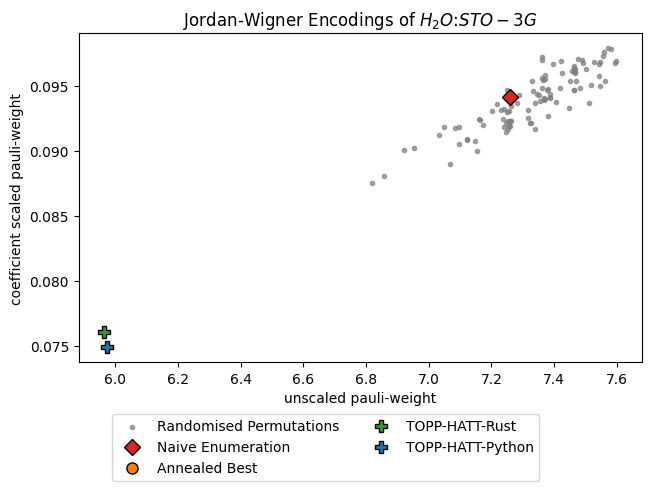

In [42]:
get_topp_hatt_results(TernaryTree(14).JW(), "Jordan-Wigner", limit=100)

Getting Naive result...
Naive result: (np.float64(7.401377274963108), np.float64(0.12631675838639844), 2033)
Getting 100 random results...
0
25
50
75
Permutation Results
[np.float64(0.1264641688227967), np.float64(0.12749694262069478), np.float64(0.12895969425160037), np.float64(0.12678465591584667), np.float64(0.12590478553642626), np.float64(0.12593273182346248), np.float64(0.12314714334984413), np.float64(0.12559403240430494), np.float64(0.12725144081745074), np.float64(0.12653457031006693), np.float64(0.12145872596854615), np.float64(0.12839373588355968), np.float64(0.12674976371279406), np.float64(0.1289292736126775), np.float64(0.12912504059237134), np.float64(0.12821401944959232), np.float64(0.12897557412044122), np.float64(0.12559567500631502), np.float64(0.12641675481830594), np.float64(0.12663576766620935), np.float64(0.1276135660249376), np.float64(0.12627831779674425), np.float64(0.12535504763581035), np.float64(0.12098594145085605), np.float64(0.12850935372400663), np.floa

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_27303/1342688098.py:112: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


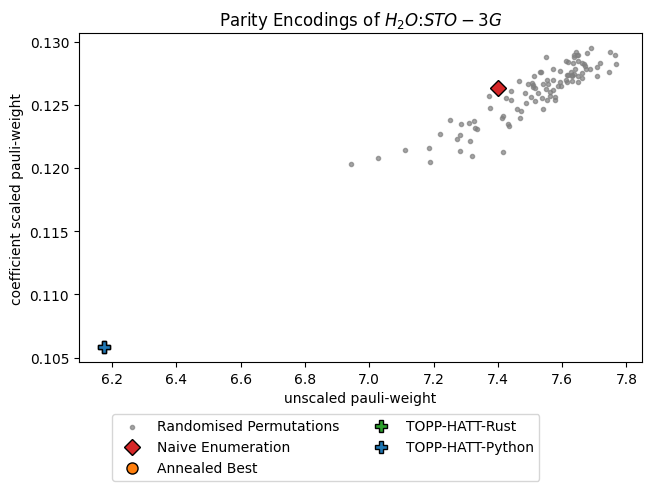

In [43]:
get_topp_hatt_results(TernaryTree(14).ParityEncoding(), "Parity")


Getting Naive result...
Naive result: (np.float64(6.225282833251352), np.float64(0.143645964472345), 2033)
Getting 100 random results...
0
25
50
75
Permutation Results
[np.float64(0.14644524957270671), np.float64(0.13924337835906211), np.float64(0.13974414455748158), np.float64(0.141740852004133), np.float64(0.149739012231509), np.float64(0.13820145090828298), np.float64(0.14409169122703894), np.float64(0.13721887628786), np.float64(0.14891672288829472), np.float64(0.14020177100001052), np.float64(0.13952184102199), np.float64(0.14807744579081578), np.float64(0.14790478784975222), np.float64(0.139411916716646), np.float64(0.1459957015700448), np.float64(0.14353690102331523), np.float64(0.13980429450663812), np.float64(0.1471863869411067), np.float64(0.14542885768277614), np.float64(0.14501923882661064), np.float64(0.13877556809477756), np.float64(0.14651218354898835), np.float64(0.1466404128323086), np.float64(0.13948600306078504), np.float64(0.14625748292440502), np.float64(0.14772118

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_27303/1342688098.py:112: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


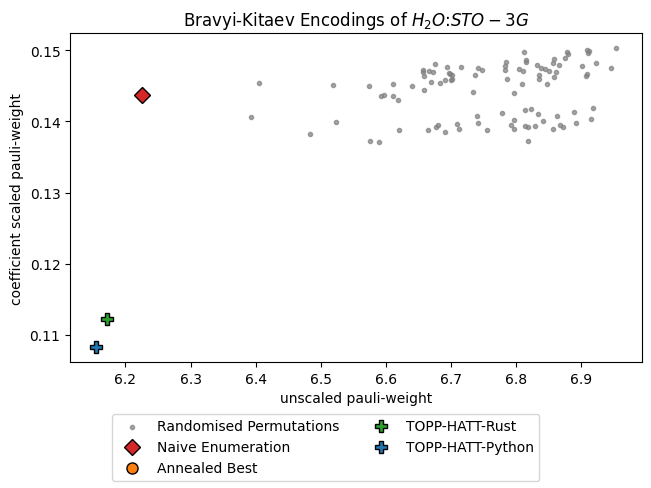

In [45]:
get_topp_hatt_results(TernaryTree(14).BK(), "Bravyi-Kitaev")

In [46]:
get_topp_hatt_results(TernaryTree(14).JKMN(), "JKMN")

Getting Naive result...
Naive result: (np.float64(6.247909493359567), np.float64(0.13663988700897936), 2033)
Getting 100 random results...
0
25
50
75
Permutation Results
[np.float64(0.14187909601131676), np.float64(0.13508189803464266), np.float64(0.1311908382474662), np.float64(0.13337938412510014), np.float64(0.14134399275351678), np.float64(0.13919546690895745), np.float64(0.13894621077866812), np.float64(0.12934547286841316), np.float64(0.14095754311561534), np.float64(0.13303812423723738), np.float64(0.1391002535057228), np.float64(0.13570666918378607), np.float64(0.1320091226701486), np.float64(0.13963525489986386), np.float64(0.1403279863892449), np.float64(0.1389728175558334), np.float64(0.14123893028106824), np.float64(0.1402373446158419), np.float64(0.13901829688485537), np.float64(0.1392365400460916), np.float64(0.13144048617332235), np.float64(0.14016333921598967), np.float64(0.14091964597842555), np.float64(0.13276860576196983), np.float64(0.1391479221600766), np.float64(0

thread '<unnamed>' panicked at src/lib.rs:532:52:
TOPPHATT should have failed by now.: RestrictionError(EvenLeaf)
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


PanicException: TOPPHATT should have failed by now.: RestrictionError(EvenLeaf)

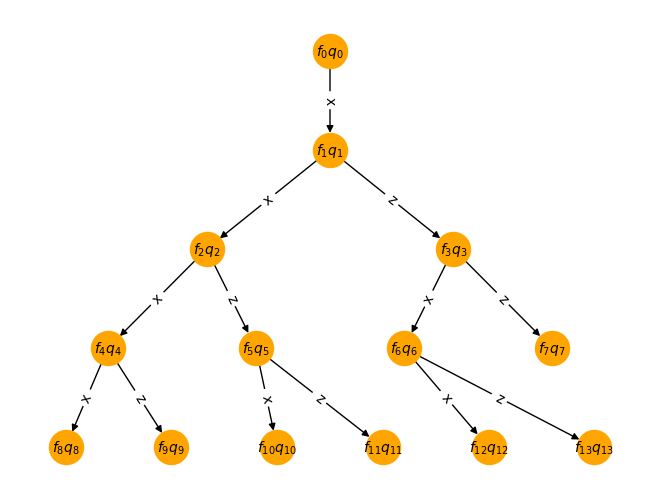

In [50]:
from ferrmion.visualise import draw_tt
draw_tt(TernaryTree(14).BK(), enumeration_scheme=TernaryTree(14).BK().default_enumeration_scheme())